In [1]:
# All imports
import os
import sys
sys.path.insert(0, '../')

# Import Constants
from scripts.constants import ADG_SKYNET_ROOT_ADDR

# Import Libraries
import pandas as pd
import numpy as np
import ast
import re
import json
from tqdm import tqdm
import networkx as nx
from pyvis.network import Network
import math  # Import math module for natural log
import datetime
from collections import defaultdict
from scipy.stats import linregress

# Plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
from plotly.colors import qualitative
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pprint import pprint

# Classes

In [2]:
# quantile_manager.py
import pandas as pd
import numpy as np

class PSquareQuantileApproximator:
    """
    Implements the extended P² algorithm for dynamic quantile approximation.
    Tracks multiple quantiles using multiple markers.
    """
    def __init__(self, quantiles):
        """
        Initialize the approximator with a list of quantiles.

        :param quantiles: List of quantiles to estimate (e.g., [0.25, 0.5, 0.75])
        """
        self.quantiles = sorted(quantiles)
        self.num_quantiles = len(self.quantiles)
        self.reset()

    def reset(self):
        """Initialize or reset the quantile approximator."""
        self.initial_sample = []
        self.num_markers = 2 * self.num_quantiles + 3  # Number of markers
        self.q = []  # Marker heights
        self.n = []  # Marker positions
        self.n_desired = []  # Desired marker positions
        self.p_inc = []  # Desired position increments

    def fit(self, X):
        """Fit the model to the data."""
        self.reset()
        return self.partial_fit(X)

    def partial_fit(self, X):
        """Incrementally fit the model to the data."""
        for x in X:
            self._partial_fit_single(x)
        return self

    def _partial_fit_single(self, x):
        """Fit the model to a single data point."""
        # Collect initial samples
        if len(self.initial_sample) < self.num_markers:
            self.initial_sample.append(x)
            if len(self.initial_sample) == self.num_markers:
                self.initial_sample.sort()
                self.q = self.initial_sample.copy()
                self.n = list(range(1, self.num_markers + 1))
                self.p_inc = [0] + self.quantiles + [1] + [1 - q for q in reversed(self.quantiles)] + [0]
                total_p_inc = sum(self.p_inc)
                self.n_desired = [1 + (total_p_inc - sum(self.p_inc[:i+1])) * (self.num_markers - 1)
                                  for i in range(self.num_markers)]
        else:
            # Update markers
            if x < self.q[0]:
                self.q[0] = x  # Update minimum
                k = 0
            elif x >= self.q[-1]:
                self.q[-1] = x  # Update maximum
                k = self.num_markers - 2
            else:
                # Find k such that q[k] <= x < q[k+1]
                k = next(i for i in range(self.num_markers - 1) if self.q[i] <= x < self.q[i+1])
            # Increment positions of markers greater than k
            for i in range(k + 1, self.num_markers):
                self.n[i] += 1
            # Update desired positions
            for i in range(self.num_markers):
                self.n_desired[i] += self.p_inc[i]
            # Adjust marker heights
            for i in range(1, self.num_markers - 1):
                d = self.n_desired[i] - self.n[i]
                if (d >= 1 and self.n[i + 1] - self.n[i] > 1) or (d <= -1 and self.n[i - 1] - self.n[i] < -1):
                    d = int(np.sign(d))
                    q_temp = self._parabolic(i, d)
                    if self.q[i - 1] < q_temp < self.q[i + 1]:
                        self.q[i] = q_temp
                    else:
                        self.q[i] = self._linear(i, d)
                    self.n[i] += d

    def _parabolic(self, i, d):
        """Parabolic prediction for marker height adjustment."""
        i = int(i)
        n_i = self.n[i]
        n_im1 = self.n[i - 1]
        n_ip1 = self.n[i + 1]
        q_i = self.q[i]
        q_im1 = self.q[i - 1]
        q_ip1 = self.q[i + 1]
        numerator = d * ((n_i - n_im1 + d) * (q_ip1 - q_i) / (n_ip1 - n_i) +
                         (n_ip1 - n_i - d) * (q_i - q_im1) / (n_i - n_im1))
        denominator = n_ip1 - n_im1
        return q_i + numerator / denominator

    def _linear(self, i, d):
        """Linear prediction for marker height adjustment."""
        i = int(i)
        return self.q[i] + d * (self.q[i + d] - self.q[i]) / (self.n[i + d] - self.n[i])

    def is_initialized(self):
        """Check if the approximator has been initialized with enough data points."""
        return len(self.q) == self.num_markers

    def get_markers(self):
        """Return the current quantile estimates."""
        if self.is_initialized():
            # The quantile estimates are at positions corresponding to the quantiles
            quantile_indices = [1 + i for i in range(self.num_quantiles)]
            quantile_values = [self.q[i] for i in quantile_indices]
            return [self.q[0]] + quantile_values + [self.q[-1]]  # Include min and max
        else:
            # Return the quantiles from the initial sample
            if self.initial_sample:
                quantile_values = [np.percentile(self.initial_sample, q * 100) for q in self.quantiles]
                return [min(self.initial_sample)] + quantile_values + [max(self.initial_sample)]
            else:
                return None

    def get_state(self):
        """Get the internal state for saving or exporting."""
        return {
            'q': self.q,
            'n': self.n,
            'n_desired': self.n_desired,
            'p_inc': self.p_inc,
            'initial_sample': self.initial_sample
        }

    def set_state(self, state):
        """Set the internal state from saved data."""
        self.q = state['q']
        self.n = state['n']
        self.n_desired = state['n_desired']
        self.p_inc = state['p_inc']
        self.initial_sample = state['initial_sample']

    def get_quantile_names(self):
        """Return the names of the quantiles, including 'min' and 'max'."""
        quantile_names = ['min'] + [f'p{int(round(q * 100))}' for q in self.quantiles] + ['max']
        return quantile_names


# gk_quantile_approximator.py
import bisect

class GKQuantileApproximator:
    """
    Implements the Greenwald-Khanna algorithm for quantile estimation.
    """
    def __init__(self, quantiles, epsilon=0.01):
        """
        :param quantiles: List of quantiles to estimate (e.g., [0.25, 0.5, 0.75])
        :param epsilon: Acceptable error in the quantile approximation.
        """
        self.quantiles = sorted(quantiles)
        self.epsilon = epsilon
        self.reset()

    def reset(self):
        """Reset the GK approximator."""
        self.n = 0  # Total number of data points
        self.summary = []  # List of tuples (value, g, delta)

    def partial_fit(self, X):
        """Incrementally fit the model to the data."""
        for x in X:
            self.insert(x)
        return self

    def insert(self, x):
        """Insert a new data point into the summary."""
        self.n += 1
        r = {'value': x, 'g': 1, 'delta': 0}
        if not self.summary:
            self.summary.append(r)
            return

        idx = bisect.bisect_left([s['value'] for s in self.summary], x)
        if idx == 0:
            delta = 0
        elif idx == len(self.summary):
            delta = 0
        else:
            delta = int(2 * self.epsilon * self.n)
        r['delta'] = delta
        self.summary.insert(idx, r)
        self.compress()

    def compress(self):
        """Compress the summary to maintain the error guarantees."""
        i = 0
        while i < len(self.summary) - 1:
            r1 = self.summary[i]
            r2 = self.summary[i + 1]
            if (r1['g'] + r2['g'] + r2['delta']) <= int(2 * self.epsilon * self.n):
                r2['g'] += r1['g']
                self.summary.pop(i)
            else:
                i += 1

    def get_markers(self):
        """Return the quantile estimates."""
        if not self.summary:
            return None
        markers = [self.summary[0]['value']]  # min
        for quantile in self.quantiles:
            rank_min = 0
            desired_rank = quantile * self.n
            for i, s in enumerate(self.summary):
                rank_min += s['g']
                rank_max = rank_min + s['delta']
                if rank_max >= desired_rank + self.epsilon * self.n:
                    markers.append(s['value'])
                    break
        markers.append(self.summary[-1]['value'])  # max
        return markers

    def is_initialized(self):
        """Check if the approximator has enough data."""
        return len(self.summary) > 0

    def get_state(self):
        """Get the internal state for saving or exporting."""
        return {
            'n': self.n,
            'summary': self.summary
        }

    def set_state(self, state):
        """Set the internal state from saved data."""
        self.n = state['n']
        self.summary = state['summary']

    def get_quantile_names(self):
        """Return the names of the quantiles, including 'min' and 'max'."""
        quantile_names = ['min'] + [f'p{int(round(q * 100))}' for q in self.quantiles] + ['max']
        return quantile_names


# t_digest_quantile_approximator.py
from tdigest import TDigest

class TDigestQuantileApproximator:
    """
    Implements the T-Digest algorithm for quantile estimation.
    """
    def __init__(self, quantiles):
        """
        :param quantiles: List of quantiles to estimate (e.g., [0.25, 0.5, 0.75])
        """
        self.quantiles = sorted(quantiles)
        self.reset()

    def reset(self):
        """Reset the T-Digest approximator."""
        self.digest = TDigest()

    def partial_fit(self, X):
        """Incrementally fit the model to the data."""
        for x in X:
            self.digest.update(x)
        return self

    def get_markers(self):
        """Return the quantile estimates."""
        if self.digest.n == 0:
            return None
        markers = [self.percentile(0)]  # min
        for q in self.quantiles:
            markers.append(self.percentile(q * 100))
        markers.append(self.percentile(100))  # max
        return markers

    def percentile(self, p):
        """Compute the percentile value using the digest's percentile method."""
        return self.digest.percentile(p)

    def is_initialized(self):
        """Check if the approximator has enough data."""
        return self.digest.n > 0

    def get_state(self):
        """Get the internal state for saving or exporting."""
        # Use the to_dict() method for serialization
        return self.digest.to_dict()

    def set_state(self, state):
        """Set the internal state from saved data."""
        self.digest = TDigest()
        self.digest.update_from_dict(state)

    def get_quantile_names(self):
        """Return the names of the quantiles, including 'min' and 'max'."""
        quantile_names = ['min'] + [f'p{int(round(q * 100))}' for q in self.quantiles] + ['max']
        return quantile_names

class QuantileManager:
    """
    Manages quantile approximators for different KPIs using specified algorithms and parameters.
    """
    def __init__(self, kpi_approximators):
        """
        :param kpi_approximators: Dictionary mapping KPI names to either:
            - An initialized quantile approximator instance
            - A tuple of (algorithm_class, parameters_dict)
        """
        self.quantile_approximators = {}
        for kpi, approximator_info in kpi_approximators.items():
            if isinstance(approximator_info, tuple):
                # It's a tuple of (algorithm_class, parameters_dict)
                algorithm_class, params = approximator_info
                self.quantile_approximators[kpi] = algorithm_class(**params)
            elif isinstance(approximator_info, type):
                # It's an algorithm class, instantiate with default params
                self.quantile_approximators[kpi] = algorithm_class()
            else:
                # Assume it's an initialized approximator instance
                self.quantile_approximators[kpi] = approximator_info

    def fit(self):
        """Initialize all approximators with empty lists."""
        for approximator in self.quantile_approximators.values():
            approximator.fit([])

    def partial_fit(self, kpi_name, value):
        """
        Update the quantile approximations for a specific KPI.
        
        This method handles both scalar values and arrays, ensuring proper formatting
        and preventing nested arrays.
        
        Args:
            kpi_name (str): The name of the KPI to update
            value (float, int, list, np.ndarray): The value or values to fit
                - If scalar (float/int): Will be wrapped in a list
                - If list/array: Will be processed as is
        
        Returns:
            None
        
        Raises:
            TypeError: If value is not a number, list, or numpy array
            ValueError: If value is a nested array or contains non-numeric elements
        """
        if kpi_name not in self.quantile_approximators:
            return
            
        # Handle different input types
        if isinstance(value, (int, float)):
            # Single numeric value - wrap in a list
            self.quantile_approximators[kpi_name].partial_fit([value])
            
        elif isinstance(value, (list, np.ndarray)):
            # Check if it's a flat array with numeric elements
            if not value:
                # Empty list/array - skip
                return
                
            # Check for nested arrays
            if any(isinstance(item, (list, np.ndarray)) for item in value):
                raise ValueError(f"Nested arrays are not supported for KPI '{kpi_name}'. "
                                 f"Expected a flat array of numbers.")
                
            # Check that all elements are numeric
            if not all(isinstance(item, (int, float)) for item in value):
                raise ValueError(f"Non-numeric elements found in array for KPI '{kpi_name}'. "
                                 f"All elements must be numbers.")
                
            # It's a flat numeric array - pass directly to partial_fit
            self.quantile_approximators[kpi_name].partial_fit(value)
            
        else:
            # Not a supported type
            raise TypeError(f"Unsupported value type for KPI '{kpi_name}': {type(value)}. "
                           f"Expected a number, list, or numpy array.")

    def get_markers(self, kpi_name):
        """Get the markers (quantile estimates) for a specific KPI."""
        if kpi_name in self.quantile_approximators:
            return self.quantile_approximators[kpi_name].get_markers()
        else:
            return None

    def reset(self):
        """Reset all approximators."""
        for approximator in self.quantile_approximators.values():
            approximator.reset()

    def export_markers(self):
        """
        Export all markers and their associated metadata to a DataFrame.
        """
        export_data = []
        for kpi, approx in self.quantile_approximators.items():
            if approx.is_initialized():
                export_data.append({
                    'kpi': kpi,
                    'markers': approx.get_markers(),
                    'state': approx.get_state(),
                    'algorithm': approx.__class__.__name__
                })
        return pd.DataFrame(export_data)

    def load_markers(self, markers_df):
        """
        Load markers and their associated metadata from a DataFrame.
        """
        for _, row in markers_df.iterrows():
            kpi = row['kpi']
            if kpi in self.quantile_approximators:
                approx = self.quantile_approximators[kpi]
                state_str = row['state']
                
                # Convert the string representation to a dictionary
                try:
                    # Try using ast.literal_eval which is safer than eval
                    state_dict = ast.literal_eval(state_str)
                    approx.set_state(state_dict)
                except (SyntaxError, ValueError) as e:
                    print(f"Error parsing state for {kpi}: {e}")

    def represent_markers(self):
        """
        Return a DataFrame with the quantile estimates for each KPI,
        with quantiles as columns named appropriately.
        """
        markers_dict = {}
        for kpi, approximator in self.quantile_approximators.items():
            markers = approximator.get_markers()
            if markers is not None:
                markers_dict[kpi] = {}
                quantile_names = approximator.get_quantile_names()
                for name, value in zip(quantile_names, markers):
                    markers_dict[kpi][name] = value
        df = pd.DataFrame.from_dict(markers_dict, orient='index')
        df.reset_index(inplace=True)
        df.rename(columns={'index': 'kpi'}, inplace=True)
        return df


In [3]:

from scipy.stats import linregress
import numpy as np
import re
from typing import Dict, List, NamedTuple, Any, Union

def preprocess(row, override_groups=None):
    """
    Preprocess a row of data into a nested dictionary organized by group.
    
    Args:
        row: A namedtuple row from data_trace.itertuples()
        override_groups: Optional list to override the group values in the row
        
    Returns:
        dict: A nested dictionary with structure organized by group with averaged values
    """
    # Extract values from the row
    mase_values = getattr(row, 'mase', []) 
    mase1_values = getattr(row, 'mase1', [])
    mase2_values = getattr(row, 'mase2', [])
    dtu_values = getattr(row, 'dtu', [])
    ddtu_values = getattr(row, 'ddtu', [])
    rddtu_a_values = getattr(row, 'rddtu_a', [])
    rddtu_b_values = getattr(row, 'rddtu_b', [])
    
    # Use override_groups if provided, otherwise use the row's group values
    group_values = override_groups if override_groups is not None else getattr(row, 'group', [])
    
    # Create a dictionary to hold our result
    result = {}
    
    # First, collect all group members
    group_members = {}
    for user_idx, group in enumerate(group_values, 1):
        if group not in group_members:
            group_members[group] = []
        group_members[group].append(user_idx)
    
    # Initialize data structures for averaging
    group_totals = {}  # {group: {'mase_sum': value, 'dtu_sum': value, etc.}}
    
    # Collect data for averaging
    for user_idx, (mase, mase1, mase2, dtu, ddtu, rddtu_a, rddtu_b, group) in enumerate(
        zip(mase_values, mase1_values, mase2_values, dtu_values, ddtu_values, 
            rddtu_a_values, rddtu_b_values, group_values), 1):
        
        if group not in group_totals:
            group_totals[group] = {
                'mase_sum': 0, 'mase1_sum': 0, 'mase2_sum': 0,
                'dtu_sum': 0, 'ddtu_sum': 0,
                'rddtu_a_sum': 0, 'rddtu_b_sum': 0, 'count': 0
            }
        
        group_totals[group]['mase_sum'] += mase
        group_totals[group]['mase1_sum'] += mase1
        group_totals[group]['mase2_sum'] += mase2
        group_totals[group]['dtu_sum'] += dtu
        group_totals[group]['ddtu_sum'] += ddtu
        group_totals[group]['rddtu_a_sum'] += rddtu_a
        group_totals[group]['rddtu_b_sum'] += rddtu_b
        group_totals[group]['count'] += 1
    
    # Calculate averages and format result
    for group, data in group_totals.items():
        count = data['count']
        if count > 0:  # Avoid division by zero
            avg_mase = round(data['mase_sum'] / count, 3)
            avg_mase1 = round(data['mase1_sum'] / count, 3)
            avg_mase2 = round(data['mase2_sum'] / count, 3)
            
            result[group] = {
                'mase': avg_mase,
                'mase1': avg_mase1,
                'mase2': avg_mase2,
                'mase_all': [avg_mase, avg_mase1, avg_mase2],
                'dtu': round(data['dtu_sum'] / count, 3),
                'ddtu': round(data['ddtu_sum'] / count, 3),
                'rddtu_a': round(data['rddtu_a_sum'] / count, 3),
                'rddtu_b': round(data['rddtu_b_sum'] / count, 3),
                'group_members': group_members[group]
            }
        else:
            result[group] = {
                'mase': 0, 
                'mase1': 0,
                'mase2': 0,
                'mase_all': [0, 0, 0],
                'dtu': 0, 
                'ddtu': 0, 
                'rddtu_a': 0, 
                'rddtu_b': 0,
                'group_members': group_members[group]
            }
    
    return result

class Symbolizer:
    def __init__(
        self,
        quantile_manager,
        kpis: Dict[str, str],
        decisions: Dict[str, str],
        kpi_change_threshold_percent: int = 10,
    ):
        """
        Initializes the Symbolizer with a QuantileManager, KPI list, and decision list.

        :param quantile_manager: An instance of QuantileManager to manage quantiles for KPIs.
        :param kpis: A dictionary mapping KPI human-readable names to environment kpi names.
        :param decisions: A dictionary mapping decision human-readable names to environment decision names.
        :param kpi_change_threshold_percent: Threshold percentage to determine if a KPI has increased or decreased.
        """
        self.quantile_manager = quantile_manager
        self.kpis = kpis
        self.decisions = decisions
        self.kpi_change_threshold_percent = kpi_change_threshold_percent

        # Define category names for standard KPIs
        self.standard_category_names = ["VeryLow", "Low", "Medium", "High", "VeryHigh"]
        # Define category names for special KPIs
        self.special_category_names = ["Low", "Medium", "High"]
        # List of KPIs that use the special three-category system
        self.special_kpis = []  # Assuming no special KPIs in Pensive

        self.array_kpis = ['mase_all']
        self.trend_categories = ["fluctuating", "spiking", "dropping"]

        self.slopes_hist = {'mase_all': []}

        # Map array KPIs to their base KPIs for quantile management
        self.array_to_base_kpi = {
            'mase_all': 'mase',
        }

        # Define current timestep index for each array KPI
        self.array_current_timestep_index = {
            'mase_all': 0,  # Last element is current for dl_tput and dl_delay
        }

        self.prev_state_tuple = None

    def create_symbolic_form(self, curr_step_tuple, update_approximators=True):
        """
        Creates symbolic representation grouped by group, with enhanced action representations.
        """
        effects_symbolic_representation = []
        prev_step_tuple = self.prev_state_tuple
        
        # Get preprocessed data by group (with averages)
        curr_preprocessed = preprocess(curr_step_tuple)
        
        if prev_step_tuple is not None:
            # Get the current groups to apply to previous data
            curr_groups = getattr(curr_step_tuple, 'group', [])
            
            # Get preprocessed previous data using current groups
            prev_preprocessed = preprocess(prev_step_tuple, override_groups=curr_groups)
            
            # For each group in the current step
            for group_id, curr_group_data in curr_preprocessed.items():
                symbolic_state = {}
                # Process each KPI for this group
                for key, env_name in self.kpis.items():
                    if env_name in curr_group_data:
                        curr_value = curr_group_data[env_name]
                        prev_value = prev_preprocessed.get(group_id, {}).get(env_name, 0)
                        
                        symbolic_state[env_name] = self._get_symb_group(curr_value, prev_value, env_name, group_id)
                        # print(f"symbolic_state[env_name]: {symbolic_state[env_name]}")
                
                # Process actions with both representation types
                for key, env_name in self.decisions.items():
                    action_value = self._safe_get_attr(curr_step_tuple, env_name)
                    if action_value is not None:
                        # Original per-user action symbols (optional) 
                        symbolic_state[env_name] = self._create_action_symbols(action_value, curr_step_tuple)
                        
                        # Add allocation action representation
                        alloc_actions = self._create_group_allocation_action(action_value, curr_step_tuple)
                        if group_id in alloc_actions:
                            symbolic_state['alloc_action'] = alloc_actions[group_id]
                        else:
                            symbolic_state['alloc_action'] = f"alloc(G{group_id}, 0)"
                        
                        # Add scheduling action representation
                        sched_actions = self._create_group_scheduling_action(action_value, curr_step_tuple)
                        if group_id in sched_actions:
                            symbolic_state['sched_action'] = sched_actions[group_id]
                        else:
                            symbolic_state['sched_action'] = f"sched(G{group_id}, 0)"
                
                # Create the final representation for this group
                symbolic_representation = {
                    "timestep": getattr(curr_step_tuple, "timestep", None),
                    "group_id": group_id,
                    **symbolic_state,
                    "reward": getattr(curr_step_tuple, "reward", None),
                }
                
                effects_symbolic_representation.append(symbolic_representation)
        else:
            # Similar updates needed for the first timestep case
            for group_id, curr_group_data in curr_preprocessed.items():
                symbolic_state = {}
                
                # Process each KPI for this group
                for key, env_name in self.kpis.items():
                    if env_name in curr_group_data:
                        curr_value = curr_group_data[env_name]
                        symbolic_state[env_name] = self._get_initial_symb_group(curr_value, env_name, group_id)
                
                # Process actions with both representation types
                for key, env_name in self.decisions.items():
                    action_value = self._safe_get_attr(curr_step_tuple, env_name)
                    if action_value is not None:
                        symbolic_state[env_name] = self._create_action_symbols(action_value, curr_step_tuple)
                        
                        # Add allocation action representation (same as above)
                        alloc_actions = self._create_group_allocation_action(action_value, curr_step_tuple)
                        if group_id in alloc_actions:
                            symbolic_state['alloc_action'] = alloc_actions[group_id]
                        else:
                            symbolic_state['alloc_action'] = f"alloc(G{group_id}, 0)"
                        
                        # Add scheduling action representation (same as above)
                        sched_actions = self._create_group_scheduling_action(action_value, curr_step_tuple)
                        if group_id in sched_actions:
                            symbolic_state['sched_action'] = sched_actions[group_id]
                        else:
                            symbolic_state['sched_action'] = f"sched(G{group_id}, 0)"
                
                symbolic_representation = {
                    "timestep": getattr(curr_step_tuple, "timestep", None),
                    "group_id": group_id,
                    **symbolic_state,
                    "reward": getattr(curr_step_tuple, "reward", None),
                }
                
                effects_symbolic_representation.append(symbolic_representation)
        
        if update_approximators:
            self._add_timestep_kpi_data_to_approximator(curr_step_tuple)
            self.prev_state_tuple = curr_step_tuple
        
        return effects_symbolic_representation

    def _create_group_allocation_action(self, action_value, curr_step_tuple):
        """
        Create 'alloc' action representation that shows what percentage of scheduled users belong to each group.
        Percentages are rounded to nearest 5%.
        
        Args:
            action_value: The action string like '(0, 1, 2, 3, 5)'
            curr_step_tuple: Current timestep tuple with group information
            
        Returns:
            dict: Group allocation percentages in form {group_id: "alloc(G{group_id}, percentage)"}
        """
        # Parse scheduled user indices
        scheduled_users = self._parse_action_string(action_value)
        
        # Get group information
        groups = self._safe_get_attr(curr_step_tuple, 'group')
        if not groups or not scheduled_users:
            return {}
            
        # Count scheduled users by group
        scheduled_by_group = {}
        total_scheduled = len(scheduled_users)
        
        for user_idx in scheduled_users:
            if user_idx < len(groups):
                group_id = groups[user_idx]
                scheduled_by_group[group_id] = scheduled_by_group.get(group_id, 0) + 1
        
        # Create allocation action representation for each group
        group_actions = {}
        for group_id, count in scheduled_by_group.items():
            # Calculate percentage and round to nearest 5%
            exact_percentage = (count / total_scheduled) * 100
            rounded_percentage = round(exact_percentage / 5) * 5
            group_actions[group_id] = f"alloc(G{group_id}, {rounded_percentage})"
        
        return group_actions

    def _create_group_scheduling_action(self, action_value, curr_step_tuple):
        """
        Create 'sched' action representation that shows what percentage of each group's users are scheduled.
        Percentages are rounded to nearest 5%.
        
        Args:
            action_value: The action string like '(0, 1, 2, 3, 5)'
            curr_step_tuple: Current timestep tuple with group information
            
        Returns:
            dict: Group scheduling percentages in form {group_id: "sched(G{group_id}, percentage)"}
        """
        # Parse scheduled user indices
        scheduled_users = self._parse_action_string(action_value)
        
        # Get group information
        groups = self._safe_get_attr(curr_step_tuple, 'group')
        if not groups:
            return {}
            
        # Count total users and scheduled users by group
        users_by_group = {}
        scheduled_by_group = {}
        
        # Count total users in each group
        for user_idx, group_id in enumerate(groups):
            users_by_group[group_id] = users_by_group.get(group_id, 0) + 1
            
            # Count scheduled users in each group
            if user_idx in scheduled_users:
                scheduled_by_group[group_id] = scheduled_by_group.get(group_id, 0) + 1
        
        # Create scheduling action representation for each group
        group_actions = {}
        for group_id, total in users_by_group.items():
            scheduled = scheduled_by_group.get(group_id, 0)
            # Calculate percentage and round to nearest 5%
            if total > 0:
                exact_percentage = (scheduled / total) * 100
                rounded_percentage = round(exact_percentage / 5) * 5
            else:
                rounded_percentage = 0
                
            group_actions[group_id] = f"sched(G{group_id}, {rounded_percentage})"
        
        return group_actions

    def _get_initial_symb_group(self, curr_value, env_name, group_id):
        """
        Generate KPI symbolic representation for the first timestep at group level.
        
        Args:
            curr_value: Current KPI value (group average).
            env_name: Name of the KPI.
            group_id: ID of the group.
            
        Returns:
            str: Symbolic representation string.
        """
        markers = self.quantile_manager.get_markers(env_name)
        if markers is None:
            return f"Unknown({env_name})"
            # return f"Unknown({env_name}, G{group_id})"
        
        category = self._get_category(curr_value, markers, env_name)
        predicate = "const"
        # return f"{predicate}({env_name}, {category}, G{group_id})"
        return f"{predicate}({env_name}, {category})"

    def _get_symb_group(self, curr_value, prev_value, env_name, group_id):
        """
        Calculate the symbolic representation of KPI changes at group level.
        
        Args:
            curr_value: Current KPI value (group average).
            prev_value: Previous KPI value (group average).
            env_name: Name of the KPI.
            group_id: ID of the group.
            
        Returns:
            str: Symbolic representation string.
        """
        if env_name in self.array_kpis:
            current_timestep_index = self.array_current_timestep_index[env_name]
            change_percentage = self._find_change_percentage(curr_value[current_timestep_index], prev_value[current_timestep_index])
            predicate = self._get_predicate(change_percentage)

            # Use the base KPI's markers for categorization
            base_kpi = self.array_to_base_kpi[env_name]
            markers = self.quantile_manager.get_markers(base_kpi)  # Use base KPI here
            if markers is None:
                return f"Unknown({env_name})"

            category = self._get_category(curr_value[current_timestep_index], markers, base_kpi)  # Pass base KPI here
            trend = self._analyze_trend(curr_value, env_name)

            return f"{predicate}({env_name}, {category}, {trend})"
        
        change_percentage = self._find_change_percentage(curr_value, prev_value)
        predicate = self._get_predicate(change_percentage)
        markers = self.quantile_manager.get_markers(env_name)
        
        if markers is None:
            return f"Unknown({env_name})"
            # return f"Unknown({env_name}, G{group_id})"
        
        category = self._get_category(curr_value, markers, env_name)
        
        # Array KPIs would need special handling, but we're using group averages now
        return f"{predicate}({env_name}, {category})"
        # return f"{predicate}({env_name}, {category}, G{group_id})"

    def _initialize_symbols(self, curr_step_tuple):
        """
        Initialize symbols for the first timestep.

        :param curr_step_tuple: Current step namedtuple.
        :return: A dictionary with initial symbolic representations.
        """
        symbolic_representation = {}
        
        # Process KPIs (which are now arrays)
        for key, env_name in self.kpis.items():
            curr_values = self._safe_get_attr(curr_step_tuple, env_name)
            # Check if the value is an array/list
            if isinstance(curr_values, list):
                # Process each value in the array
                symbolic_values = []
                for value in curr_values:
                    symbolic_values.append(self._get_initial_symb(value, env_name))
                symbolic_representation[env_name] = symbolic_values
            else:
                # Handle single values (in case some KPIs aren't arrays)
                symbolic_representation[env_name] = self._get_initial_symb(curr_values, env_name)
        
        # Process decisions (which might be single values)
        for key, env_name in self.decisions.items():
            curr_value = self._safe_get_attr(curr_step_tuple, env_name)
            if curr_value is not None:
                # Pass curr_step_tuple to include group information
                symbolic_representation[env_name] = self._create_action_symbols(curr_value, curr_step_tuple)
        
        return symbolic_representation

    def _get_initial_symb(self, curr_value, env_name):
        """
        Generate KPI symbolic representation for the first timestep.

        :param curr_value: Current KPI value.
        :param env_name: Name of the KPI.
        :return: Symbolic representation string.
        """
        markers = self.quantile_manager.get_markers(env_name)
        if markers is None:
            return f"Unknown({env_name})"  # Handle the case where markers are not available

        category = self._get_category(curr_value, markers, env_name)
        predicate = "const"
        return f"{predicate}({env_name}, {category})"

    def _calculate_symbolic_state(self, curr_step_tuple, prev_step_tuple):
        """
        Calculate the symbolic state for KPIs and decisions based on current and previous values.

        :param curr_step_tuple: Current namedtuple.
        :param prev_step_tuple: Previous namedtuple.
        :return: A dictionary with symbolic representations.
        """
        symbolic_representation = {}
        
        # Process KPIs (which can be arrays)
        for key, env_name in self.kpis.items():
            curr_values = self._safe_get_attr(curr_step_tuple, env_name)
            prev_values = self._safe_get_attr(prev_step_tuple, env_name)
            
            # Check if the values are arrays/lists
            if isinstance(curr_values, list) and isinstance(prev_values, list):
                # Process each pair of values in the arrays
                symbolic_values = []
                for curr_val, prev_val in zip(curr_values, prev_values):
                    symbolic_values.append(self._get_symb(curr_val, prev_val, env_name))
                symbolic_representation[env_name] = symbolic_values
            else:
                # Handle single values (in case some KPIs aren't arrays)
                symbolic_representation[env_name] = self._get_symb(curr_values, prev_values, env_name)
        
        # Process decisions (which might be single values)
        for key, env_name in self.decisions.items():
            curr_value = self._safe_get_attr(curr_step_tuple, env_name)
            if curr_value is not None:
                # Pass curr_step_tuple to include group information
                symbolic_representation[env_name] = self._create_action_symbols(curr_value, curr_step_tuple)
        
        return symbolic_representation

    def _parse_action_string(self, action_str):
        """
        Parse an action string like '(0, 1, 3, 4, 6)' into a list of scheduled user indices.
        
        :param action_str: String representation of the action.
        :return: List of integers representing scheduled user indices.
        """
        if not action_str:
            return []
            
        # Extract numbers using regex
        scheduled_users = []
        if isinstance(action_str, str):
            # Extract all numbers from the string
            numbers = re.findall(r'\d+', action_str)
            scheduled_users = [int(num) for num in numbers]
        
        return scheduled_users

    def _create_action_symbols(self, action_value, curr_step_tuple=None):
        """
        Create symbolic representation for action, now including group information.
        
        :param action_value: Value from the action column (string or other format).
        :param curr_step_tuple: Current timestep tuple containing group information.
        :return: Array of 7 strings with 'Sched(user, G{group_number})' or 'notSched(user, G{group_number})'.
        """
        # Parse the action value to get scheduled user indices
        scheduled_users = self._parse_action_string(action_value)
        
        # Get group information if available
        groups = None
        if curr_step_tuple is not None:
            groups = self._safe_get_attr(curr_step_tuple, 'group')
        
        # Create symbolic representation for each user (7 users total)
        action_symbols = []
        for user_idx in range(7):
            # Determine group suffix
            group_suffix = ''
            if groups is not None and user_idx < len(groups):
                group_suffix = f', G{groups[user_idx]}'
                
            # Create appropriate symbol based on scheduling status
            if user_idx in scheduled_users:
                action_symbols.append(f"Sched(user{group_suffix})")
            else:
                action_symbols.append(f"notSched(user{group_suffix})")
                    
        return action_symbols

    def _get_symb(self, curr_value, prev_value, kpi_name):
        """Calculate the symbolic representation of KPI changes."""
        if kpi_name in self.array_kpis:
            current_timestep_index = self.array_current_timestep_index[kpi_name]
            change_percentage = self._find_change_percentage(curr_value[current_timestep_index], prev_value[current_timestep_index])
            predicate = self._get_predicate(change_percentage)

            # Use the base KPI's markers for categorization
            base_kpi = self.array_to_base_kpi[kpi_name]
            markers = self.quantile_manager.get_markers(base_kpi)  # Use base KPI here
            if markers is None:
                return f"Unknown({kpi_name})"

            category = self._get_category(curr_value[current_timestep_index], markers, base_kpi)  # Pass base KPI here
            trend = self._analyze_trend(curr_value, kpi_name)

            return f"{predicate}({kpi_name}, {category}, {trend})"

        # Original logic for non-array KPIs
        change_percentage = self._find_change_percentage(curr_value, prev_value)
        predicate = self._get_predicate(change_percentage)
        markers = self.quantile_manager.get_markers(kpi_name)
        if markers is None:
            return f"Unknown({kpi_name})"
        category = self._get_category(curr_value, markers, kpi_name)
        return f"{predicate}({kpi_name}, {category})"

    def _get_category(self, value, markers, kpi_name):
        """Categorize a value based on percentile markers."""
        if kpi_name in self.special_kpis:
            # Use fixed percentiles for special KPIs
            if markers is None or len(markers) < 3:
                return "Unknown"

            p30 = markers[1]
            p70 = markers[2]

            if value < p30:
                return self.special_category_names[0]  # Low
            elif value <= p70:
                return self.special_category_names[1]  # Medium
            else:
                return self.special_category_names[2]  # High
        else:
            # Use standard 5 categories for other KPIs
            if markers is None or len(markers) < 5:
                return "Unknown"

            p20 = markers[1]
            p40 = markers[2]
            p60 = markers[3]
            p80 = markers[4]

            if value <= p20:
                return self.standard_category_names[0]  # VeryLow
            elif value <= p40:
                return self.standard_category_names[1]  # Low
            elif value <= p60:
                return self.standard_category_names[2]  # Medium
            elif value <= p80:
                return self.standard_category_names[3]  # High
            else:
                return self.standard_category_names[4]  # VeryHigh

    def _analyze_trend(self, value_array: List[float], kpi_name: str) -> str:
        """
        Analyzes trend in array values, ignoring zeros.
        Returns 'fluctuating', 'spiking', or 'dropping' based on dynamic quantile thresholds.

        :param value_array: List of KPI values.
        :param kpi_name: Name of the KPI being analyzed.
        :return: String representing the trend.
        """
        values = [v for v in value_array if v != 0.0]
        if len(values) < 2:
            return "fluctuating"

        x = np.arange(len(values))
        slope, _, _, _, _ = linregress(x, values)

        self.slopes_hist[kpi_name].append(slope)

        # Fetch dynamic thresholds from quantile manager for slopes
        slope_kpi_name = f"{kpi_name}_slope"  # e.g., 'dl_tput_all_slope'
        slope_markers = self.quantile_manager.get_markers(slope_kpi_name)

        if slope_markers is None or len(slope_markers) < 3:  # min, p20, p80, max - we expect at least min, p20, p80
            # Fallback to fixed thresholds if quantiles are not available
            low_threshold = -0.0074 if kpi_name == 'dl_tput_all' else -0.0151
            high_threshold = 0.0067 if kpi_name == 'dl_tput_all' else 0.0259
        else:
            p20_threshold = slope_markers[1]  # p20 - Correct index is 1
            p80_threshold = slope_markers[2]  # p80 - Correct index is 2
            low_threshold = p20_threshold
            high_threshold = p80_threshold
        
        if slope > high_threshold:
            return "spiking"
        elif slope < low_threshold:
            return "dropping"
        else:
            return "fluctuating"

    def _find_change_percentage(self, curr_value, prev_value):
        """Calculate the change percentage of the given parameter."""
        if isinstance(curr_value, list):
            # For arrays, use the specified current timestep value
            curr = curr_value
            prev = prev_value
        else:
            curr = curr_value
            prev = prev_value

        if prev == 0:
            if curr == 0:
                return 0
            else:
                return "inf"
        else:
            return int(100 * (curr - prev) / prev)

    def _get_predicate(self, change_percentage):
        """
        Return the correct predicate according to the change percentage.

        :param change_percentage: The percentage change.
        :return: A string representing the predicate ('inc', 'dec', 'const').
        """
        if change_percentage == "inf":
            return "inc"
        elif change_percentage > self.kpi_change_threshold_percent:
            return "inc"
        elif change_percentage < -self.kpi_change_threshold_percent:
            return "dec"
        else:
            return "const"

    def _add_timestep_kpi_data_to_approximator(self, timestep_tuple):
        """
        Adds KPI data of one timestep to the quantile approximators, including slopes for '_all' KPIs.
        Modified to work with namedtuples and handle array values correctly.
        
        :param timestep_tuple: The current timestep data as a namedtuple
        """
        # Loop through each KPI in the mapping
        for kpi_name in self.kpis.values():
            # Handle different KPI types appropriately
            if kpi_name not in self.array_kpis:
                # For scalar KPIs, directly fit the value
                kpi_value = self._safe_get_attr(timestep_tuple, kpi_name)
                self.quantile_manager.partial_fit(kpi_name, kpi_value)
            else:
                preprocessed_data = preprocess(timestep_tuple)
                for group_data in preprocessed_data.values():
                    kpi_value = group_data[kpi_name]
                    # Get the current timestep index for this array KPI
                    current_timestep_index = self.array_current_timestep_index.get(kpi_name, -1)
                    specific_value = kpi_value[current_timestep_index]
                    
                    self.quantile_manager.partial_fit(kpi_name, specific_value)
                    
                    # Calculate and fit slope to quantile manager
                    slope_kpi_name = f"{kpi_name}_slope"  # e.g., 'dl_tput_all_slope'
                    
                    # Get non-zero values for slope calculation
                    non_zero_values = [v for v in kpi_value if v != 0.0]
                    
                    if len(non_zero_values) >= 1:  # Need at least 2 non-zero values to calculate slope
                        x = np.arange(len(non_zero_values))
                        slope, _, _, _, _ = linregress(x, non_zero_values)
                        self.slopes_hist[kpi_name].append(slope)
                        # Fit slope to slope's quantile manager
                        self.quantile_manager.partial_fit(slope_kpi_name, slope)
                        # print(f"Fitting slope {slope} from {non_zero_values} for {slope_kpi_name}")
    
    def _safe_get_attr(self, tuple_obj, attr_name):
        """
        Safely get an attribute from a tuple object, handling lowercase conversion and missing attributes.
        
        :param tuple_obj: The namedtuple object
        :param attr_name: The attribute name to get
        :return: The attribute value or None if not found
        """
        if tuple_obj is None:
            return None
            
        # Try the original attribute name
        if hasattr(tuple_obj, attr_name):
            return getattr(tuple_obj, attr_name)
        
        # Try lowercase version
        attr_name_lower = attr_name.lower()
        if hasattr(tuple_obj, attr_name_lower):
            return getattr(tuple_obj, attr_name_lower)
        
        # If both attempts fail, return None
        return None


In [4]:
import re
from typing import Dict, Any, Optional, Tuple, List

import networkx as nx
from pyvis.network import Network

class KnowledgeGraph:
    def __init__(self, state_kpis: List[str]) -> None:
        """
        Initializes the KnowledgeGraph.
        
        Args:
            state_kpis (List[str]): A list of keys from the symbolic form dictionary that will be used to create the state and state_id.
        """
        self.G = nx.DiGraph()
        self.net = None
        self.state_kpis = state_kpis
        
        if not isinstance(state_kpis, list) or not all(isinstance(kpi, str) for kpi in state_kpis):
            raise TypeError("state_kpis must be a list of strings.")

    def _extract_state(self, symbolic_form_dict: Dict[str, Any]) -> Tuple[Tuple, str]:
        """Extracts the current state and state_id based on the configured KPIs."""
        current_state = tuple(symbolic_form_dict.get(kpi) for kpi in self.state_kpis)
        state_id = "_".join(str(x) for x in current_state if x is not None)
        return current_state, state_id

    def _parse_action(self, action_str: str) -> Optional[float]:
        """Parses bitrate from action string using regex."""
        match = re.search(r"[-+]?\d*\.\d+|\d+", action_str)  # Matches floats or integers
        return float(match.group()) if match else None

    def update_graph(self, current_symbolic_form: Dict[str, Any], previous_symbolic_form: Optional[Dict[str, Any]] = None, print_log: bool = False) -> None:
        """
        Updates the graph with a transition from previous state to current state.
        
        Args:
            current_symbolic_form: The current symbolic form dictionary
            previous_symbolic_form: The previous symbolic form dictionary, or None if this is the first state
            print_log: Whether to print detailed logs of the graph updates (default: False)
        """
        # Extract current state information
        current_state, current_state_id = self._extract_state(current_symbolic_form)
        
        # Use current reward only for node creation
        current_reward = 0
        if previous_symbolic_form:
            current_reward = previous_symbolic_form.get("reward", 0)
        
        # Add current state node if it doesn't exist
        is_new_node = current_state_id not in self.G.nodes
        self.G.add_node(
            current_state_id, 
            state=current_state, 
            occurrence=self.G.nodes.get(current_state_id, {}).get('occurrence', 0) + 1,
            total_reward=self.G.nodes.get(current_state_id, {}).get('total_reward', 0.0) + current_reward
        )
        node_data = self.G.nodes[current_state_id]
        node_data['mean_reward'] = node_data['total_reward'] / node_data['occurrence']
        
        # Print node information if logging is enabled
        if print_log and is_new_node:
            print(f"🟢 Added new node: {current_state_id}")
            print(f"   State: {current_state}")
            print(f"   Reward: {current_reward:.3f}")
        elif print_log:
            print(f"🔄 Updated node: {current_state_id}")
            print(f"   Occurrences: {node_data['occurrence']}")
            print(f"   Mean reward: {node_data['mean_reward']:.3f}")

        # If there's a previous state, add a transition
        if previous_symbolic_form:
            # Extract previous state information
            prev_state, previous_state_id = self._extract_state(previous_symbolic_form)
            
            # CHANGE #1: Get reward from the previous state
            prev_reward = previous_symbolic_form.get("reward", 0)
            
            # CHANGE #2: Get action from the previous state
            action = previous_symbolic_form.get("action", "unknown")
            
            # Check if this is a new edge
            is_new_edge = not self.G.has_edge(previous_state_id, current_state_id)
            
            # Add edge data using previous state's reward
            edge_data = self.G.get_edge_data(previous_state_id, current_state_id, default={})
            edge_data['occurrence'] = edge_data.get('occurrence', 0) + 1
            
            # Use previous state's reward for the edge
            edge_data['total_reward'] = edge_data.get('total_reward', 0.0) + prev_reward
            edge_data['mean_reward'] = edge_data['total_reward'] / edge_data['occurrence']
            
            # Update action data with previous state's action
            actions = edge_data.setdefault('actions', {})
            actions.setdefault(action, {'count': 0, 'total_reward': 0.0})['count'] += 1
            actions[action]['total_reward'] += prev_reward
            
            for act_data in actions.values():
                act_data['mean_reward'] = act_data['total_reward'] / act_data['count']
                act_data['probability'] = act_data['count'] / edge_data['occurrence']
            
            self.G.add_edge(previous_state_id, current_state_id, **edge_data)
            
            # Print edge information if logging is enabled
            if print_log and is_new_edge:
                print(f"➡️ Added new edge: {previous_state_id} → {current_state_id}")
                print(f"   Action: {action}")
                print(f"   Reward: {prev_reward:.3f}")
            elif print_log:
                print(f"🔄 Updated edge: {previous_state_id} → {current_state_id}")
                print(f"   Occurrences: {edge_data['occurrence']}")
                print(f"   Action: {action} (count: {actions[action]['count']})")
                print(f"   Mean reward: {edge_data['mean_reward']:.3f}")
        elif print_log:
            print(f"ℹ️ No previous state for this transition")
        
        if print_log:
            print("-" * 40)  # Separator for readability

    def get_recommendation(self, symbolic_form: Dict[str, Any]) -> Optional[float]:
        _, state_id = self._extract_state(symbolic_form)
        current_action = symbolic_form.get("sel_brate")
        current_bitrate = self._parse_action(current_action)

        if state_id not in self.G.nodes:
            return None

        best_alt_action = None
        best_alt_reward = -float('inf')

        for _, next_node, edge_data in self.G.out_edges(state_id, data=True):
            if 'actions' in edge_data:
                for action, data in edge_data['actions'].items():
                    if action != current_action and self._parse_action(action) == current_bitrate:
                        if data['mean_reward'] > best_alt_reward:
                            best_alt_reward = data['mean_reward']
                            best_alt_action = action

        return self._parse_action(best_alt_action) if best_alt_action else None

    def _update_probabilities_and_sizes(self):
        total_node_occurrence = sum(nx.get_node_attributes(self.G, 'occurrence').values())
        if total_node_occurrence == 0:
            return

        for node, data in self.G.nodes(data=True):
            prob = data['occurrence'] / total_node_occurrence
            data['probability'] = prob
            data['size'] = 30 + 120 * (prob**0.5)

        for u, v, data in self.G.edges(data=True):
            total_transitions_from_u = sum(self.G[u][nbr]['occurrence'] for nbr in self.G.successors(u))
            data['probability'] = data['occurrence'] / total_transitions_from_u if total_transitions_from_u > 0 else 0
            data['width'] = 1 + 5 * data['probability']

    def build_graph(self):
        self._update_probabilities_and_sizes()

        self.net = Network(height="1500px", width="100%", bgcolor="#222222", font_color="white",
                           directed=True, notebook=True, filter_menu=True, select_menu=True, cdn_resources="in_line")
        self.net.from_nx(self.G)

        for node in self.net.nodes:
            data = self.G.nodes[node['id']]
            node['title'] = f"State: {data.get('state')} \nOccurrence: {data.get('occurrence')} \n" \
                            f"Mean Reward: {data.get('mean_reward'):.2f} \nProbability: {100 * data.get('probability', 0):.1f}%"

        for edge in self.net.edges:
            u, v = edge['from'], edge['to']
            data = self.G[u][v]
            action_info = "\nActions:\n"
            for action, act_data in data.get('actions', {}).items():
                action_info += f"  {action}: Count: {act_data['count']}, Mean Reward: {act_data['mean_reward']:.2f}, Probability: {act_data['probability']:.2f}\n"

            edge['title'] = f"Transition: {u} -> {v}\nOccurrence: {data.get('occurrence')}\nMean Reward: {data.get('mean_reward'):.2f}\nProbability: {100 * data.get('probability', 0):.1f}%{action_info}"

        num_nodes = self.G.number_of_nodes()
        num_edges = self.G.number_of_edges()
        self.net.add_node("size_info", label=f"Nodes: {num_nodes}<br>Edges: {num_edges}", shape="text", x='-95%', y=0, physics=False)

        self.net.barnes_hut(overlap=1)
        self.net.show_buttons(filter_=['physics'])

    def get_graph(self, mode="all"):
        self.build_graph()
        return self.G, self.net

# Constants

In [5]:
# Define the KPI approximators
kpi_approximators = {
    'mase': (
        TDigestQuantileApproximator,
        {'quantiles': [0.2, 0.4, 0.6, 0.8]}
    ),
    'dtu': (
        TDigestQuantileApproximator,
        {'quantiles': [0.2, 0.4, 0.6, 0.8]}
    ),
    'ddtu': (
        TDigestQuantileApproximator,
        {'quantiles': [0.2, 0.4, 0.6, 0.8]}
    ),
    'rddtu_a': (
        TDigestQuantileApproximator,
        {'quantiles': [0.2, 0.4, 0.6, 0.8]}
    ),
    'rddtu_b': (
        TDigestQuantileApproximator,
        {'quantiles': [0.2, 0.4, 0.6, 0.8]}
    ),
    'mase_all_slope': (
        TDigestQuantileApproximator,
        {'quantiles': [0.4, 0.6]} # Using p20 and p80 for thresholds
    ),
}

# Helper Functions

In [6]:
def extract_features(df):
    """
    Extract mase, dtu, group information from the observation column and calculate
    ddtu and relative transmission speed metrics.
    Also calculate ratio to mean for both ddtu and mase values, including zero values in calculations.

    Args:
        df (pd.DataFrame): DataFrame containing an 'observation' column with arrays of 21 values

    Returns:
        pd.DataFrame: The original DataFrame with additional columns for all metrics
    """
    # Create a copy to avoid modifying the original DataFrame
    result_df = df.copy()

    # Function to safely convert string representation of array to actual array
    def parse_array(array_str):
        # Handle potential formatting issues in the string representation
        if isinstance(array_str, str):
            try:
                # Try to use ast.literal_eval which is safer than eval
                return ast.literal_eval(array_str)
            except (SyntaxError, ValueError):
                # If that fails, try to extract numbers using regex
                numbers = re.findall(r"[-+]?\d*\.\d+|\d+", array_str)
                return [float(num) for num in numbers]
        elif isinstance(array_str, list):
            # If it's already a list, return it directly
            return array_str
        else:
            # Return empty list for any other case
            return []

    # Apply the parsing function to the observation column
    # This creates a Series of lists that we can work with
    parsed_observations = result_df['observation'].apply(parse_array)

    # Check if the arrays have the expected length of 21
    # If not, we'll pad or truncate them
    def ensure_length(arr, target_length=35):
        if len(arr) < target_length:
            return arr + [0.0] * (target_length - len(arr))
        return arr[:target_length]

    parsed_observations = parsed_observations.apply(lambda x: ensure_length(x))

    # Extract mase (first 7 values) and round to 3 decimal places
    result_df['mase'] = parsed_observations.apply(lambda x: [round(val, 3) for val in x[:7]])
    result_df['mase1'] = parsed_observations.apply(lambda x: [round(val, 3) for val in x[7:14]])
    result_df['mase2'] = parsed_observations.apply(lambda x: [round(val, 3) for val in x[14:21]])

    # Extract dtu (next 7 values) and round to 3 decimal places
    result_df['dtu'] = parsed_observations.apply(lambda x: [round(val, 3) for val in x[21:28]])

    # Extract group (last 7 values) and convert to integers
    result_df['group'] = parsed_observations.apply(lambda x: [int(val) for val in x[28:35]])

    # Add a timestep column
    result_df['timestep'] = range(1, len(result_df) + 1)

    # Calculate delta dtu (ddtu)
    # Initialize with empty lists
    result_df['ddtu'] = [[] for _ in range(len(result_df))]

    # For each timestep, calculate the delta from previous timestep
    for i in range(len(result_df)):
        current_dtu = result_df.iloc[i]['dtu']

        if i == 0:  # First timestep
            result_df.at[i, 'ddtu'] = [0.0] * len(current_dtu)
        else:
            prev_dtu = result_df.iloc[i-1]['dtu']
            # Calculate delta for each user
            deltas = []
            for j in range(len(current_dtu)):
                # If current DTU is less than previous DTU, a reset occurred
                # In this case, use current DTU as the delta (assuming it reset to 0)
                if current_dtu[j] < prev_dtu[j]:
                    deltas.append(round(current_dtu[j], 3))
                else:
                    deltas.append(round(current_dtu[j] - prev_dtu[j], 3))
            result_df.at[i, 'ddtu'] = deltas

    # Initialize columns for relative metrics
    result_df['rmase'] = [[] for _ in range(len(result_df))]  # Ratio to mean for mase
    result_df['rddtu_a'] = [[] for _ in range(len(result_df))]  # Ratio to mean for ddtu
    result_df['rddtu_b'] = [[] for _ in range(len(result_df))]  # Percentile ranking

    # Process each timestep to calculate relative metrics
    for i in range(len(result_df)):
        ddtu_values = result_df.iloc[i]['ddtu']
        mase_values = result_df.iloc[i]['mase']

        # Calculate relative metrics for mase
        valid_mase = [val for val in mase_values if val is not None]  # Include zeros, only filter None values
        if valid_mase:
            mean_mase = sum(valid_mase) / len(valid_mase)  # This mean now includes zeros
            rmase_values = []
            for val in mase_values:
                if val is not None and mean_mase != 0:  # Still need to check mean != 0 to avoid division by zero
                    rmase_values.append(round(val / mean_mase, 3))
                else:
                    rmase_values.append(0.0)  # For None values or if mean is zero
            result_df.at[i, 'rmase'] = rmase_values
        else:
            result_df.at[i, 'rmase'] = [0.0] * len(mase_values)

        # Skip rows with invalid or empty ddtu values
        if not isinstance(ddtu_values, list) or len(ddtu_values) == 0:
            result_df.at[i, 'rddtu_a'] = [0.0] * len(ddtu_values)
            result_df.at[i, 'rddtu_b'] = [0.0] * len(ddtu_values)
            continue

        # Filter out None values but include zeros for calculation
        valid_values = [val for val in ddtu_values if val is not None]  # Changed to include zeros

        # If there are no valid values, skip this row
        if not valid_values:
            result_df.at[i, 'rddtu_a'] = [0.0] * len(ddtu_values)
            result_df.at[i, 'rddtu_b'] = [0.0] * len(ddtu_values)
            continue

        # Calculate metrics including zeros
        mean_ddtu = sum(valid_values) / len(valid_values)  # Mean now includes zeros

        # Percentile ranking preparation - include zeros in the ranking
        value_index_pairs = [(val, idx) for idx, val in enumerate(ddtu_values) if val is not None]
        sorted_pairs = sorted(value_index_pairs, key=lambda x: x[0])
        ranks = {}
        for rank, (_, idx) in enumerate(sorted_pairs):
            ranks[idx] = round((rank + 1) / len(sorted_pairs) * 100, 3)  # Convert to percentile and round to 3 decimal places

        # Calculate all metrics for each user
        rddtu_a_values = []
        rddtu_b_values = []

        for j in range(len(ddtu_values)):
            val = ddtu_values[j]

            # Calculate simple ratio to mean - handle zeros differently
            if val is not None and mean_ddtu != 0:  # Only check for None and division by zero
                ratio = val / mean_ddtu
            else:
                ratio = 0

            # Get percentile rank (method b)
            percentile = ranks.get(j, 0) if val is not None else 0
            
            rddtu_a_values.append(round(ratio, 3))
            rddtu_b_values.append(round(percentile, 3))  # Changed from 1 to 3 decimal places

        result_df.at[i, 'rddtu_a'] = rddtu_a_values
        result_df.at[i, 'rddtu_b'] = rddtu_b_values

    # Drop the observation column
    result_df.drop(columns=['observation'], inplace=True)

    # Reorder columns
    result_df = result_df[['timestep', 'mase', 'mase1', 'mase2', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b', 'group', 'action', 'reward']]

    return result_df

def load_and_process_data(data_path):
    """
    Load and process the dataframe from CSV.

    Args:
        data_path (str): Path to the CSV file

    Returns:
        pd.DataFrame: Processed DataFrame with all extracted features
    """
    # Load data
    df = pd.read_csv(data_path)

    # Process dataframe
    processed_df = extract_features(df)

    return processed_df

def flatten_features(df, kpi_columns=['mase', 'mase1', 'mase2', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b', 'group']):
    """
    Convert the list columns into individual columns for easier analysis
    and reorder columns to match the updated structure.

    Args:
        df (pd.DataFrame): DataFrame containing columns with lists to be flattened
        kpi_columns (list): List of column names to flatten

    Returns:
        pd.DataFrame: A dataframe with flattened features and reordered columns
    """
    # Validate that all requested KPI columns exist in the dataframe
    for col in kpi_columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in the DataFrame")

    flat_df = df.copy()

    # Dict to store the flattened column names for each KPI
    flattened_cols_by_kpi = {}

    # Flatten each KPI column
    for kpi in kpi_columns:
        flattened_cols = []
        for i in range(7):  # Assuming 7 users
            new_col = f'{kpi}_user_{i+1}'
            flat_df[new_col] = flat_df[kpi].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else None)
            flattened_cols.append(new_col)

        flattened_cols_by_kpi[kpi] = flattened_cols

    # Drop the original list columns
    flat_df.drop(columns=kpi_columns, inplace=True)

    # Prepare column order
    timestep_cols = ['timestep'] if 'timestep' in flat_df.columns else []

    # Build the ordered column list based on the KPIs provided
    ordered_columns = timestep_cols

    # Add flattened columns in the order specified by kpi_columns
    for kpi in kpi_columns:
        ordered_columns.extend(flattened_cols_by_kpi[kpi])

    # Additional columns that should be at the end
    action_reward_cols = []
    if 'action' in flat_df.columns:
        action_reward_cols.append('action')
    if 'reward' in flat_df.columns:
        action_reward_cols.append('reward')

    ordered_columns.extend(action_reward_cols)

    # Make sure we only include columns that actually exist in the dataframe
    ordered_columns = [col for col in ordered_columns if col in flat_df.columns]

    # Add any remaining columns not explicitly ordered
    remaining_cols = [col for col in flat_df.columns if col not in ordered_columns]
    all_columns = ordered_columns + remaining_cols

    # Return reordered dataframe
    return flat_df[all_columns]


In [7]:
def create_visualization_folder_path(vis_name, dataset_name, specific_name=""):
    """
    Creates the folder path for storing visualization figures and ensures the path exists.
    Includes an optional specific_name in the path.

    Args:
        vis_name (str): The name of the visualization type (folder name).
        dataset_name (str): The name of the dataset (subfolder name).
        specific_name (str, optional): An optional specific name to include in the folder path. Defaults to "".

    Returns:
        str: The full path to the visualization folder.
    """
    base_dir = "group_fr_visualizations"
    folder_path = os.path.join(base_dir, vis_name, dataset_name)
    if specific_name:  # Add specific_name to path if it's not empty
        folder_path = os.path.join(folder_path, specific_name)
    os.makedirs(folder_path, exist_ok=True)  # Create directory if it doesn't exist
    return folder_path

def setup_symbolic_components(kpi_approximators, quantile_markers_path=None, kpi_change_threshold=5):
    """
    Sets up the symbolic components: QuantileManager, Symbolizer, and KnowledgeGraph.

    Args:
        quantile_markers_path (str): Path to the CSV file with quantile markers.
        kpi_change_threshold (int): Threshold for KPI change percentage.

    Returns:
        tuple: QuantileManager, Symbolizer, and KnowledgeGraph objects.
    """
     # Map the column names in your dataframe to the names expected by the symbolizer
    kpis = {
        'mase': 'mase',
        'mase_all': 'mase_all',
        'dtu': 'dtu',
        'ddtu': 'ddtu',
        'rddtu_a': 'rddtu_a',
        'rddtu_b': 'rddtu_b',
    }

    decisions = {
        'action': 'action'
    }


    qm = QuantileManager(kpi_approximators)
    qm.reset()
    if quantile_markers_path:
        qm.load_markers(pd.read_csv(quantile_markers_path))

    # Initialize the symbolizer
    symbolizer = Symbolizer(
        quantile_manager=qm,
        kpis=kpis,
        decisions=decisions,
        kpi_change_threshold_percent=kpi_change_threshold
    )

    # Define which KPIs to use for the Knowledge Graph state
    rt_kg = { # Define rt_kg dictionary for each KPI
        'mase': KnowledgeGraph(["mase"]),
        "dtu": KnowledgeGraph(["dtu"]),
    }

    print('Symbolic components initialized.')
    return qm, symbolizer, rt_kg

def train_quantile_manager(data_trace: pd.DataFrame, quantile_manager, kpi_approximators):
    """
    Train the quantile manager on the provided data trace.

    Args:
        data_trace (pd.DataFrame): DataFrame containing the data to process
        quantile_manager: Quantile manager to be trained
        kpi_approximators (dict): Dictionary of KPI approximators

    Returns:
        pd.DataFrame: DataFrame of markers generated during training
    """
    markers_df_list = []
    total_rows = len(data_trace)
    
    # For storing slope history of array KPIs
    array_kpis = {'mase_all_slope': 'mase_all'}
    slopes_hist = {kpi: [] for kpi in array_kpis}
    prev_row = None

    for i, row in enumerate(data_trace.itertuples(), 1):
        # Print progress on the same line
        print(f"\rProcessing row {i}/{total_rows} ({i/total_rows*100:.2f}%)", end='', flush=True)

        # Process the current row to get grouped KPI values
        curr_preprocessed = preprocess(row)
        
        # Regular KPI training
        for kpi in kpi_approximators.keys():
            # print(f"Training {kpi}...")
            if kpi not in array_kpis:
                # print(f"training regular {kpi}...")
                # Regular scalar KPIs - fit directly
                kpi_value = getattr(row, kpi)
                quantile_manager.partial_fit(kpi, kpi_value)
            else:
                kpi_name = array_kpis[kpi]
                # print(f"Training special {kpi} for each group...")
                # For array KPIs like mase_all, fit for each group
                for group_id, group_data in curr_preprocessed.items():
                    if kpi_name in group_data:
                        # Get array data 
                        kpi_array = group_data[kpi_name]
                        
                        # Fit the current value (index 0 for mase_all)
                        current_index = 0  # Index for current value in the array
                        current_value = kpi_array[current_index]
                        quantile_manager.partial_fit(kpi, current_value)
                        
                        # Calculate and fit slope for array KPIs
                        slope_kpi_name = f"{kpi_name}_slope"
                        # Only calculate slope if we have enough non-zero values
                        non_zero_values = [v for v in kpi_array if v != 0.0]
                        if len(non_zero_values) >= 2:
                            x = np.arange(len(non_zero_values))
                            slope, _, _, _, _ = linregress(x, non_zero_values)
                            
                            # Store slope history
                            slopes_hist[kpi].append(slope)
                            
                            # Fit slope to quantile manager
                            quantile_manager.partial_fit(slope_kpi_name, slope)
                            # print(f"Fitting slope {slope} from {non_zero_values} for {slope_kpi_name}")
                    
        # Get markers at each timestep and add timestep information
        markers_df = quantile_manager.represent_markers()
        markers_df['timestep'] = row.timestep

        # Append this timestep's markers
        markers_df_list.append(markers_df)
        
        prev_row = row
        # if i > 20:
        #     break

    # Print a newline after processing is complete
    print()

    # Concatenate all markers dataframes
    return pd.concat(markers_df_list, ignore_index=True)


def run_agent(data_trace: pd.DataFrame, symbolizer, rt_kg):
    """
    Runs the agent in the environment, collects data, and updates Knowledge Graph.
    """
    symbolic_df = []
    raw_df = []
    marker_df_list = []  # Initialize list for marker dataframes
    
    counter = 0
    
    total_rows = len(data_trace)
    for i, row in enumerate(data_trace.itertuples(), 1):
        print(f"\rProcessing row {i}/{total_rows} ({i/total_rows*100:.2f}%)", end='', flush=True)
        # print(f"Processing row {i}/{total_rows} ({i/total_rows*100:.2f}%)")
        
        # Get symbolic forms for each group
        symbolic_forms = symbolizer.create_symbolic_form(row)
        
        # Now symbolic_forms already has group information, so we don't need to add it
        symbolic_df.extend(symbolic_forms)
        
        # Update Knowledge Graph for each group
        # for symbolic_form in symbolic_forms:
        #     group_id = symbolic_form['group_id']
        #     # Update the appropriate knowledge graph for this group if needed
        #     # If you're tracking KGs by group, you'll need to implement that logic
        #     if 'mase' in rt_kg:
        #         rt_kg['mase'].update_graph(symbolic_form)
        #     if 'dtu' in rt_kg:
        #         rt_kg['dtu'].update_graph(symbolic_form)
        
        # Get the markers from the quantile manager and append to the list
        marker_data = symbolizer.quantile_manager.represent_markers()
        marker_data['timestep'] = row.timestep
        marker_df_list.append(marker_data)
        
        # counter += 1
        # print("-" * 40)
        if counter > 20:
            break

    symbolic_df = pd.DataFrame(symbolic_df)
    markers_df = pd.concat(marker_df_list)

    return symbolic_df, markers_df




# Run Experiment

In [34]:
test_df = load_and_process_data('./data/sac_testfc_now_results.csv')
test_flat_df = flatten_features(test_df)

train_df = load_and_process_data('./data/sac_trainfc_now_results.csv')
train_flat_df = flatten_features(train_df)

### train Approximator

In [ ]:
qm, symbolizer, rt_kg = setup_symbolic_components(kpi_approximators) 

markers_df = train_quantile_manager(train_df, qm, kpi_approximators)
qm_exported_df = qm.export_markers()
qm_exported_df.to_csv('./data/train_dataset_group_with_fr_qm_export.csv')

### Run the analysis on agent's data

In [35]:
qm, symbolizer, rt_kg = setup_symbolic_components(kpi_approximators, quantile_markers_path='./data/train_dataset_group_with_fr_qm_export.csv') 

train_symbolic_df,train_markers_df = run_agent(train_df, symbolizer, rt_kg)
test_symbolic_df, test_markers_df = run_agent(test_df, symbolizer, rt_kg)


Symbolic components initialized.
Processing row 206/206 (100.00%)%)

In [36]:
max_train_timestep = train_symbolic_df['timestep'].max()
test_symbolic_df_adjusted = test_symbolic_df.copy()
test_symbolic_df_adjusted['timestep'] = test_symbolic_df['timestep'] + max_train_timestep
combined_symbolic_df = pd.concat([train_symbolic_df, test_symbolic_df_adjusted], ignore_index=True)
combined_symbolic_df

,timestep,group_id,mase,mase_all,dtu,ddtu,rddtu_a,rddtu_b,action,alloc_action,sched_action,reward
0,1,0,"const(mase, Medium)",Unknown(mase_all),"const(dtu, VeryLow)","const(ddtu, VeryLow)","const(rddtu_a, VeryLow)","const(rddtu_b, Medium)","[Sched(user, G0), Sched(user, G0), Sched(user,...","alloc(G0, 100)","sched(G0, 85)",0.707
1,2,0,"inc(mase, High)","inc(mase_all, High, dropping)","inc(dtu, VeryLow)","inc(ddtu, Medium)","inc(rddtu_a, Low)","const(rddtu_b, Medium)","[notSched(user, G0), Sched(user, G0), Sched(us...","alloc(G0, 100)","sched(G0, 70)",0.665
2,3,0,"const(mase, High)","const(mase_all, High, dropping)","inc(dtu, VeryLow)","dec(ddtu, Medium)","const(rddtu_a, Low)","const(rddtu_b, Medium)","[Sched(user, G0), notSched(user, G0), notSched...","alloc(G0, 100)","sched(G0, 70)",0.715
3,4,0,"const(mase, High)","const(mase_all, High, dropping)","inc(dtu, VeryLow)","const(ddtu, Medium)","const(rddtu_a, Low)","const(rddtu_b, Medium)","[Sched(user, G0), Sched(user, G0), Sched(user,...","alloc(G0, 100)","sched(G0, 85)",0.786
4,5,0,"inc(mase, VeryHigh)","inc(mase_all, VeryHigh, dropping)","inc(dtu, VeryLow)","inc(ddtu, High)","const(rddtu_a, Low)","const(rddtu_b, Medium)","[Sched(user, G0), Sched(user, G0), notSched(us...","alloc(G0, 100)","sched(G0, 55)",0.679
...,...,...,...,...,...,...,...,...,...,...,...,...
5031,4135,0,"inc(mase, High)","inc(mase_all, High, dropping)","const(dtu, Medium)","dec(ddtu, Low)","const(rddtu_a, Low)","const(rddtu_b, Medium)","[notSched(user, G0), Sched(user, G0), notSched...","alloc(G0, 75)","sched(G0, 50)",0.686
5032,4135,1,"dec(mase, Low)","dec(mase_all, Low, spiking)","const(dtu, Medium)","dec(ddtu, Low)","dec(rddtu_a, Medium)","dec(rddtu_b, Medium)","[notSched(user, G0), Sched(user, G0), notSched...","alloc(G1, 25)","sched(G1, 100)",0.686
5033,4136,0,"dec(mase, Medium)","dec(mase_all, Medium, dropping)","const(dtu, Medium)","inc(ddtu, Low)","const(rddtu_a, Low)","const(rddtu_b, Medium)","[Sched(user, G0), Sched(user, G0), Sched(user,...","alloc(G0, 100)","sched(G0, 85)",0.784
5034,4137,0,"dec(mase, Low)","dec(mase_all, Low, fluctuating)","const(dtu, Medium)","inc(ddtu, Medium)","const(rddtu_a, Low)","const(rddtu_b, Medium)","[notSched(user, G0), Sched(user, G0), notSched...","alloc(G0, 100)","sched(G0, 70)",0.730


# Paper Plots

## Policy Graph

In [ ]:
import re
from typing import Dict, Any, Optional, Tuple, List

import networkx as nx
from pyvis.network import Network

class KnowledgeGraph:
    def __init__(self, state_kpis: List[str]) -> None:
        """
        Initializes the KnowledgeGraph.
        
        Args:
            state_kpis (List[str]): A list of keys from the symbolic form dictionary that will be used to create the state and state_id.
        """
        self.G = nx.DiGraph()
        self.net = None
        self.previous_state: Optional[str] = None
        self.state_kpis = state_kpis  # Store the KPIs used for state creation
        
        if not isinstance(state_kpis, list) or not all(isinstance(kpi, str) for kpi in state_kpis):
            raise TypeError("state_kpis must be a list of strings.")
    
    def _extract_state(self, symbolic_form_dict: Dict[str, Any]) -> Tuple[Tuple, str]:
        """Extracts the current state and state_id based on the configured KPIs."""
        current_state = tuple(symbolic_form_dict.get(kpi) for kpi in self.state_kpis)
        state_id = "_".join(str(x) for x in current_state if x is not None)
        return current_state, state_id

    def _parse_action(self, action_str: str) -> Optional[float]:
        """Parses bitrate from action string using regex."""
        match = re.search(r"[-+]?\d*\.\d+|\d+", action_str)  # Matches floats or integers
        return float(match.group()) if match else None
    
    def update_graph(self, symbolic_form: Dict[str, Any]) -> None:
        current_state, state_id = self._extract_state(symbolic_form)
        current_reward = symbolic_form.get("reward", 0)
        action = symbolic_form.get("sel_brate")

        self.G.add_node(
            state_id, 
            state=current_state, 
            occurrence=self.G.nodes.get(state_id, {}).get('occurrence', 0) + 1,
            total_reward=self.G.nodes.get(state_id, {}).get('total_reward', 0.0) + current_reward
            )
        node_data = self.G.nodes[state_id]
        node_data['mean_reward'] = node_data['total_reward'] / node_data['occurrence']

        if self.previous_state:
            edge_data = self.G.get_edge_data(self.previous_state, state_id, default={})
            edge_data['occurrence'] = edge_data.get('occurrence', 0) + 1
            edge_data['total_reward'] = edge_data.get('total_reward', 0.0) + current_reward
            edge_data['mean_reward'] = edge_data['total_reward'] / edge_data['occurrence']
            actions = edge_data.setdefault('actions', {})
            actions.setdefault(action, {'count': 0, 'total_reward': 0.0})['count'] += 1
            actions[action]['total_reward'] += current_reward
            for act_data in actions.values():
                act_data['mean_reward'] = act_data['total_reward'] / act_data['count']
                act_data['probability'] = act_data['count'] / edge_data['occurrence']
            self.G.add_edge(self.previous_state, state_id, **edge_data)

        self.previous_state = state_id
    
    def get_recommendation(self, symbolic_form: Dict[str, Any]) -> Optional[float]:
        _, state_id = self._extract_state(symbolic_form)
        current_action = symbolic_form.get("sel_brate")
        current_bitrate = self._parse_action(current_action)

        if state_id not in self.G.nodes:
            return None

        best_alt_action = None
        best_alt_reward = -float('inf')

        for _, next_node, edge_data in self.G.out_edges(state_id, data=True):
            if 'actions' in edge_data:
                for action, data in edge_data['actions'].items():
                    if action != current_action and self._parse_action(action) == current_bitrate:
                        if data['mean_reward'] > best_alt_reward:
                            best_alt_reward = data['mean_reward']
                            best_alt_action = action

        return self._parse_action(best_alt_action) if best_alt_action else None

    def _update_probabilities_and_sizes(self):
        total_node_occurrence = sum(nx.get_node_attributes(self.G, 'occurrence').values())
        if total_node_occurrence == 0:
            return

        for node, data in self.G.nodes(data=True):
            prob = data['occurrence'] / total_node_occurrence
            data['probability'] = prob
            data['size'] = 30 + 120 * (prob**0.5)

        for u, v, data in self.G.edges(data=True):
            total_transitions_from_u = sum(self.G[u][nbr]['occurrence'] for nbr in self.G.successors(u))
            data['probability'] = data['occurrence'] / total_transitions_from_u if total_transitions_from_u > 0 else 0
            data['width'] = 1 + 5 * data['probability']

    def build_graph(self):
        self._update_probabilities_and_sizes()

        self.net = Network(height="1500px", width="100%", bgcolor="#222222", font_color="white",
                           directed=True, notebook=True, filter_menu=True, select_menu=True, cdn_resources="in_line")
        self.net.from_nx(self.G)

        for node in self.net.nodes:
            data = self.G.nodes[node['id']]
            node['title'] = f"State: {data.get('state')} \nOccurrence: {data.get('occurrence')} \n" \
                            f"Mean Reward: {data.get('mean_reward'):.2f} \nProbability: {100 * data.get('probability', 0):.1f}%"

        for edge in self.net.edges:
            u, v = edge['from'], edge['to']
            data = self.G[u][v]
            action_info = "\nActions:\n"
            for action, act_data in data.get('actions', {}).items():
                action_info += f"  {action}: Count: {act_data['count']}, Mean Reward: {act_data['mean_reward']:.2f}, Probability: {act_data['probability']:.2f}\n"

            edge['title'] = f"Transition: {u} -> {v}\nOccurrence: {data.get('occurrence')}\nMean Reward: {data.get('mean_reward'):.2f}\nProbability: {100 * data.get('probability', 0):.1f}%{action_info}"

        num_nodes = self.G.number_of_nodes()
        num_edges = self.G.number_of_edges()
        self.net.add_node("size_info", label=f"Nodes: {num_nodes}<br>Edges: {num_edges}", shape="text", x='-95%', y=0, physics=False)

        self.net.barnes_hut(overlap=1)
        self.net.show_buttons(filter_=['physics'])

    def get_graph(self, mode="all"):
        self.build_graph()
        return self.G, self.net

In [ ]:
import networkx as nx
from graphviz import Digraph
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def export_networkx_to_graphviz(G, output_dir="./exports", filename="knowledge_graph", 
                               min_node_prob=0.01, min_edge_prob=0.01,
                               title="Knowledge Graph Visualization", layout='dot'):
    """
    Convert a networkx graph to a graphviz Digraph and export to PDF and LaTeX
    
    Args:
        G (nx.DiGraph): Networkx directed graph
        output_dir (str): Directory to save the outputs
        filename (str): Base filename for the exports
        min_node_prob (float): Minimum node probability to include in visualization
        min_edge_prob (float): Minimum edge probability to include in visualization
        title (str): Title for the graph
        layout (str): Layout engine for graphviz ('dot', 'neato', 'fdp', 'circo', etc.)
    
    Returns:
        dot (graphviz.Digraph): The created Digraph object
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Create a new Digraph object
    dot = Digraph(comment='Knowledge Graph', engine=layout)
    dot.attr(rankdir='LR', size='10,7', dpi='300', bgcolor='white')
    
    # Set graph title
    dot.attr(label=title, fontname='Arial', fontsize='16', labelloc='t')
    
    # Filter nodes by probability if provided
    nodes_to_include = []
    for node, data in G.nodes(data=True):
        if data.get('probability', 0) >= min_node_prob:
            nodes_to_include.append(node)
    
    # If no nodes meet the probability threshold, include all nodes
    if not nodes_to_include:
        nodes_to_include = list(G.nodes())
    
    # Add nodes
    for node in nodes_to_include:
        data = G.nodes[node]
        
        # Create node label with relevant information (removed count as requested)
        label_parts = []
        label_parts.append(f"State: {node}")
        # Count removed as requested
        if 'mean_reward' in data:
            label_parts.append(f"Reward: {data['mean_reward']:.2f}")
        if 'probability' in data:
            label_parts.append(f"Prob: {data['probability']:.2%}")
        
        label = "\n".join(label_parts)
        
        # Calculate node size based on probability
        prob = data.get('probability', 0.1)
        size = 0.5 + 3.5 * prob
        
        # Add node to graph
        dot.node(node, label, shape='ellipse',
                width=str(size), height=str(size * 0.6),
                style='filled', fillcolor='#E6F3FF', color='#4A6FE3',
                fontname='Arial', fontsize='10')
    
    # Add edges between included nodes
    for u in nodes_to_include:
        for v in G.successors(u):
            if v in nodes_to_include:
                edge_data = G.get_edge_data(u, v)
                edge_prob = edge_data.get('probability', 0)
                
                # Only include edges above probability threshold
                if edge_prob >= min_edge_prob:
                    # Only show probability on edges as requested
                    edge_label = f"{edge_data.get('probability', 0):.2%}"
                    
                    # Calculate edge width based on probability
                    penwidth = 0.5 + 3.0 * edge_prob
                    
                    # Add edge to graph
                    dot.edge(u, v, 
                           label=edge_label,
                           penwidth=str(penwidth),
                           color='#4A6FE3',
                           fontname='Arial', fontsize='9',
                           fontcolor='#4A6FE3')
    
    # Export as PDF
    pdf_path = os.path.join(output_dir, f"{filename}")
    dot.render(pdf_path, view=False, format='pdf', cleanup=True)
    print(f"PDF exported to: {pdf_path}.pdf")
    
    # Export to DOT format for LaTeX conversion
    dot_path = os.path.join(output_dir, f"{filename}.dot")
    dot.save(dot_path)
    
    # Generate TikZ code for LaTeX
    tex_path = os.path.join(output_dir, f"{filename}.tex")
    with open(tex_path, 'w') as f:
        f.write("% TikZ representation of the graph\n")
        f.write("\\begin{tikzpicture}[scale=0.7, transform shape, >=stealth, node distance=2cm]\n")
        
        # Define styles
        f.write("  % Node styles\n")
        f.write("  \\tikzstyle{state}=[draw=blue!60, fill=blue!5, ellipse, minimum height=8mm, minimum width=12mm, line width=0.5mm]\n")
        f.write("  \\tikzstyle{edge_label}=[font=\\footnotesize\\sffamily, midway, fill=white, inner sep=1pt]\n")
        
        # Add nodes with positions
        f.write("\n  % Nodes\n")
        node_positions = {}
        
        # Simple layout algorithm for positioning (not as good as Graphviz but works for LaTeX)
        rows = int(np.sqrt(len(G.nodes())))
        cols = (len(G.nodes()) + rows - 1) // rows
        
        for i, node in enumerate(G.nodes()):
            row = i // cols
            col = i % cols
            x = col * 4
            y = -row * 3
            node_positions[node] = (x, y)
            
            # Get node data
            data = G.nodes[node]
            prob = data.get('probability', 0)
            mean_reward = data.get('mean_reward', 0)
            
            # Create node label without count
            label = f"{node}\\\\{{\\scriptsize Prob: {prob:.2f}}}\\\\{{\\scriptsize Reward: {mean_reward:.2f}}}"
            
            # Calculate node size based on probability for visual emphasis
            scale = 1.0 + prob
            
            f.write(f"  \\node[state, scale={scale:.2f}] ({node.replace('_', '')}) at ({x}, {y}) {{{label}}};\n")
        
        # Add edges
        f.write("\n  % Edges\n")
        for u, v, data in G.edges(data=True):
            # Skip edge if source or target node is not in our positions dict
            if u not in node_positions or v not in node_positions:
                continue
                
            u_clean = u.replace('_', '')
            v_clean = v.replace('_', '')
            prob = data.get('probability', 0)
            
            # Calculate edge style based on probability
            width = 0.5 + 2.0 * prob
            
            # Add bend if there is a reverse edge to avoid overlap
            bend = ""
            if G.has_edge(v, u):
                bend = "bend left=20"
            
            f.write(f"  \\draw[->, line width={width:.2f}pt, {bend}] ({u_clean}) to ")
            f.write(f"node[edge_label] {{${prob:.2f}$}} ({v_clean});\n")
        
        f.write("\\end{tikzpicture}\n")
    
    print(f"LaTeX (TikZ) exported to: {tex_path}")
    
    return dot

def export_as_standalone_latex(G, output_dir="./exports", filename="knowledge_graph_standalone"):
    """
    Export the graph as a standalone LaTeX document using TikZ
    
    Args:
        G (nx.DiGraph): NetworkX directed graph
        output_dir (str): Directory to save the output
        filename (str): Base filename for the LaTeX document
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    tex_path = os.path.join(output_dir, f"{filename}.tex")
    
    with open(tex_path, 'w') as f:
        # Write LaTeX document header
        f.write("\\documentclass[tikz,border=10pt]{standalone}\n")
        f.write("\\usepackage{tikz}\n")
        f.write("\\usetikzlibrary{arrows.meta,shapes,positioning,automata,decorations.pathreplacing}\n")
        f.write("\\begin{document}\n\n")
        
        # Begin TikZ picture environment
        f.write("\\begin{tikzpicture}[scale=0.7, transform shape, >=stealth, node distance=2cm]\n")
        
        # Define styles
        f.write("  % Node styles\n")
        f.write("  \\tikzstyle{state}=[draw=blue!60, fill=blue!5, ellipse, minimum height=8mm, minimum width=12mm, line width=0.5mm]\n")
        f.write("  \\tikzstyle{edge_label}=[font=\\footnotesize\\sffamily, midway, fill=white, inner sep=1pt]\n")
        
        # Generate a reasonable layout using NetworkX's spring layout
        pos = nx.spring_layout(G, seed=42)
        
        # Scale positions for TikZ (which uses cm)
        scale = 10.0
        pos = {node: (scale * x, scale * y) for node, (x, y) in pos.items()}
        
        # Add nodes with positions
        f.write("\n  % Nodes\n")
        for node, (x, y) in pos.items():
            # Get node data
            data = G.nodes[node]
            prob = data.get('probability', 0)
            mean_reward = data.get('mean_reward', 0)
            
            # Create node label without count
            label = f"{node}\\\\{{\\scriptsize Prob: {prob:.2f}}}\\\\{{\\scriptsize Reward: {mean_reward:.2f}}}"
            
            # Calculate node size based on probability
            scale = 1.0 + prob
            
            # Clean node identifier for LaTeX
            node_id = str(node).replace('_', '').replace('.', 'p')
            
            f.write(f"  \\node[state, scale={scale:.2f}] ({node_id}) at ({x:.2f}, {y:.2f}) {{{label}}};\n")
        
        # Add edges
        f.write("\n  % Edges\n")
        for u, v, data in G.edges(data=True):
            # Clean node identifiers for LaTeX
            u_id = str(u).replace('_', '').replace('.', 'p')
            v_id = str(v).replace('_', '').replace('.', 'p')
            
            prob = data.get('probability', 0)
            
            # Calculate edge style based on probability
            width = 0.5 + 2.0 * prob
            
            # Add bend if there is a reverse edge to avoid overlap
            bend = ""
            if G.has_edge(v, u):
                bend = "bend left=20"
            
            # Edge with only probability label
            f.write(f"  \\draw[->, line width={width:.2f}pt, {bend}] ({u_id}) to ")
            f.write(f"node[edge_label] {{${prob:.2f}$}} ({v_id});\n")
        
        # End TikZ picture and document
        f.write("\\end{tikzpicture}\n")
        f.write("\\end{document}\n")
    
    print(f"Standalone LaTeX document exported to: {tex_path}")
    print(f"Compile with: pdflatex {tex_path}")

def create_heatmap(G, output_dir="./exports", filename="transition_heatmap"):
    """
    Create a transition probability heatmap from the networkx graph
    
    Args:
        G (nx.DiGraph): Networkx directed graph
        output_dir (str): Directory to save the outputs
        filename (str): Base filename for the exports
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all nodes and sort them for consistent ordering
    nodes = sorted(list(G.nodes()))
    n = len(nodes)
    
    # Create transition matrix
    transition_matrix = np.zeros((n, n))
    
    # Fill in the transition probabilities
    for i, source in enumerate(nodes):
        for j, target in enumerate(nodes):
            if G.has_edge(source, target):
                edge_data = G.get_edge_data(source, target)
                transition_matrix[i, j] = edge_data.get('probability', 0)
    
    # Create custom colormap from white to blue
    colors = [(1, 1, 1), (0.9, 0.95, 1), (0.8, 0.9, 1), (0.7, 0.85, 1), 
              (0.6, 0.8, 1), (0.5, 0.75, 1), (0.4, 0.7, 1), (0.3, 0.6, 1),
              (0.2, 0.5, 1), (0.1, 0.4, 1), (0, 0.3, 1)]
    cmap = LinearSegmentedColormap.from_list('white_to_blue', colors, N=100)
    
    # Create figure and axes
    plt.figure(figsize=(12, 10))
    ax = plt.gca()
    
    # Create heatmap
    im = ax.imshow(transition_matrix, cmap=cmap, interpolation='nearest')
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Transition Probability', rotation=270, labelpad=20)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(nodes, rotation=45, ha='right')
    ax.set_yticklabels(nodes)
    
    # Add grid lines
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    
    # Add title and labels
    plt.title('Transition Probability Heatmap')
    plt.xlabel('Target State')
    plt.ylabel('Source State')
    
    # Annotate cells with probability values
    for i in range(n):
        for j in range(n):
            if transition_matrix[i, j] > 0.01:  # Only show probabilities > 1%
                text = ax.text(j, i, f"{transition_matrix[i, j]:.2f}",
                              ha="center", va="center", color="black" if transition_matrix[i, j] < 0.5 else "white")
    
    plt.tight_layout()
    
    # Save as PDF
    pdf_path = os.path.join(output_dir, f"{filename}.pdf")
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Heatmap exported to: {pdf_path}")
    
    # Save as PNG for reference
    png_path = os.path.join(output_dir, f"{filename}.png")
    plt.savefig(png_path, format='png', bbox_inches='tight', dpi=300)
    print(f"Heatmap exported to: {png_path}")
    
    plt.close()

def export_graph_statistics(G, output_dir="./exports", filename="graph_statistics.txt"):
    """
    Export basic statistics about the graph
    
    Args:
        G (nx.DiGraph): Networkx directed graph
        output_dir (str): Directory to save the outputs
        filename (str): Filename for the statistics file
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Calculate statistics
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    
    # Calculate average reward per node and edge
    node_rewards = [data.get('mean_reward', 0) for _, data in G.nodes(data=True)]
    avg_node_reward = sum(node_rewards) / len(node_rewards) if node_rewards else 0
    
    edge_rewards = [data.get('mean_reward', 0) for _, _, data in G.edges(data=True)]
    avg_edge_reward = sum(edge_rewards) / len(edge_rewards) if edge_rewards else 0
    
    # Get top nodes by probability
    top_nodes = sorted(
        [(node, data.get('probability', 0)) for node, data in G.nodes(data=True)],
        key=lambda x: x[1],
        reverse=True
    )[:10]  # Top 10
    
    # Get top edges by probability
    top_edges = sorted(
        [(u, v, data.get('probability', 0)) for u, v, data in G.edges(data=True)],
        key=lambda x: x[2],
        reverse=True
    )[:10]  # Top 10
    
    # Write statistics to file
    with open(os.path.join(output_dir, filename), 'w') as f:
        f.write("Knowledge Graph Statistics\n")
        f.write("=========================\n\n")
        
        f.write(f"Number of nodes: {num_nodes}\n")
        f.write(f"Number of edges: {num_edges}\n")
        f.write(f"Average node degree: {avg_degree:.2f}\n")
        f.write(f"Average node reward: {avg_node_reward:.2f}\n")
        f.write(f"Average edge reward: {avg_edge_reward:.2f}\n\n")
        
        f.write("Top 10 nodes by probability:\n")
        for i, (node, prob) in enumerate(top_nodes, 1):
            f.write(f"{i}. {node}: {prob:.4f}\n")
        f.write("\n")
        
        f.write("Top 10 edges by probability:\n")
        for i, (u, v, prob) in enumerate(top_edges, 1):
            f.write(f"{i}. {u} -> {v}: {prob:.4f}\n")
    
    print(f"Graph statistics exported to: {os.path.join(output_dir, filename)}")


rt_kg_test = {
    'alloc_action': KnowledgeGraph(["alloc_action"]),
}

for index, row in test_symbolic_df[test_symbolic_df['group_id'] == 1].iterrows():
    for key in rt_kg_test:
        rt_kg_test[key].update_graph(row.to_dict())

for key in rt_kg_test:
        rt_kg_test[key]._update_probabilities_and_sizes()

g, net = rt_kg_test['alloc_action'].get_graph()

# Step 3: Create output directory
output_dir = "./Paper_Plots_group_withfr/Policy_Graphs"
os.makedirs(output_dir, exist_ok=True)

filename = "mimo_nofr_group1_policy_graph"

# Step 4: Export graph to different formats
# Export as PDF using graphviz
dot = export_networkx_to_graphviz(
    g, 
    output_dir=output_dir, 
    filename=filename, 
    min_node_prob=0.005,  # Include very low probability nodes
    min_edge_prob=0.001,  # Include very low probability edges
    title="Bitrate Selection Knowledge Graph (Detailed)",
    layout='dot'
)

# Export as standalone LaTeX document using TikZ
export_as_standalone_latex(g, output_dir=output_dir, filename=f"{filename}_tikz")

# Create transition probability heatmap
# create_heatmap(g, output_dir=output_dir, filename="bitrate_transition_heatmap")

# Export graph statistics
export_graph_statistics(g, output_dir=output_dir, filename="bitrate_graph_statistics.txt")

# You can display the graph in a notebook if you're using Jupyter
# display(dot)
print("Graph visualization completed!")

# Optional: Try different graphviz layouts
layouts = ['dot', 'neato', 'fdp', 'circo', 'twopi']
for layout in layouts:
    dot = export_networkx_to_graphviz(
        g, 
        output_dir=os.path.join(output_dir, "layouts"), 
        filename=f"bitrate_graph_{layout}", 
        min_node_prob=0.01, 
        min_edge_prob=0.01, 
        title=f"Bitrate Knowledge Graph ({layout.upper()} layout)",
        layout=layout
    )

## Heatmaps

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score
from scipy.stats import chi2_contingency
import datetime
import os
import re
from typing import Optional, List, Union, Dict, Tuple
import tikzplotlib  # Import tikzplotlib for LaTeX export


def create_all_group_action_values(group_id, action_type='alloc'):
    """
    Creates all possible symbolic strings for group actions with 5% increments.
    
    Args:
        group_id (int or str): ID of the group
        action_type (str): 'alloc' or 'sched'
        
    Returns:
        list: All possible symbolic action strings for this group
    """
    percentages = list(range(0, 105, 5))  # 0, 5, 10, ..., 100
    action_strings = [f"{action_type}(G{group_id}, {p})" for p in percentages]
    return action_strings


def create_symbolic_strings(kpi_name, forecast_variable=False):
    """
    Creates all possible symbolic strings for a KPI.
    
    Args:
        kpi_name (str): Name of the KPI
        forecast_variable (bool): Whether this is an aggregated _all KPI
        
    Returns:
        list: All possible symbolic strings for the KPI
    """
    # Extract the base KPI name (remove _all suffix if present)
    base_kpi_name = kpi_name.replace("_all", "") if forecast_variable else kpi_name
    
    predicates = ['dec', 'const', 'inc']
    categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    
    # Generate symbolic strings based on KPI type
    symbolic_strings = [f"{predicate}({base_kpi_name}, {category})" for category in categories for predicate in predicates]
    
    return symbolic_strings


def sort_symbolic_kpi_strings_key(symbolic_string):
    """
    Key function for sorting symbolic KPI strings by category level.
    """
    level_order = ["VeryHigh", "High", "Medium", "Low", "VeryLow"]
    for level in level_order:
        if level in symbolic_string:
            return level_order.index(level)
    return len(level_order)


def sort_symbolic_kpi_strings(symbolic_strings):
    """
    Sorts symbolic KPI strings in reverse order (VeryHigh to VeryLow).
    """
    return sorted(symbolic_strings, key=sort_symbolic_kpi_strings_key, reverse=True)


def calculate_cramers_v(freq_matrix):
    """
    Calculates Cramer's V for a given frequency matrix.
    Handles sparse matrices by filtering out all-zero rows and columns.
    """
    # Filter out rows and columns with all zeros to avoid chi2_contingency errors
    filtered_matrix = freq_matrix.loc[(freq_matrix.sum(axis=1) > 0), (freq_matrix.sum(axis=0) > 0)]
    
    # If matrix is too small after filtering
    if filtered_matrix.shape[0] < 2 or filtered_matrix.shape[1] < 2:
        return 0.0
    
    try:
        chi2 = chi2_contingency(filtered_matrix)[0]
        n = filtered_matrix.values.sum()
        min_dim = min(filtered_matrix.shape) - 1
        if min_dim == 0:
            return 0.0
        return np.sqrt(chi2 / (n * min_dim))
    except ValueError as e:
        print(f"Warning: Could not calculate Cramer's V: {str(e)}")
        return 0.0  # Return 0 if calculation fails


def calculate_correlation_ratio_symbolic(df, kpi_col, action_col):
    """
    Calculates the Correlation Ratio (Eta) between symbolic KPI and action columns.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data
        kpi_col (str): KPI column to analyze
        action_col (str): Action column to analyze
        
    Returns:
        float: Correlation ratio value
    """
    # Check if dataframe is empty
    if len(df) == 0:
        return 0.0
    
    # Create a numerical mapping for KPI values
    kpi_values = df[kpi_col].unique()
    kpi_to_num = {value: idx for idx, value in enumerate(kpi_values)}
    
    # Create a numerical mapping for action values
    action_values = df[action_col].unique()
    action_to_num = {value: idx for idx, value in enumerate(action_values)}
    
    # Create numerical columns
    df_temp = df.copy()
    df_temp['numerical_kpi'] = df_temp[kpi_col].map(kpi_to_num)
    df_temp['numerical_action'] = df_temp[action_col].map(action_to_num)
    
    # Calculate correlation ratio
    overall_mean = df_temp['numerical_action'].mean()
    overall_variance = df_temp['numerical_action'].var()
    
    if overall_variance == 0:
        return 0.0
    
    between_variance = 0.0
    for kpi_num in df_temp['numerical_kpi'].unique():
        group_data = df_temp[df_temp['numerical_kpi'] == kpi_num]['numerical_action']
        group_mean = group_data.mean()
        between_variance += len(group_data) * (group_mean - overall_mean)**2
    
    eta_squared = between_variance / (len(df_temp) * overall_variance)
    
    return np.sqrt(eta_squared)


def create_group_kpi_action_frequency_matrix(df, group_id, kpi_col, action_col):
    """
    Creates a frequency matrix showing distribution of actions for a specific group and KPI.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data
        group_id (int or str): ID of the group to analyze
        kpi_col (str): KPI column to analyze
        action_col (str): Action column to analyze ('alloc_action' or 'sched_action')
        
    Returns:
        pd.DataFrame: Frequency matrix with KPI states as rows and action values as columns
    """
    # Filter data for the specific group
    group_df = df[df['group_id'] == group_id]
    
    # Create a cross-tabulation of kpi vs action
    if len(group_df) > 0:
        freq_matrix = pd.crosstab(group_df[kpi_col], group_df[action_col])
        
        # Calculate percentages
        total = freq_matrix.values.sum()
        percentage_matrix = (freq_matrix / total) * 100 if total > 0 else freq_matrix
    else:
        # Return empty dataframe if no data for this group
        percentage_matrix = pd.DataFrame()
    
    # Check if this is an "_all" KPI
    is_all_kpi = "_all" in kpi_col
    
    # Extract the base KPI name (remove _all suffix if present)
    kpi_base = kpi_col.replace("_all", "") if is_all_kpi else kpi_col
    
    # Create appropriate symbolic strings
    all_kpi_values = create_symbolic_strings(kpi_base, forecast_variable=is_all_kpi)
    
    # Sort KPI values by category (VeryHigh to VeryLow)
    all_kpi_values = sort_symbolic_kpi_strings(all_kpi_values)
    
    # Get all possible action values for this group
    action_type = 'alloc' if 'alloc' in action_col else 'sched'
    action_values = create_all_group_action_values(group_id, action_type)
    
    # Reindex to ensure all symbolic states and actions are represented
    percentage_matrix = percentage_matrix.reindex(index=all_kpi_values, columns=action_values, fill_value=0)
    
    return percentage_matrix


def create_visualization_folder_path(vis_name, dataset_name, specific_name=""):
    """
    Creates and returns the path to the visualization folder.
    
    Args:
        vis_name (str): Name of the visualization type
        dataset_name (str): Name of the dataset
        specific_name (str): Optional specific identifier
        
    Returns:
        str: Path to the visualization folder
    """
    # Create base output directory
    base_dir = "./Paper_Plots_group_withfr"
    os.makedirs(base_dir, exist_ok=True)
    
    # Create visualization type directory
    vis_dir = os.path.join(base_dir, vis_name)
    os.makedirs(vis_dir, exist_ok=True)
    
    # Create dataset directory
    dataset_dir = os.path.join(vis_dir, dataset_name)
    os.makedirs(dataset_dir, exist_ok=True)
    
    # Create specific directory if provided
    if specific_name:
        specific_dir = os.path.join(dataset_dir, specific_name)
        os.makedirs(specific_dir, exist_ok=True)
        return specific_dir
    
    return dataset_dir


def save_heatmap_figure(fig, output_dir, filename_prefix, kpi_name, action_type, group_id=None, timestamp=None):
    """
    Save the figure in PDF and TeX formats.
    
    Args:
        fig: The matplotlib figure object
        output_dir (str): Directory to save the output files
        filename_prefix (str): Base filename prefix
        kpi_name (str): Name of the KPI
        action_type (str): Type of action ('allocation' or 'scheduling')
        group_id (str or int, optional): ID of the group if applicable
        timestamp (str, optional): Custom timestamp string
    """
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Generate timestamp if not provided
    if timestamp is None:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Construct the filename
    group_part = f"_group{group_id}" if group_id is not None else ""
    base_filename = f"{filename_prefix}_{kpi_name}_{action_type}{group_part}_{timestamp}"
    
    # Save as PDF
    pdf_path = os.path.join(output_dir, f"{base_filename}.pdf")
    fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
    print(f"PDF saved to: {pdf_path}")
    
    # Save as LaTeX
    tex_path = os.path.join(output_dir, f"{base_filename}.tex")
    try:
        tikzplotlib.save(
            tex_path,
            figure=fig,
            axis_width="\\figurewidth",
            axis_height="\\figureheight",
            tex_relative_path_to_data="./",
            strict=True
        )
        print(f"LaTeX file saved to: {tex_path}")
    except Exception as e:
        print(f"Error saving LaTeX file: {e}")


def visualize_group_kpi_action_heatmaps(df, kpi_col, action_col='alloc_action', 
                                       vmax=20, cmap='YlOrRd', figsize=None, 
                                       dataset_name='mimo', specific_name="", 
                                       filename_prefix=None, show=True, do_save=True):
    """
    Creates a figure with one subplot per group, each showing a heatmap of KPI vs action.
    Also exports to PDF and TeX formats. Supports both regular and _all KPIs.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data (e.g., train_symbolic_df)
        kpi_col (str): KPI column to analyze (e.g., 'mase', 'dtu', 'mase_all')
        action_col (str): Action column to analyze ('alloc_action' or 'sched_action')
        vmax (float): Maximum value for color scale
        cmap (str): Colormap to use
        figsize (tuple): Figure size (width, height)
        dataset_name (str): Name of the dataset for saving files
        specific_name (str): Optional specific identifier for the visualization
        filename_prefix (str, optional): Custom prefix for saved files
        show (bool): Whether to display the figure
        do_save (bool): Whether to save the figure
        
    Returns:
        tuple: (fig, axes) - the figure and axes objects
    """
    # Define visualization name and folder
    vis_name = "group_kpi_action_heatmaps"
    plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)
    
    # Default filename prefix if not provided
    if filename_prefix is None:
        filename_prefix = f"{dataset_name}_heatmap"
    
    # Get unique group IDs
    group_ids = sorted(df['group_id'].unique())
    num_groups = len(group_ids)
    
    # Set up figure size based on number of groups
    if figsize is None:
        # Default to a height of 8 inches per group, width of 15 inches
        figsize = (15, 8 * num_groups)
    
    # Create figure and axes
    fig, axes = plt.subplots(num_groups, 1, figsize=figsize)
    
    # If only one group, make axes iterable
    if num_groups == 1:
        axes = [axes]
    
    # Get action type for title and filename
    action_type = 'Allocation' if 'alloc' in action_col else 'Scheduling'
    action_type_lower = action_type.lower()
    
    # Determine if this is an _all KPI
    is_all_kpi = "_all" in kpi_col
    
    # Create an appropriate title based on KPI type
    display_kpi_name = kpi_col.replace("_all", " (Aggregated)") if is_all_kpi else kpi_col.upper()
    
    # Set title for the entire figure
    fig.suptitle(f"{display_kpi_name} vs {action_type} Action by Group", fontsize=16, y=0.98)
    
    # Generate timestamp for filenames
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Process each group
    for i, group_id in enumerate(group_ids):
        ax = axes[i]
        
        # Create frequency matrix for this group
        freq_matrix = create_group_kpi_action_frequency_matrix(df, group_id, kpi_col, action_col)
        
        # Calculate metrics if possible
        group_df = df[df['group_id'] == group_id]
        
        mi_value = cramers_v_value = correlation_ratio_value = 0.0
        
        if len(group_df) > 0:
            try:
                mi_value = mutual_info_score(group_df[kpi_col], group_df[action_col])
                cramers_v_value = calculate_cramers_v(freq_matrix)
                correlation_ratio_value = calculate_correlation_ratio_symbolic(group_df, kpi_col, action_col)
            except Exception as e:
                print(f"Warning: Could not calculate metrics for group {group_id}: {e}")
        
        # Create heatmap for this group with improved annotation
        heatmap = sns.heatmap(freq_matrix, annot=True, fmt='.1f', cmap=cmap, 
                   vmin=0, vmax=vmax, cbar_kws={'label': 'Percentage (%)'}, 
                   linewidths=0.5, annot_kws={'size': 10}, ax=ax)
        
        # Hide zero values in annotations
        for text in ax.texts:
            pos = text.get_position()
            i, j = int(pos[1]), int(pos[0])  # y, x → row, col
            if i < freq_matrix.shape[0] and j < freq_matrix.shape[1]:
                if freq_matrix.iloc[i, j] == 0:
                    text.set_text('')
        
        # Set subplot title with metrics
        ax.set_title(f"Group {group_id}\nMI: {mi_value:.2f}, Cramer's V: {cramers_v_value:.2f}", fontsize=14, pad=10)
        
        # Set axis labels
        ax.set_xlabel(f'{action_type} Action', fontsize=12)
        
        # Modify y-axis label based on KPI type
        ylabel = f"{kpi_col.replace('_all', '')} State" if is_all_kpi else f"{kpi_col.upper()} State"
        ax.set_ylabel(ylabel, fontsize=12)
        
        # Rotate x labels and adjust padding
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        plt.setp(ax.get_yticklabels(), fontsize=10)
        ax.tick_params(axis='both', which='major', pad=8)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
    
    # Save figure if requested
    if do_save:
        save_heatmap_figure(
            fig, 
            plot_folder_path, 
            filename_prefix,
            kpi_col,
            action_type_lower,
            None,  # No single group ID for combined plot
            timestamp
        )
        
        # Also save individual group plots if there are multiple groups
        if num_groups > 1:
            for i, group_id in enumerate(group_ids):
                # Create a new figure for this group only
                group_fig, group_ax = plt.subplots(figsize=(12, 8))
                
                # Get data for this group
                group_df = df[df['group_id'] == group_id]
                freq_matrix = create_group_kpi_action_frequency_matrix(df, group_id, kpi_col, action_col)
                
                # Calculate metrics
                mi_value = cramers_v_value = correlation_ratio_value = 0.0
                if len(group_df) > 0:
                    try:
                        mi_value = mutual_info_score(group_df[kpi_col], group_df[action_col])
                        cramers_v_value = calculate_cramers_v(freq_matrix)
                        correlation_ratio_value = calculate_correlation_ratio_symbolic(group_df, kpi_col, action_col)
                    except Exception:
                        pass
                
                # Create heatmap
                sns.heatmap(freq_matrix, annot=True, fmt='.1f', cmap=cmap, 
                           vmin=0, vmax=vmax, cbar_kws={'label': 'Percentage (%)'}, 
                           linewidths=0.5, annot_kws={'size': 10}, ax=group_ax)
                
                # Hide zero values in annotations
                for text in group_ax.texts:
                    pos = text.get_position()
                    i, j = int(pos[1]), int(pos[0])  # y, x → row, col
                    if i < freq_matrix.shape[0] and j < freq_matrix.shape[1]:
                        if freq_matrix.iloc[i, j] == 0:
                            text.set_text('')
                
                # Set title and labels
                title_kpi = kpi_col.replace("_all", " (Aggregated)") if is_all_kpi else kpi_col.upper()
                group_fig.suptitle(f"{title_kpi} vs {action_type} Action - Group {group_id}", fontsize=16)
                group_ax.set_title(f"MI: {mi_value:.2f}, Cramer's V: {cramers_v_value:.2f}, Eta: {correlation_ratio_value:.2f}", 
                                  fontsize=14, pad=10)
                group_ax.set_xlabel(f'{action_type} Action', fontsize=12)
                
                # Modify y-axis label based on KPI type
                ylabel = f"{kpi_col.replace('_all', '')} State" if is_all_kpi else f"{kpi_col.upper()} State"
                group_ax.set_ylabel(ylabel, fontsize=12)
                
                # Rotate x labels
                plt.setp(group_ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
                
                # Save this individual group plot
                save_heatmap_figure(
                    group_fig, 
                    plot_folder_path, 
                    filename_prefix,
                    kpi_col,
                    action_type_lower,
                    group_id,
                    timestamp
                )
                
                # Close the individual figure if not showing
                if not show:
                    plt.close(group_fig)
    
    # Show figure if requested
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig, axes


def visualize_multiple_kpis(df, kpi_cols, action_col='alloc_action', 
                           vmax=20, cmap='YlOrRd', figsize=None, 
                           dataset_name='mimo', specific_name="", 
                           filename_prefix=None, show=True, do_save=True):
    """
    Visualizes heatmaps for multiple KPIs against the same action.
    Supports both regular and _all KPIs.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data
        kpi_cols (list): List of KPI columns to analyze
        action_col (str): Action column to analyze ('alloc_action' or 'sched_action')
        vmax (float): Maximum value for color scale
        cmap (str): Colormap to use
        figsize (tuple): Base figure size, will be adjusted based on number of KPIs
        dataset_name (str): Name of the dataset for saving files
        specific_name (str): Optional specific identifier for the visualization
        filename_prefix (str, optional): Custom prefix for saved files
        show (bool): Whether to display the figure
        do_save (bool): Whether to save the figure
        
    Returns:
        None
    """
    # Process each KPI
    for kpi_col in kpi_cols:
        print(f"Processing {kpi_col} vs {action_col}...")
        
        # Create and save heatmap
        visualize_group_kpi_action_heatmaps(
            df, 
            kpi_col, 
            action_col=action_col,
            vmax=vmax, 
            cmap=cmap, 
            figsize=figsize,
            dataset_name=dataset_name, 
            specific_name=specific_name,
            filename_prefix=filename_prefix, 
            show=show, 
            do_save=do_save
        )
    
    print(f"Completed visualization for {len(kpi_cols)} KPIs")


# To visualize multiple KPIs at once, including _all KPIs
visualize_multiple_kpis(
    test_symbolic_df,
    kpi_cols=['rddtu_b', 'ddtu', 'mase', 'mase_all'],
    action_col='alloc_action',
    dataset_name='test_dataset',
    specific_name='experiment1',
    show=False,
    do_save=True
)

# # Or to visualize individual KPIs
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'rddtu_b', action_col='alloc_action')
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'mase_all', action_col='alloc_action')
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'rddtu_b', action_col='sched_action')
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'ddtu', action_col='sched_action')
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'mase', action_col='sched_action')


## Local Visualization

In [37]:
from collections import defaultdict

def process_symbolic_data(symbolic_df, kpi_list, action_column='sched_action'):
    """
    Process symbolic data and build knowledge graphs based on the new format
    where each timestep can contain multiple groups.
    
    For each timestep:
    - If a group didn't exist in the previous timestep, use group 0's state as fallback
    - If a group from previous timestep doesn't exist in current timestep, apply its
      previous state to all current groups (multiple updates)

    Args:
        symbolic_df: DataFrame with symbolic representation
        kpi_list: List of KPIs to process
        action_column: Column name to use for the action in the knowledge graph
                      (default: 'sched_action')

    Returns:
        Dictionary of knowledge graphs, one per KPI
    """
    # Create a knowledge graph for each KPI
    rt_kg = {kpi: KnowledgeGraph([kpi]) for kpi in kpi_list}
    
    # Dictionary to store previous timestep states for each KPI
    previous_timestep_states = {}
    for kpi in kpi_list:
        previous_timestep_states[kpi] = {}
    
    # Dictionary to store current timestep states
    current_timestep_states = {}
    for kpi in kpi_list:
        current_timestep_states[kpi] = {}
    
    # Get all unique timesteps to process them in order
    unique_timesteps = sorted(symbolic_df['timestep'].unique())
    
    for timestep in unique_timesteps:
        # Clear current timestep states for this new timestep
        for kpi in kpi_list:
            current_timestep_states[kpi] = {}
        
        # Filter data for current timestep
        timestep_data = symbolic_df[symbolic_df['timestep'] == timestep]
        current_unique_groups = sorted(timestep_data['group_id'].unique())
        
        print(f"\rProcessing timestep {timestep}/{max(unique_timesteps)}", end='', flush=True)
        
        # First, process normal transitions (current group using its own previous state)
        for group in current_unique_groups:
            # Filter data for current group
            group_data = timestep_data[timestep_data['group_id'] == group]
            
            if not group_data.empty:
                group_row = group_data.iloc[0]
                reward = group_row['reward']
                
                # Get the specified action for this group
                selected_action = group_row[action_column]
                
                # For each KPI, create current state
                for kpi in kpi_list:
                    if kpi in group_data.columns:
                        kpi_value = group_row[kpi]
                        group_id = group_row['group_id']
                        
                        # Create symbolic form for current state
                        current_state = {
                            kpi: kpi_value,
                            'action': selected_action,  # Use the specified action column
                            'group': group_id,
                            'reward': reward
                        }
                        
                        # Get unique identifier for this group
                        group_key = f"G{group_id}"
                        
                        # Store current state for this timestep
                        current_timestep_states[kpi][group_key] = current_state
                        
                        # Get previous state for this KPI and group from previous timestep
                        prev_state = previous_timestep_states[kpi].get(group_key)
                        
                        # If no previous state exists for this group but it's not group 0,
                        # use group 0's previous state from previous timestep
                        if prev_state is None and group_id != 0 and "G0" in previous_timestep_states[kpi]:
                            fallback_group_key = "G0"
                            prev_state = previous_timestep_states[kpi].get(fallback_group_key)
                        
                        # Update knowledge graph for this KPI with normal transition
                        rt_kg[kpi].update_graph(current_state, prev_state, print_log=False)
        
        # Then, handle scenario 3: Process all groups from previous timestep that don't exist in current timestep
        # For each of these missing groups, apply their previous state to all current groups
        for kpi in kpi_list:
            # Find groups that existed in previous timestep but not in current timestep
            previous_groups = set(previous_timestep_states[kpi].keys())
            current_groups = set([f"G{g}" for g in current_unique_groups])
            missing_groups = previous_groups - current_groups
            
            if missing_groups:
                # For each missing group, apply its previous state to all current groups
                for missing_group_key in missing_groups:
                    missing_prev_state = previous_timestep_states[kpi][missing_group_key]
                    
                    # Apply to all current groups
                    for current_group in current_unique_groups:
                        current_group_key = f"G{current_group}"
                        current_state = current_timestep_states[kpi].get(current_group_key)
                        
                        if current_state:
                            # Update knowledge graph with this extra transition
                            rt_kg[kpi].update_graph(current_state, missing_prev_state, print_log=False)
        
        # At the end of processing this timestep, update previous_timestep_states with current_timestep_states
        for kpi in kpi_list:
            previous_timestep_states[kpi] = current_timestep_states[kpi].copy()
    
    return rt_kg

def create_symbolic_action_strings(action_type='sched'):
    """
    Creates all possible symbolic strings for actions based on the action type.
    
    Args:
        action_type (str): Either 'sched' or 'alloc' to determine which action format to use
        
    Returns:
        list: All possible symbolic action strings
    """
    groups = ['G0', 'G1', 'G2']  # Assuming groups 0, 1, and 2
    
    # Different formats based on action type
    if action_type == 'sched':
        # For scheduling actions: sched(G0, 0), sched(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"sched({group}, {value})" for group in groups for value in values]
    else:  # alloc
        # For allocation actions: alloc(G0, 0), alloc(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"alloc({group}, {value})" for group in groups for value in values]
    
    return symbolic_strings

def create_symbolic_strings(kpi_name, forecast_variable=False):
    """
    Creates all possible symbolic strings for a KPI.
    
    Args:
        kpi_name (str): Name of the KPI
        include_pattern (bool): If True, adds a pattern dimension (dropping, fluctuating, spiking)
    
    Returns:
        list: All possible symbolic strings for the KPI
    """
    predicates = ['dec', 'const', 'inc']
    categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    
    if not forecast_variable:
        # Original functionality - predicate(kpi, category)
        symbolic_strings = [f"{predicate}({kpi_name}, {category})" for category in categories for predicate in predicates]
    else:
        # Extended functionality - predicate(kpi, category, pattern)
        patterns = ['dropping', 'fluctuating', 'spiking']
        symbolic_strings = [
            f"{predicate}({kpi_name}, {category}, {pattern})" 
            for category in categories 
            for predicate in predicates 
            for pattern in patterns
        ]
    
    return symbolic_strings

def calculate_action_probabilities(kg, reference_actions):
    """
    Calculate the probability of actions for each node in the knowledge graph.
    This function properly normalizes probabilities for each KPI state by group.

    Args:
    kg (KnowledgeGraph): The knowledge graph object
    reference_actions (List[str]): List of all possible actions

    Returns:
    Dict[str, Dict[str, Dict[str, float]]]: A dictionary structure:
      - KPI state -> Group -> Action -> Probability
    """
    # Restructure: now we'll return {node -> {group -> {action -> probability}}}
    node_group_probabilities = {}
    
    # Group reference actions by group
    g0_actions = [a for a in reference_actions if "G0" in a]
    g1_actions = [a for a in reference_actions if "G1" in a]
    g2_actions = [a for a in reference_actions if "G2" in a]
    group_actions = {
        "G0": g0_actions,
        "G1": g1_actions,
        "G2": g2_actions
    }
    
    for node in kg.G.nodes:
        # Initialize structure for this node
        node_group_probabilities[node] = {
            "G0": {},
            "G1": {},
            "G2": {}
        }
        
        # Collect action counts per group
        group_action_counts = {
            "G0": defaultdict(int),
            "G1": defaultdict(int),
            "G2": defaultdict(int)
        }
        
        # Count total transitions per group
        group_totals = {
            "G0": 0,
            "G1": 0,
            "G2": 0
        }
        
        # Collect action data from outgoing edges
        for _, successor, edge_data in kg.G.out_edges(node, data=True):
            actions = edge_data.get('actions', {})
            for action, data in actions.items():
                count = data.get('count', 0)
                
                # Determine which group this action belongs to
                if "G0" in action:
                    group = "G0"
                elif "G1" in action:
                    group = "G1"
                elif "G2" in action:
                    group = "G2"
                else:
                    continue  # Skip if no group found
                
                group_action_counts[group][action] += count
                group_totals[group] += count
        
        # Calculate normalized probabilities per group
        for group in ["G0", "G1", "G2"]:
            total = group_totals[group]
            
            if total > 0:
                # If we have transitions for this group, normalize by the total for this group
                for action in group_actions[group]:
                    node_group_probabilities[node][group][action] = group_action_counts[group][action] / total
            else:
                # If no transitions for this group, set all probabilities to 0
                for action in group_actions[group]:
                    node_group_probabilities[node][group][action] = 0.0
    
    return node_group_probabilities

def get_kpi_action_probabilities(rt_kg, kpi_name, action_type):
    """
    Get action probabilities for a given KPI and action type.
    
    Args:
        rt_kg (dict): Dictionary of KnowledgeGraph objects.
        kpi_name (str): Name of the KPI.
        action_type (str): Type of action ('sched' or 'alloc')
        
    Returns:
        dict: Dictionary with structure {node -> {group -> {action -> probability}}}
    """
    # Generate the appropriate action strings based on the action type
    reference_actions = create_symbolic_action_strings(action_type)
    
    # Calculate action probabilities with proper normalization by group
    node_group_probabilities = calculate_action_probabilities(rt_kg[kpi_name], reference_actions)
    
    return node_group_probabilities

def get_all_kpis_action_probabilities(rt_kg):
    """
    Get action probabilities for all KPIs in the knowledge graph with both action types.
    
    Args:
        rt_kg (dict): Dictionary of KnowledgeGraph objects
        
    Returns:
        dict: Dictionary with structure {kpi -> {action_type -> {node -> {group -> {action -> probability}}}}}
    """
    all_probabilities = {}
    
    kpis = rt_kg.keys()
    
    for kpi in kpis:
        print(f"Processing KPI: {kpi}")
        all_probabilities[kpi] = {}
        
        # Get probabilities for scheduling actions
        print(f"  Calculating probabilities for scheduling actions...")
        all_probabilities[kpi]['sched'] = get_kpi_action_probabilities(rt_kg, kpi, 'sched')
        
        # Get probabilities for allocation actions
        print(f"  Calculating probabilities for allocation actions...")
        all_probabilities[kpi]['alloc'] = get_kpi_action_probabilities(rt_kg, kpi, 'alloc')
    
    return all_probabilities

# Define the KPIs you want to process
kpi_list = ['mase', 'mase_all', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b']

# Example usage with default sched_action:
# rt_kg = process_symbolic_data(train_symbolic_df, kpi_list)

# Example usage with alloc_action:
rt_kg = process_symbolic_data(combined_symbolic_df, kpi_list, action_column='alloc_action')

# Get all action probabilities instead of plotting
action_probabilities = get_all_kpis_action_probabilities(rt_kg)

# Now action_probabilities contains the complete dictionary of probabilities
# with the structure: {kpi -> {action_type -> {node -> {group -> {action -> probability}}}}}
# You can access it like: action_probabilities['mase']['sched']['inc(mase, Medium)']['G0']['sched(G0, 50)']
print("Created complete action probability dictionary for all KPIs and action types.")

Processing timestep 4138/4138Processing KPI: mase
  Calculating probabilities for scheduling actions...
  Calculating probabilities for allocation actions...
Processing KPI: mase_all
  Calculating probabilities for scheduling actions...
  Calculating probabilities for allocation actions...
Processing KPI: dtu
  Calculating probabilities for scheduling actions...
  Calculating probabilities for allocation actions...
Processing KPI: ddtu
  Calculating probabilities for scheduling actions...
  Calculating probabilities for allocation actions...
Processing KPI: rddtu_a
  Calculating probabilities for scheduling actions...
  Calculating probabilities for allocation actions...
Processing KPI: rddtu_b
  Calculating probabilities for scheduling actions...
  Calculating probabilities for allocation actions...
Created complete action probability dictionary for all KPIs and action types.


Expected value for dec(mase_all, VeryLow, dropping): 25.00
Expected value for dec(mase_all, VeryLow, fluctuating): 21.22
Expected value for dec(mase_all, VeryLow, spiking): 30.83

Summary of Expected Values:
dec(mase_all, VeryLow, dropping): 25.00
dec(mase_all, VeryLow, fluctuating): 21.22
dec(mase_all, VeryLow, spiking): 30.83


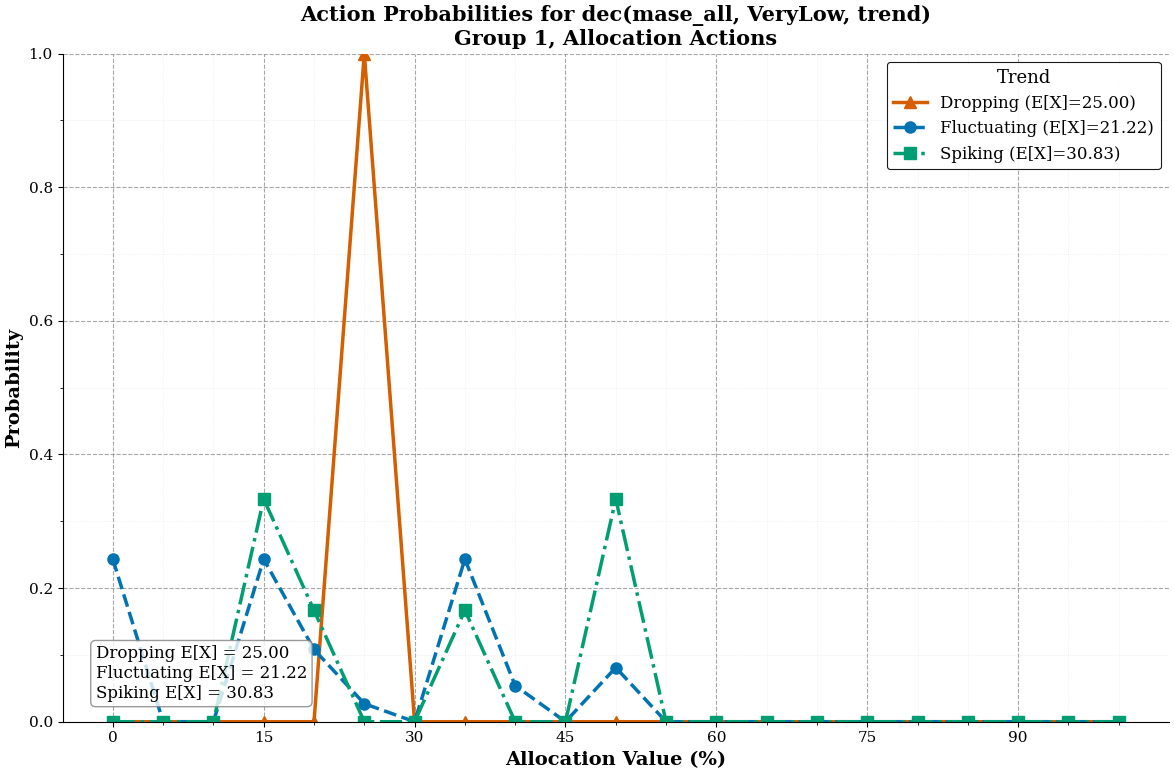

In [38]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MultipleLocator
import os
import tikzplotlib  # Import tikzplotlib for TeX export


# Configure matplotlib for publication quality - use more universally available fonts
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times', 'DejaVu Serif', 'Palatino', 'Computer Modern Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13,
    'figure.titlesize': 16,
    'figure.figsize': (12, 8),  # Much larger figure size
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'lines.linewidth': 2.5,     # Thicker lines like in example
    'lines.markersize': 8       # Larger markers
})

def plot_mase_all_verylow_states(action_probabilities, output_file=None):
    """
    Plot probability distributions for dec(mase_all, VeryLow) states with different trends for Group 1.
    
    Args:
        action_probabilities: Dictionary with structure 
                             {kpi -> {action_type -> {node -> {group -> {action -> probability}}}}}
        output_file: Path to save the output image
    """
    # Only use allocation actions
    action_type = 'alloc'
    
    # States to plot
    states = [
        'dec(mase_all, VeryLow, dropping)',
        'dec(mase_all, VeryLow, fluctuating)',
        'dec(mase_all, VeryLow, spiking)'
    ]
    
    # Shorter display names for legend
    state_display_names = [
        'Dropping',
        'Fluctuating',
        'Spiking'
    ]
    
    # Group to plot
    group = 'G1'
    
    # Create figure and axis with larger size
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get all possible actions for Group 1
    try:
        # Try to get actions from the first state (they should be the same for all states)
        all_actions = list(action_probabilities['mase_all'][action_type].get(states[0], {}).get(group, {}).keys())
        
        # If we couldn't get actions from the first state, try the others
        if not all_actions and len(states) > 1:
            for state in states[1:]:
                all_actions = list(action_probabilities['mase_all'][action_type].get(state, {}).get(group, {}).keys())
                if all_actions:
                    break
    except (KeyError, IndexError):
        # If there's an error, create a default list of actions
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        all_actions = [f"alloc({group}, {value})" for value in values]
    
    # Sort actions by the numeric value
    all_actions.sort(key=lambda x: int(x.split(", ")[1].split(")")[0]))
    
    # Extract just the numeric values for x-axis labels
    x_labels = [int(action.split(", ")[1].split(")")[0]) for action in all_actions]
    x_positions = np.arange(len(all_actions))
    
    # Use colorblind-friendly colors from the example
    colors = ['#D55E00', '#0173B2', '#029E73']  # Orange, Blue, Green like in example
    markers = ['^', 'o', 's']  # Triangle, circle, square like in example
    line_styles = ['-', '--', '-.']
    
    # Dictionary to store expected values
    expected_values = {}
    
    # Plot each state
    for i, (state, display_name) in enumerate(zip(states, state_display_names)):
        try:
            # Get probabilities for this state and group
            probabilities = []
            for action in all_actions:
                prob = action_probabilities['mase_all'][action_type].get(state, {}).get(group, {}).get(action, 0)
                probabilities.append(prob)
            
            # Calculate expected value (E[X] = sum(p_i * x_i))
            expected_value = sum(prob * val for prob, val in zip(probabilities, x_labels))
            expected_values[state] = expected_value
            
            # Plot the probabilities with thicker lines and larger markers
            ax.plot(x_positions, probabilities, 
                    label=f"{display_name} (E[X]={expected_value:.2f})",
                    color=colors[i % len(colors)],
                    marker=markers[i % len(markers)],
                    linestyle=line_styles[i % len(line_styles)],
                    linewidth=2.5,
                    markersize=8)
            
            # Print the expected value to console
            print(f"Expected value for {state}: {expected_value:.2f}")
            
        except KeyError:
            print(f"Warning: State '{state}' not found in the data. Skipping.")
    
    # Configure axis settings
    ax.set_xlabel(f'Allocation Value (%)', fontweight='bold')
    ax.set_ylabel('Probability', fontweight='bold')
    
    # Updated title with trend mentioned in the format representation
    ax.set_title(f'Action Probabilities for dec(mase_all, VeryLow, trend)\nGroup 1, Allocation Actions', fontweight='bold')
    
    # Set y-axis limits
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    
    # Set x-axis ticks and labels (show more values than before)
    # Show only every 3rd value to prevent crowding but still show enough
    ax.set_xticks(x_positions[::3])
    ax.set_xticklabels(x_labels[::3])
    
    # Add minor ticks
    ax.set_xticks(x_positions, minor=True)
    
    # Style the axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(which='major', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)
    ax.grid(which='minor', linestyle=':', linewidth=0.5, color='lightgray', alpha=0.5)
    
    # Updated legend title from "Pattern" to "Trend"
    legend = ax.legend(title='Trend', loc='best', frameon=True, 
                      edgecolor='black', framealpha=0.9)
    legend.get_frame().set_linewidth(0.8)
    
    # Add a text box with expected values
    textstr = '\n'.join([
        f"{name} E[X] = {expected_values.get(state, 0):.2f}" 
        for state, name in zip(states, state_display_names)
    ])
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.03, 0.03, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', bbox=props)
    
    # Add tight layout
    plt.tight_layout()
    
    # Save figure if output file specified
    if output_file:
        # Ensure output directory exists
        output_dir = os.path.dirname(output_file)
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir, exist_ok=True)
            
        # Save as PDF
        plt.savefig(output_file, dpi=600, bbox_inches='tight')
        print(f"Figure saved to {output_file}")
        
        # Save as TeX using tikzplotlib (instead of PNG)
        try:
            tex_file = output_file.replace('.pdf', '.tex')
            tikzplotlib.save(tex_file)
            print(f"Figure also saved as {tex_file} (TikZ)")
        except Exception as e:
            print(f"Warning: Could not save as TikZ file due to: {e}")
            print("Still saved the PDF version.")
    
    return fig, ax, expected_values  # Return expected values as part of the result

# Example usage
# Assuming action_probabilities is the dictionary created in the previous step

# Create output directory
output_dir = "./Paper_Plots_group_withfr/local"
os.makedirs(output_dir, exist_ok=True)

# Plot only for allocation actions and save to file
fig, ax, expected_values = plot_mase_all_verylow_states(
    action_probabilities, 
    # output_file=f"{output_dir}/mase_all_verylow_g1_alloc_mobicom.pdf"
)

# Print all expected values again at the end
print("\nSummary of Expected Values:")
for state, value in expected_values.items():
    print(f"{state}: {value:.2f}")

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
import numpy as np
import os
import tikzplotlib  # Import tikzplotlib for TeX export

def plot_multiple_kpis_matplotlib(test_df, symbolic_df=None, is_dfs=None, kpis=None, is_styles=None, group_id=0, center_timestep=None, window=None, font_size=12, save_path=None, export_tex=True):
    """
    Creates a matplotlib visualization with multiple subplots, one for each KPI and one for alloc_action,
    showing both raw KPI values, influence scores, and allocation actions for a specified group.
    Optionally filters the data to a time window around a center timestep.
  
    Parameters:
    -----------
    test_df : pandas.DataFrame
        DataFrame containing raw KPI values
    symbolic_df : pandas.DataFrame, optional
        DataFrame containing the alloc_action data
    is_dfs : list
        List of DataFrames containing influence scores
    kpis : list
        List of KPI names to plot (e.g., ['mase_all', 'dtu', 'ddtu'])
    is_styles : list, optional
        List of line styles for each is_df
    group_id : int, optional
        Group ID to plot (default: 0)
    center_timestep : int, optional
        Center timestep for time window filtering (default: None, uses all timesteps)
    window : int, optional
        Window size around center_timestep (default: None, uses all timesteps)
    font_size : int, optional
        Base font size for the plot (default: 12)
    save_path : str, optional
        Path to save the figure (default: None)
    export_tex : bool, optional
        Whether to also export as TeX using tikzplotlib (default: True)
  
    Returns:
    --------
    matplotlib.figure.Figure
    """
    # Configure matplotlib for publication quality - use more universally available fonts
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times', 'DejaVu Serif', 'Palatino', 'Computer Modern Roman'],
        'mathtext.fontset': 'stix',
        'font.size': font_size,
        'axes.labelsize': font_size + 2,
        'axes.titlesize': font_size + 3,
        'xtick.labelsize': font_size - 1,
        'ytick.labelsize': font_size - 1,
        'legend.fontsize': font_size,
        'legend.title_fontsize': font_size + 1,
        'figure.titlesize': font_size + 4,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.05,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'lines.linewidth': 2.5,     # Thicker lines
        'lines.markersize': 8       # Larger markers
    })
    
    # Set default values
    if is_dfs is None:
        is_dfs = []
    if kpis is None:
        kpis = []
    if is_styles is None:
        is_styles = ['dash', 'dot', 'dashdot'][:len(is_dfs)]
  
    # Preprocess the test dataframe if needed
    if 'group_id' not in test_df.columns:
        print("Preprocessing test_df for plotting")
        test_df = preprocess_test_df_for_plotting(test_df)
  
    # For mase_all, make sure mase_all column exists
    if 'mase_all' in kpis and 'mase_all' not in test_df.columns and 'mase' in test_df.columns:
        test_df['mase_all'] = test_df['mase'].copy()
      
    # Remove 'mase' if 'mase_all' is already in the list to avoid redundancy
    if 'mase_all' in kpis and 'mase' in kpis:
        kpis = [kpi for kpi in kpis if kpi != 'mase']
  
    # Filter data for specified group
    group_data = test_df[test_df['group_id'] == group_id].copy()
    
    # Filter symbolic data if provided
    symbolic_group_data = None
    if symbolic_df is not None and 'group_id' in symbolic_df.columns:
        symbolic_group_data = symbolic_df[symbolic_df['group_id'] == group_id].copy()
    elif symbolic_df is not None:
        # If we need to preprocess the symbolic dataframe
        if 'timestep' in symbolic_df.columns and 'group' in symbolic_df.columns:
            symbolic_group_data = preprocess_test_df_for_plotting(symbolic_df)
            symbolic_group_data = symbolic_group_data[symbolic_group_data['group_id'] == group_id].copy()
  
    # Get all unique timesteps
    all_timesteps = sorted(test_df['timestep'].unique())
  
    # Apply time window filtering if specified
    if center_timestep is not None and window is not None:
        min_timestep = center_timestep - window
        max_timestep = center_timestep + window
        all_timesteps = [ts for ts in all_timesteps if min_timestep <= ts <= max_timestep]
        
    # Ensure all timesteps are integers
    all_timesteps = [int(ts) for ts in all_timesteps]
    
    # Print timesteps for debugging
    print(f"Timesteps for plotting: {all_timesteps}")
  
    # Determine number of subplots (KPIs plus alloc_action if available)
    num_kpis = len(kpis)
    include_alloc = symbolic_group_data is not None
    total_subplots = num_kpis + (1 if include_alloc else 0)
  
    # Create a figure with subplots
    fig, axes = plt.subplots(total_subplots, 1, figsize=(15, 6 * total_subplots), sharex=True)
  
    # If only one subplot, axes will not be an array, so we make it one for consistency
    if total_subplots == 1:
        axes = [axes]
  
    # Define colors
    raw_color = '#1f77b4'  # Blue for raw values
    mase1_color = '#9467bd'  # Purple for mase1 values (if applicable)
    is_colors = ['#ff7f0e', '#2ca02c', '#d62728']  # Orange, Green, Red for influence scores
    scheduled_marker_color = 'green'  # Green markers for scheduled actions
    alloc_color = '#e377c2'  # Pink for allocation values
    
    # Define annotation colors
    annotation_colors = {
        991 + 10: 'red',      # Timestep 11 (1001) - VeryLow
        991 + 11: 'green',    # Timestep 12 (1002) - High
        991 + 12: 'blue'      # Timestep 13 (1003) - VeryHigh
    }
  
    # Process each KPI
    for i, kpi in enumerate(kpis):
        ax1 = axes[i]
        ax2 = ax1.twinx()
      
        # Prepare data for plotting
        raw_values = []
        timesteps_list = []
        mase1_values = [] if kpi == 'mase_all' else None
      
        # For each timestep, get the KPI value if available, otherwise use 0
        for ts in all_timesteps:
            matching_rows = group_data[group_data['timestep'] == ts]
            if not matching_rows.empty:
                # Get the row for this timestep
                row = matching_rows.iloc[0]
                if kpi in row and row[kpi] is not None:
                    raw_values.append(row[kpi])
                    timesteps_list.append(ts)
                else:
                    raw_values.append(0)
                    timesteps_list.append(ts)
              
                # Get mase1 value if plotting mase_all
                if kpi == 'mase_all' and 'mase1' in row:
                    mase1_values.append(row['mase1'] if row['mase1'] is not None else 0)
            else:
                # If group doesn't exist at this timestep, use 0
                raw_values.append(0)
                timesteps_list.append(ts)
              
                # Add 0 for mase1 if plotting mase_all
                if kpi == 'mase_all':
                    mase1_values.append(0)
                    
        # Print data for debugging
        print(f"Timesteps for {kpi}: {timesteps_list}")
        print(f"Values for {kpi}: {raw_values}")
      
        # Plot Raw KPI values
        line1 = ax1.plot(timesteps_list, raw_values, color=raw_color, label=f'Raw {kpi.upper()}', linewidth=1.2)
      
        # Plot Raw MASE1 if plotting mase_all
        line2 = []
        if kpi == 'mase_all' and mase1_values:
            line2 = ax1.plot(timesteps_list, mase1_values, color=mase1_color, linestyle='--', 
                            label='Raw MASE1', linewidth=1.2)
      
        # Add markers for scheduled actions
        scheduled_timesteps = []
        scheduled_values = []
      
        for idx, row in group_data.iterrows():
            # Get action data for this group
            action_data = row.get('action', [])
          
            # Check if this group is scheduled
            is_scheduled = False
            if isinstance(action_data, list):
                # For list of actions, check if any contains scheduling
                for action in action_data:
                    if isinstance(action, str) and 'sched(user' in action.lower() and 'notsched(user' not in action.lower():
                        is_scheduled = True
                        break
            elif isinstance(action_data, str):
                # For string action, check if it contains scheduling
                if 'sched(user' in action_data.lower() and 'notsched(user' not in action_data.lower():
                    is_scheduled = True
          
            # If scheduled, add to markers
            if is_scheduled:
                scheduled_timesteps.append(row['timestep'])
                scheduled_values.append(row[kpi] if kpi in row else 0)
      
        scatter = None
        if scheduled_timesteps:
            scatter = ax1.scatter(scheduled_timesteps, scheduled_values, color=scheduled_marker_color, marker='o', s=50, label='Scheduled')

        # Process and add influence score traces for each IS dataframe
        is_lines = []
      
        for df_idx, (is_df, is_style) in enumerate(zip(is_dfs, is_styles)):
            is_values = []
            is_timesteps = []
            delta_type = is_df['delta_type'].iloc[0] if 'delta_type' in is_df else f"type_{df_idx}"

            for ts in all_timesteps:
                # Find the row in is_df for this timestep
                is_row = is_df[is_df['timestep'] == ts]
              
                if not is_row.empty:
                    # Get influence scores for this timestep
                    influence_scores = is_row.iloc[0]['influence_scores']

                    # Check if influence_scores has an entry for the specified group
                    if isinstance(influence_scores, list) and len(influence_scores) > group_id:
                        if isinstance(influence_scores[group_id], dict) and kpi in influence_scores[group_id]:
                            is_values.append(influence_scores[group_id][kpi])
                            is_timesteps.append(ts)
                        else:
                            is_values.append(0)
                            is_timesteps.append(ts)
                    else:
                        is_values.append(0)
                        is_timesteps.append(ts)
                else:
                    is_values.append(0)
                    is_timesteps.append(ts)

            # Convert is_style from Plotly to Matplotlib format
            if is_style == 'dash':
                mpl_style = '--'
            elif is_style == 'dot':
                mpl_style = ':'
            elif is_style == 'dashdot':
                mpl_style = '-.'
            else:
                mpl_style = '-'

            # Map delta_type to labels that match the legend in the example
            if 'binary' in delta_type.lower():
                label = 'IS binary'
            elif 'decay' in delta_type.lower():
                label = 'IS decaying'
            elif 'hierarch' in delta_type.lower():
                label = 'IS hierarchical'
            else:
                label = f'IS {delta_type}'

            # Add trace for influence scores with appropriate style
            line = ax2.plot(is_timesteps, is_values, color=is_colors[df_idx % len(is_colors)], 
                           linestyle=mpl_style, label=label, linewidth=1.2)
            is_lines.append(line[0])

        # Set labels and titles
        if i == total_subplots - 1:  # Only set x-label for the bottom subplot
            ax1.set_xlabel('Relative Timestep Position', fontsize=font_size, fontweight='bold')

        ax1.set_ylabel(f'{kpi.upper()} Value', fontsize=font_size, fontweight='bold')
        ax2.set_ylabel('Influence Score', fontsize=font_size, fontweight='bold')

        # Set appropriate y-axis range based on the data
        if kpi == 'mase_all':
            max_value = max(raw_values) if raw_values else 3.5
            ax1.set_ylim(0, max(3.5, max_value * 1.1))
            ax2.set_ylim(0, 0.8)
        else:
            max_value = max(raw_values) if raw_values else 1.0
            ax1.set_ylim(0, max(1.0, max_value * 1.1))

            # Set influence score y-axis range based on the data
            max_is = 0
            for df_idx, is_df in enumerate(is_dfs):
                for ts in all_timesteps:
                    is_row = is_df[is_df['timestep'] == ts]
                    if not is_row.empty:
                        influence_scores = is_row.iloc[0]['influence_scores']
                        if isinstance(influence_scores, list) and len(influence_scores) > group_id:
                            if isinstance(influence_scores[group_id], dict) and kpi in influence_scores[group_id]:
                                max_is = max(max_is, influence_scores[group_id][kpi])

            ax2.set_ylim(0, max(0.8, max_is * 1.2))

        # Set title for each subplot
        title_text = f"{kpi.upper()} with Influence Scores"
        if kpi == 'mase_all':
            title_text += " (with MASE1 (one timstep forecast) comparison)"
        ax1.set_title(title_text, fontsize=font_size*1.1, fontweight='bold')

        # Add legends
        all_lines = line1 + line2 + is_lines
        all_labels = [f'Raw {kpi.upper()}']
        if kpi == 'mase_all':
            all_labels.append('Raw MASE1')
        all_labels.extend([line.get_label() for line in is_lines])

        if scatter:
            all_lines.append(scatter)
            all_labels.append('Scheduled')

        ax1.legend(all_lines, all_labels, loc='upper right', fontsize=font_size*0.8)

        # Set tick font sizes
        ax1.tick_params(axis='both', labelsize=font_size*0.9)
        ax2.tick_params(axis='both', labelsize=font_size*0.9)

        # Set grid
        ax1.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)

        # Style the axes for publication quality
        ax1.spines['top'].set_visible(False)
        ax2.spines['top'].set_visible(False)

        # ========================= ADD KPI ANNOTATIONS =========================
        # Define critical timesteps (1001, 1002, 1003) - these are the actual timestep values
        critical_timesteps = [991 + 10, 991 + 11, 991 + 12]  # 1001, 1002, 1003
        
        # Map critical timesteps to relative positions (1-based indexing for display)
        critical_relative_positions = {
            991 + 10: 11,  # 1001 -> 11
            991 + 11: 12,  # 1002 -> 12 
            991 + 12: 13   # 1003 -> 13
        }
        
        # Define annotation texts
        annotation_texts = {
            991 + 10: "DDTU hits VeryLow",
            991 + 11: "Agent starts to again\nallocate resources\nto group 0 and\nDDTU hits High",
            991 + 12: "DDTU hits VeryHigh"
        }
        
        # Add annotations for KPI plot
        if kpi.lower() == 'ddtu':
            print(f"Attempting to add annotations for {kpi}...")
            
            for ts in critical_timesteps:
                # Find the index of this timestep in our data
                if ts in timesteps_list:
                    # Get the data point value
                    idx = timesteps_list.index(ts)
                    value = raw_values[idx]
                    
                    print(f"Adding annotation for timestep {ts} at index {idx} with value {value}")
                    
                    # Define arrow properties - make them more visible
                    arrow_props = dict(
                        arrowstyle='-|>',
                        linewidth=2,
                        color=annotation_colors[ts],
                        connectionstyle='arc3,rad=0.2'
                    )
                    
                    # Adjust text position and offsets based on the timestep
                    if ts == 991 + 10:  # Timestep 11 (1001)
                        y_offset = 0.8 if value < 0.5 else -0.8
                        text_offset = (0, y_offset)
                        va = 'bottom' if y_offset > 0 else 'top'
                    elif ts == 991 + 11:  # Timestep 12 (1002)
                        y_offset = 0.8 if value < 1.5 else -0.8
                        text_offset = (0, y_offset)
                        va = 'bottom' if y_offset > 0 else 'top'
                    else:  # Timestep 13 (1003)
                        y_offset = -0.8 if value > 1.5 else 0.8
                        text_offset = (0, y_offset)
                        va = 'top' if y_offset < 0 else 'bottom'
                    
                    # Create annotation
                    ax1.annotate(
                        annotation_texts[ts],
                        xy=(ts, value),  # Point to annotate
                        xytext=text_offset,  # Offset text
                        textcoords='offset points',
                        xycoords='data',
                        fontsize=font_size*0.9,
                        fontweight='bold',
                        ha='center',
                        va=va,
                        color=annotation_colors[ts],
                        arrowprops=arrow_props,
                        bbox=dict(
                            boxstyle="round,pad=0.5",
                            facecolor='white',
                            edgecolor=annotation_colors[ts],
                            alpha=0.8
                        )
                    )
        else:
            print(f"Skipping annotations for {kpi} (not DDTU)")

    # Add alloc_action subplot if symbolic data is available
    if include_alloc:
        alloc_ax = axes[num_kpis]  # Use the last subplot for alloc_action
        
        # Prepare data for plotting
        alloc_values = []
        alloc_timesteps = []
        
        # Extract alloc_action values
        for ts in all_timesteps:
            if symbolic_group_data is not None:
                matching_rows = symbolic_group_data[symbolic_group_data['timestep'] == ts]
                if not matching_rows.empty:
                    # Get the row for this timestep
                    row = matching_rows.iloc[0]
                    if 'alloc_action' in row and row['alloc_action'] is not None:
                        # Extract numeric value if it's in a format like 'alloc(G0, 100)'
                        alloc_value = row['alloc_action']
                        if isinstance(alloc_value, str) and alloc_value.startswith('alloc('):
                            # Extract the number after the comma
                            try:
                                alloc_value = float(alloc_value.split(',')[-1].strip().rstrip(')'))
                            except (ValueError, IndexError):
                                alloc_value = 0
                        alloc_values.append(alloc_value)
                        alloc_timesteps.append(ts)
                    else:
                        alloc_values.append(0)
                        alloc_timesteps.append(ts)
                else:
                    alloc_values.append(0)
                    alloc_timesteps.append(ts)
            else:
                alloc_values.append(0)
                alloc_timesteps.append(ts)
        
        # Plot alloc_action values
        alloc_ax.plot(alloc_timesteps, alloc_values, color=alloc_color, label='Allocation Value', linewidth=1.5)
        
        # Set labels and title
        if num_kpis == total_subplots - 1:  # Only set x-label for the bottom subplot
            alloc_ax.set_xlabel('Relative Timestep Position', fontsize=font_size, fontweight='bold')
        
        alloc_ax.set_ylabel('Allocation Value', fontsize=font_size, fontweight='bold')
        alloc_ax.set_title('Allocation Actions for Group ' + str(group_id), fontsize=font_size*1.1, fontweight='bold')
        
        # Set appropriate y-axis range
        max_alloc = max(alloc_values) if alloc_values else 100
        alloc_ax.set_ylim(0, max(100, max_alloc * 1.1))
        
        # Add legend
        alloc_ax.legend(loc='upper right', fontsize=font_size*0.8)
        
        # Set tick font sizes
        alloc_ax.tick_params(axis='both', labelsize=font_size*0.9)
        
        # Set grid
        alloc_ax.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        # Style the axes for publication quality
        alloc_ax.spines['top'].set_visible(False)
        alloc_ax.spines['right'].set_visible(False)
        
        # ========================= ADD ALLOCATION ANNOTATIONS =========================
        # Define annotation texts for allocation subplot
        alloc_annotation_texts = {
            991 + 10: "Allocation decreased",
            991 + 11: "Allocation increasing",
            991 + 12: "Allocation at max"
        }
        
        print("Attempting to add annotations for allocation plot...")
        for ts in critical_timesteps:
            # Find the index of this timestep in our data
            if ts in alloc_timesteps:
                # Get the data point value
                idx = alloc_timesteps.index(ts)
                value = alloc_values[idx]
                
                print(f"Adding allocation annotation for timestep {ts} at index {idx} with value {value}")
                
                # Define arrow properties - make them more visible
                arrow_props = dict(
                    arrowstyle='-|>',
                    linewidth=2,
                    color=annotation_colors[ts],
                    connectionstyle='arc3,rad=-0.2'  # Use negative arc for allocation
                )
                
                # Determine text position based on timestep
                if ts == 991 + 10:  # Timestep 11 (1001)
                    y_offset = -20
                    x_offset = -2
                elif ts == 991 + 11:  # Timestep 12 (1002)
                    y_offset = 20
                    x_offset = 2
                else:  # Timestep 13 (1003)
                    y_offset = -20
                    x_offset = 1
                
                # Create annotation
                alloc_ax.annotate(
                    alloc_annotation_texts[ts],
                    xy=(ts, value),  # Point to annotate
                    xytext=(ts + x_offset, value + y_offset),  # Offset text
                    fontsize=font_size*0.9,
                    fontweight='bold',
                    ha='center',
                    color=annotation_colors[ts],
                    arrowprops=arrow_props,
                    bbox=dict(
                        boxstyle="round,pad=0.5",
                        facecolor='white',
                        edgecolor=annotation_colors[ts],
                        alpha=0.8
                    )
                )
  
    # Set a common title for the entire figure
    title = f'Group {group_id} KPI Values with Influence Scores and Allocation Actions'
    if center_timestep is not None and window is not None:
        title += f' (Timesteps {center_timestep-window} to {center_timestep+window})'
    fig.suptitle(title, fontsize=font_size*1.3, fontweight='bold')
  
    # Configure x-axis ticks to show relative timestep numbers (starting from 1)
    relative_timesteps = list(range(1, len(all_timesteps) + 1))
    
    # Create a mapping from actual timesteps to relative positions
    timestep_to_relative = {ts: i+1 for i, ts in enumerate(all_timesteps)}
    
    for ax in axes:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.set_xticks(all_timesteps)
        ax.set_xticklabels(relative_timesteps)
        
        # Make sure the x-axis labels are visible on all subplots
        ax.tick_params(axis='x', labelbottom=True)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.4)  # Increase hspace to leave more room for x-axis ticks
  
    # Save if path provided
    if save_path:
        # Ensure the directory exists
        save_dir = os.path.dirname(save_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
            
        # Save as PDF with high resolution
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
        
        # Save as TeX using tikzplotlib if requested
        if export_tex:
            try:
                tex_file = save_path.replace('.pdf', '.tex').replace('.png', '.tex')
                tikzplotlib.save(tex_file)
                print(f"Figure also saved as {tex_file} (TikZ)")
            except Exception as e:
                print(f"Warning: Could not save as TikZ file due to: {e}")
                print("Still saved the PDF/PNG version.")
  
    return fig


# Example usage with PDF and TeX export
kpis = ['ddtu']
is_styles = ['dash']

# Create output directory
output_dir = "./Paper_Plots/local_influence"
os.makedirs(output_dir, exist_ok=True)

fig = plot_multiple_kpis_matplotlib(
    test_df=train_df,
    symbolic_df=train_symbolic_df,
    is_dfs=[IS_df_decaying],
    kpis=kpis,
    is_styles=is_styles,
    group_id=0,
    center_timestep=1001,  # Center around timestep 1001
    window=10,            # Show 10 timesteps before and after
    font_size=18,
    save_path=f'{output_dir}/kpi_plot_with_annotations.pdf',
    export_tex=True  # Also export as TeX
)
plt.show()

# Visualizations

## Plot of Numerical KPI per user

In [ ]:
def plot_individual_user_metrics(test_df, kpis=['mase', 'ddtu'], dataset_name="test_data"):
    """
    Creates individual plots for each user with specified KPIs.

    Parameters:
        test_df (pd.DataFrame): DataFrame containing timestep and KPI columns with arrays of values
        kpis (list): List of KPI names to plot (e.g., ['mase', 'dtu', 'ddtu'])
        dataset_name (str): Name of the dataset for folder creation

    Returns:
        list: List of figures, one for each user
    """
    # Validate that all requested KPIs exist in the dataframe
    for kpi in kpis:
        if kpi not in test_df.columns:
            raise ValueError(f"KPI '{kpi}' not found in the DataFrame columns")

    # Create visualization folder
    vis_name = "individual_user_metrics"
    folder_path = create_visualization_folder_path(vis_name, dataset_name)

    # Define colors for each user
    colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
        '#9467bd', '#8c564b', '#e377c2'
    ]

    # Create a display name mapping for KPIs
    kpi_display_names = {
        'mase': 'MASE',
        'dtu': 'DTU',
        'ddtu': 'DDTU'
        # Add more KPIs here as needed
    }

    figures = []

    # Create individual figure for each user
    for user_idx in range(7):
        # Create n×1 subplots for this user (n = number of KPIs)
        num_kpis = len(kpis)
        subplot_titles = [f"User {user_idx+1} {kpi_display_names.get(kpi, kpi.upper())}" for kpi in kpis]

        fig = make_subplots(
            rows=num_kpis, cols=1,
            subplot_titles=subplot_titles,
            shared_xaxes=True,
            vertical_spacing=0.1
        )

        # Extract and plot each KPI for this user
        for i, kpi in enumerate(kpis):
            # Extract values for this KPI and user
            values = []
            for row in test_df.itertuples():
                kpi_values = getattr(row, kpi)
                if isinstance(kpi_values, list) and len(kpi_values) > user_idx:
                    values.append(kpi_values[user_idx])
                else:
                    values.append(None)  # Handle missing data

            # Add trace for this KPI
            fig.add_trace(
                go.Scatter(
                    x=test_df['timestep'],
                    y=values,
                    mode='lines',
                    name=kpi_display_names.get(kpi, kpi.upper()),
                    line=dict(color=colors[user_idx]),
                ),
                row=i+1, col=1
            )

            # Update y-axis label for this KPI
            fig.update_yaxes(
                title_text=f"{kpi_display_names.get(kpi, kpi.upper())} Value",
                row=i+1,
                col=1
            )

            # Add x-axis label only for the bottom plot
            if i == num_kpis - 1:
                fig.update_xaxes(title_text="Timestep", row=i+1, col=1)

        # Update layout for better visualization
        fig.update_layout(
            height=300 * num_kpis,  # Height scales with number of KPIs
            title_text=f"Metrics for User {user_idx+1} Over Time",
            hovermode='x unified',
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=-0.15,
                xanchor="center",
                x=0.5
            )
        )

        # Save the figure
        # kpi_str = "_".join(kpis)
        # png_filename = os.path.join(folder_path, f"user_{user_idx+1}_{kpi_str}_{dataset_name}.png")
        # fig.write_image(png_filename)
        # print(f"User {user_idx+1} metrics plot saved as PNG to: {png_filename}")

        # html_filename = os.path.join(folder_path, f"user_{user_idx+1}_{kpi_str}_{dataset_name}.html")
        # fig.write_html(html_filename)
        # print(f"User {user_idx+1} metrics plot saved as HTML to: {html_filename}")

        fig.show()
        # figures.append(fig)

    # return figures

# Example usage:
# Plot all three metrics
all_metrics_figures = plot_individual_user_metrics(test_df, kpis=['rddtu_a'], dataset_name="test_dataset")

# Plot only MASE and DDTU
# mase_ddtu_figures = plot_individual_user_metrics(test_df, kpis=['mase', 'ddtu'], dataset_name="mase_ddtu_only")

## Plot of Scheduling per user

In [ ]:
def plot_scheduling_patterns(test_df, dataset_name="test_data"):
    """
    Plots scheduling patterns for each user over time based on action data,
    with markers colored according to the user's group, and showing group colors
    for both scheduled and unscheduled time points.
    
    Parameters:
    test_df (pd.DataFrame): DataFrame containing timestep, action, and group columns
    dataset_name (str): Name of the dataset for folder creation
    """
    # Create visualization folder
    vis_name = "scheduling_patterns"
    folder_path = create_visualization_folder_path(vis_name, dataset_name)
    
    # Function to extract scheduled users from action string
    def get_scheduled_users(action_str):
        if not isinstance(action_str, str):
            return []
        matches = re.findall(r'\d+', action_str)
        return [int(m) for m in matches]
    
    # Define colors for each group
    group_colors = {
        0: '#1f77b4',  # Blue
        1: '#ff7f0e',  # Orange
        2: '#2ca02c',  # Green
        3: '#d62728',  # Red
        4: '#9467bd',  # Purple
        5: '#8c564b',  # Brown
        6: '#e377c2'   # Pink
    }
    
    # Create subplots with a line plot for each user
    fig = make_subplots(
        rows=7, cols=1,
        subplot_titles=[f"User {i+1} Scheduling" for i in range(7)],
        shared_xaxes=True,
        vertical_spacing=0.03
    )
    
    # Prepare matrices for both scheduled status and group membership
    scheduling_matrix = np.zeros((len(test_df), 7))
    group_matrix = np.zeros((len(test_df), 7), dtype=int)
    
    # Extract scheduled status and group for each user at each timestep
    for i, row in enumerate(test_df.itertuples()):
        # Get scheduled users
        scheduled_users = get_scheduled_users(row.action)
        for user in scheduled_users:
            if 0 <= user < 7:  # Ensure it's a valid user index
                scheduling_matrix[i, user] = 1
        
        # Get group for each user
        if hasattr(row, 'group') and isinstance(row.group, list):
            for user_idx in range(min(7, len(row.group))):
                group_matrix[i, user_idx] = row.group[user_idx] if row.group[user_idx] is not None else 0
    
    # First add connecting lines for each user's scheduling status
    for user_idx in range(7):
        # Add the connecting line for all points
        fig.add_trace(
            go.Scatter(
                x=test_df['timestep'],
                y=scheduling_matrix[:, user_idx],
                mode='lines',
                line=dict(color='gray', width=1),  # Use light gray for the line
                name=f'User {user_idx+1} (line)',
                showlegend=False  # Don't show in legend
            ),
            row=user_idx+1, col=1
        )
    
    # Add traces for each user's points
    for user_idx in range(7):
        # Process each group separately for this user
        for group_idx in range(3):  # Process only first 3 groups
            # Find all points where this user is in this group
            group_points = np.where(group_matrix[:, user_idx] == group_idx)[0]
            
            if len(group_points) > 0:
                # Get timesteps for these points
                timesteps = test_df.iloc[group_points]['timestep'].values
                
                # Get scheduled status for these points
                is_scheduled = scheduling_matrix[group_points, user_idx]
                
                # Points where user is in this group AND scheduled
                scheduled_points = group_points[is_scheduled == 1]
                
                # Points where user is in this group but NOT scheduled
                unscheduled_points = group_points[is_scheduled == 0]
                
                # Add trace for scheduled points
                if len(scheduled_points) > 0:
                    scheduled_timesteps = test_df.iloc[scheduled_points]['timestep'].values
                    fig.add_trace(
                        go.Scatter(
                            x=scheduled_timesteps,
                            y=np.ones(len(scheduled_points)),
                            mode='markers',
                            marker=dict(
                                color=group_colors[group_idx],
                                size=8
                            ),
                            name=f'User {user_idx+1} Group {group_idx}',
                            showlegend=True
                        ),
                        row=user_idx+1, col=1
                    )
                else:
                    # Add dummy trace for legend if no scheduled points
                    fig.add_trace(
                        go.Scatter(
                            x=[None],
                            y=[None],
                            mode='markers',
                            marker=dict(
                                color=group_colors[group_idx],
                                size=8
                            ),
                            name=f'User {user_idx+1} Group {group_idx}',
                            showlegend=True
                        ),
                        row=user_idx+1, col=1
                    )
                
                # Add trace for unscheduled points
                if len(unscheduled_points) > 0:
                    unscheduled_timesteps = test_df.iloc[unscheduled_points]['timestep'].values
                    fig.add_trace(
                        go.Scatter(
                            x=unscheduled_timesteps,
                            y=np.zeros(len(unscheduled_points)),
                            mode='markers',
                            marker=dict(
                                color=group_colors[group_idx],
                                size=8,
                                opacity=0.3  # Make unscheduled markers semi-transparent
                            ),
                            name=f'User {user_idx+1} Group {group_idx} (Not Scheduled)',
                            showlegend=False  # Don't show separate legend for unscheduled
                        ),
                        row=user_idx+1, col=1
                    )
    
    # Update layout for better visualization
    fig.update_layout(
        height=1800,  # Taller to accommodate 7 rows
        # width=1200,
        title_text="User Scheduling Patterns Over Time (Colored by Group)",
        hovermode='x unified',
        # Move legend outside the plot area with increased font size
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.15,  # Move below the plot
            xanchor="center",
            x=0.5,
            font=dict(size=14),  # Increased font size for legend
            groupclick="toggleitem"
        ),
        font=dict(size=12)  # Increase the font size globally
    )
    
    # Update axes labels and ranges
    for i in range(1, 8):
        fig.update_yaxes(
            title_text="Scheduled",
            title_font=dict(size=14),  # Increased font size for y-axis title
            tickfont=dict(size=12),    # Increased font size for y-axis tick labels
            range=[-0.1, 1.1],         # Slightly expand y range for better visibility
            tickvals=[0, 1],
            ticktext=["No", "Yes"],
            row=i, col=1
        )
        
        # Only add x-axis label for the bottom plot
        if i == 7:
            fig.update_xaxes(
                title_text="Timestep", 
                title_font=dict(size=14),  # Increased font size for x-axis title
                tickfont=dict(size=12),    # Increased font size for x-axis tick labels
                row=i, col=1
            )
    
    # Update subplot titles with larger font
    for i in fig['layout']['annotations']:
        i['font'] = dict(size=16)  # Increase subplot title font size
    
    # Save and display the plot
    png_filename = os.path.join(folder_path, f"scheduling_patterns_by_user_group_{dataset_name}.png")
    fig.write_image(png_filename, height=2000, width=1200)  # Slightly taller to accommodate legend
    print(f"Scheduling patterns plot saved as PNG to: {png_filename}")
    
    html_filename = os.path.join(folder_path, f"scheduling_patterns_by_user_group_{dataset_name}.html")
    fig.write_html(html_filename)
    print(f"Scheduling patterns plot saved as HTML to: {html_filename}")
    
    # Return the figure for display
    return fig

# Example usage:
fig = plot_scheduling_patterns(test_df, "test_dataset")
fig.show()

## Visualize the Markers and the approximator effect

In [ ]:
def plot_user_with_multiple_kpis(
    flat_df: pd.DataFrame,
    markers_df: pd.DataFrame,
    kpis: List[str] = ['mase', 'dtu'],
    users: List[int] = None,  # Specify which users to plot; default is all users 1-7.
    timestep_col: str = 'timestep',
    marker_kpi_col: str = 'kpi',
    dataset_name: str = 'mimo',
    output_dir: str = './visualizations',
    specific_name: str = "",
    title: Optional[str] = None,
    do_save: bool = False
):
    """
    Creates a figure for each user showing multiple KPIs with their markers.
    Highlights timesteps where the user was scheduled in the action.

    Parameters:
        flat_df (pd.DataFrame): The flattened dataframe with individual user KPI columns.
        markers_df (pd.DataFrame): The markers dataframe with quantile data.
        kpis (List[str]): List of base KPI names to plot (without user suffix). Any "mse" will be converted to "mase".
        users (List[int]): List of user numbers to plot. If None, will plot all users (1-7).
        timestep_col (str): Name of the timestep column.
        marker_kpi_col (str): Name of the KPI column in markers_df.
        dataset_name (str): Name of the dataset for saving files.
        output_dir (str): Directory to save output files.
        specific_name (str): Optional name to include in output filenames.
        title (str): Plot title template (will be formatted with user number).
        do_save (bool): Whether to save the figures or just display them.
    """
    # Ensure that any 'mse' in kpis is replaced with 'mase'
    kpis = ['mase' if kpi.lower() == 'mse' else kpi for kpi in kpis]

    # Create output directory if saving is enabled
    if do_save:
        vis_folder = os.path.join(output_dir, f"user_multi_kpi_{dataset_name}")
        if specific_name:
            vis_folder = os.path.join(vis_folder, specific_name)
        os.makedirs(vis_folder, exist_ok=True)

    # Define plot settings
    colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
    ]

    # Default to plotting users 1 through 7 if not specified
    if users is None:
        users = list(range(1, 8))

    # Function to check if a user is in the action at a given timestep
    def is_user_in_action(row, user_num):
        action_str = row['action']
        if isinstance(action_str, str):
            # Parse the action string to get the list of users
            # The action is typically in format like "(0, 1, 2, 3, 5)"
            # Need to extract numbers and check if user_num-1 is in it
            # (subtract 1 since action often uses 0-indexed users)
            matches = re.findall(r'\d+', action_str)
            action_users = [int(match) for match in matches]
            return (user_num - 1) in action_users
        return False

    # Create a figure for each user with all specified KPIs
    for user_num in users:
        num_kpis = len(kpis)
        subplot_titles = [f"User {user_num} {kpi.upper()}" for kpi in kpis]

        fig = make_subplots(
            rows=num_kpis,
            cols=1,
            subplot_titles=subplot_titles,
            shared_xaxes=True,
            vertical_spacing=0.08
        )

        # Plot each KPI for the current user
        for kpi_idx, kpi_base in enumerate(kpis):
            kpi_col = f"{kpi_base}_user_{user_num}"

            # Plot the actual KPI values if the column exists
            if kpi_col in flat_df.columns:
                # Create main KPI line
                fig.add_trace(
                    go.Scatter(
                        x=flat_df[timestep_col],
                        y=flat_df[kpi_col],
                        mode='lines',
                        name=f'{kpi_base.upper()} Actual',
                        line=dict(color=colors[kpi_idx % len(colors)], width=2),
                        legendgroup=f'kpi_{kpi_base}',
                        showlegend=True
                    ),
                    row=kpi_idx+1, col=1
                )

                # Add markers for timesteps where this user is in the action
                action_timesteps = []
                action_values = []
                for idx, row in flat_df.iterrows():
                    if is_user_in_action(row, user_num):
                        action_timesteps.append(row[timestep_col])
                        action_values.append(row[kpi_col])
                
                # Only add the action markers trace if there are any points
                if action_timesteps:
                    fig.add_trace(
                        go.Scatter(
                            x=action_timesteps,
                            y=action_values,
                            mode='markers',
                            marker=dict(
                                symbol='star',
                                size=10,
                                color=colors[kpi_idx % len(colors)],
                                line=dict(width=1, color='black')
                            ),
                            name=f'Scheduled in Action',
                            legendgroup='action',
                            showlegend=(kpi_idx == 0)  # Only show in legend once
                        ),
                        row=kpi_idx+1, col=1
                    )

                # Get marker data for this KPI
                marker_data = markers_df[markers_df[marker_kpi_col] == kpi_base].copy()

                # Plot each marker line (percentiles)
                for marker_idx, marker in enumerate(['min', 'p20', 'p40', 'p60', 'p80', 'max']):
                    if marker in marker_data.columns:
                        # Use more muted colors for the marker lines
                        marker_opacity = 0.4 
                        
                        fig.add_trace(
                            go.Scatter(
                                x=marker_data[timestep_col],
                                y=marker_data[marker],
                                mode='lines',
                                name=f'{marker.upper()}',
                                line=dict(
                                    color=colors[kpi_idx % len(colors)],
                                    width=1,
                                    dash='dash'
                                ),
                                opacity=marker_opacity,
                                legendgroup=f'markers_{kpi_base}',
                                showlegend=(kpi_idx == 0 and marker_idx == 0)  # Only show one marker in legend
                            ),
                            row=kpi_idx+1, col=1
                        )

        # Improved layout settings for the figure
        height_per_kpi = 350
        fig.update_layout(
            height=height_per_kpi * num_kpis,
            title_text=title.format(user_num=user_num) if title else f"User {user_num} - Multiple KPIs with Markers",
            title_font=dict(size=20, family="Arial", color="black"),
            title_x=0.5,
            margin=dict(t=100, b=50, l=100, r=50),  # Add more space for title and legend
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.05,  # Position above the plot
                xanchor="center",
                x=0.5,
                bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent background
                bordercolor="Gray",
                borderwidth=1,
                font=dict(size=12),
                itemsizing="constant"  # Make legend items the same size
            ),
            hovermode='x unified'
        )

        # Set y-axis labels for each KPI subplot
        for i, kpi_base in enumerate(kpis):
            fig.update_yaxes(
                title_text=f"{kpi_base.upper()} Value", 
                row=i+1, 
                col=1,
                title_font=dict(size=14),
                gridcolor='rgba(200, 200, 200, 0.2)'  # Lighter grid lines
            )

        # Set x-axis label only for the bottom subplot
        fig.update_xaxes(
            title_text="Timestep", 
            row=num_kpis, 
            col=1,
            title_font=dict(size=14),
            gridcolor='rgba(200, 200, 200, 0.2)'  # Lighter grid lines
        )

        # Save or display the plot
        if do_save:
            filename_base = f"user_{user_num}_multi_kpi"
            if specific_name:
                filename_base += f"_{specific_name}"

            png_path = os.path.join(vis_folder, f"{filename_base}.png")
            fig.write_image(png_path)
            print(f"Plot saved as PNG: {png_path}")

            html_path = os.path.join(vis_folder, f"{filename_base}.html")
            fig.write_html(html_path)
            print(f"Plot saved as HTML: {html_path}")
        else:
            fig.show()

def plot_kpis_with_markers_per_user(
    flat_df: pd.DataFrame,
    markers_df: pd.DataFrame,
    kpis: List[str] = ['mase', 'dtu'],
    num_users: int = 7,
    timestep_col: str = 'timestep',
    marker_kpi_col: str = 'kpi',
    dataset_name: str = 'mimo',
    output_dir: str = './visualizations',
    specific_name: str = "",
    title: Optional[str] = None,
    do_save: bool = False
):
    """
    Plots KPI values for each user along with their markers.
    Highlights timesteps where the user was scheduled in the action.

    Parameters:
        flat_df (pd.DataFrame): The flattened dataframe with individual user KPI columns.
        markers_df (pd.DataFrame): The markers dataframe with quantile data.
        kpis (List[str]): List of base KPI names to plot (without user suffix). If "mse" is provided, it will be converted to "mase".
        num_users (int): Number of users to plot.
        timestep_col (str): Name of the timestep column.
        marker_kpi_col (str): Name of the KPI column in markers_df.
        dataset_name (str): Name of the dataset for saving files.
        output_dir (str): Directory to save output files.
        specific_name (str): Optional name to include in output filenames.
        title (str): Plot title.
        do_save (bool): Whether to save the figures or just display them.
    """
    # Ensure that any 'mse' in kpis is replaced with 'mase'
    kpis = ['mase' if kpi.lower() == 'mse' else kpi for kpi in kpis]

    # Create output directory if saving is enabled
    if do_save:
        vis_folder = os.path.join(output_dir, f"kpi_markers_{dataset_name}")
        if specific_name:
            vis_folder = os.path.join(vis_folder, specific_name)
        os.makedirs(vis_folder, exist_ok=True)

    # Define plot settings
    colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
    ]

    # Function to check if a user is in the action at a given timestep
    def is_user_in_action(row, user_num):
        action_str = row['action']
        if isinstance(action_str, str):
            # Parse the action string to get the list of users
            matches = re.findall(r'\d+', action_str)
            action_users = [int(match) for match in matches]
            return (user_num - 1) in action_users
        return False

    # Process each KPI type (e.g. mase, dtu, etc.)
    for kpi_base in kpis:
        # Create a subplot for each user
        fig = make_subplots(
            rows=num_users,
            cols=1,
            subplot_titles=[f"User {i+1} {kpi_base.upper()}" for i in range(num_users)],
            shared_xaxes=True,
            vertical_spacing=0.04
        )

        # Plot each user's data
        for user_idx in range(num_users):
            user_num = user_idx + 1
            kpi_col = f"{kpi_base}_user_{user_num}"

            # Plot the actual KPI values for this user if available
            if kpi_col in flat_df.columns:
                fig.add_trace(
                    go.Scatter(
                        x=flat_df[timestep_col],
                        y=flat_df[kpi_col],
                        mode='lines',
                        name=f'User {user_num} Actual',
                        line=dict(color=colors[user_idx % len(colors)], width=2),
                        legendgroup=f'user{user_num}',
                        showlegend=True
                    ),
                    row=user_idx+1, col=1
                )

                # Add markers for timesteps where this user is in the action
                action_timesteps = []
                action_values = []
                for idx, row in flat_df.iterrows():
                    if is_user_in_action(row, user_num):
                        action_timesteps.append(row[timestep_col])
                        action_values.append(row[kpi_col])
                
                # Only add the action markers trace if there are any points
                if action_timesteps:
                    fig.add_trace(
                        go.Scatter(
                            x=action_timesteps,
                            y=action_values,
                            mode='markers',
                            marker=dict(
                                symbol='star',
                                size=10,
                                color=colors[user_idx % len(colors)],
                                line=dict(width=1, color='black')
                            ),
                            name=f'User {user_num} Scheduled',
                            legendgroup=f'user{user_num}_action',
                            showlegend=(user_idx == 0)  # Only show in legend for the first user
                        ),
                        row=user_idx+1, col=1
                    )

                # Get marker data for this KPI
                marker_data = markers_df[markers_df[marker_kpi_col] == kpi_base].copy()

                # Plot each marker line (percentiles)
                for marker_idx, marker in enumerate(['min', 'p20', 'p40', 'p60', 'p80', 'max']):
                    if marker in marker_data.columns:
                        fig.add_trace(
                            go.Scatter(
                                x=marker_data[timestep_col],
                                y=marker_data[marker],
                                mode='lines',
                                name=f'{marker.upper()}',
                                line=dict(
                                    color=colors[user_idx % len(colors)],
                                    width=1,
                                    dash='dash'
                                ),
                                opacity=0.4,
                                legendgroup='markers',
                                showlegend=(user_idx == 0 and marker_idx == 0)  # Only show one in legend
                            ),
                            row=user_idx+1, col=1
                        )

        # Update layout settings
        height_per_user = 250
        fig.update_layout(
            height=height_per_user * num_users,
            title_text=title if title else f"{kpi_base.upper()} Values Per User with Markers",
            title_font=dict(size=20, family="Arial", color="black"),
            title_x=0.5,
            margin=dict(t=100, b=50, l=100, r=50),  # Add more space for title and legend
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.05,  # Position above the plot
                xanchor="center",
                x=0.5,
                bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent background
                bordercolor="Gray",
                borderwidth=1,
                font=dict(size=12),
                itemsizing="constant"  # Make legend items the same size
            ),
            hovermode='x unified'
        )

        # Update y-axis labels for each subplot
        for i in range(num_users):
            fig.update_yaxes(
                title_text=f"User {i+1} {kpi_base.upper()}", 
                row=i+1, 
                col=1,
                gridcolor='rgba(200, 200, 200, 0.2)'  # Lighter grid lines
            )

        # Set x-axis label only for the bottom subplot
        fig.update_xaxes(
            title_text="Timestep", 
            row=num_users, 
            col=1,
            gridcolor='rgba(200, 200, 200, 0.2)'  # Lighter grid lines
        )

        # Save or show the plot
        if do_save:
            filename_base = f"{kpi_base}_users_with_markers"
            if specific_name:
                filename_base += f"_{specific_name}"

            png_path = os.path.join(vis_folder, f"{filename_base}.png")
            fig.write_image(png_path)
            print(f"Plot saved as PNG: {png_path}")

            html_path = os.path.join(vis_folder, f"{filename_base}.html")
            fig.write_html(html_path)
            print(f"Plot saved as HTML: {html_path}")
        else:
            fig.show()

def plot_kpis_with_summarized_markers(
    df: pd.DataFrame,
    markers_df: pd.DataFrame,
    kpis: List[str] = ['mase', 'dtu'],
    timestep_col: str = 'timestep',
    marker_kpi_col: str = 'kpi',
    dataset_name: str = 'mimo',
    output_dir: str = './visualizations',
    specific_name: str = "",
    title: Optional[str] = None,
    do_save: bool = False
):
    """
    Plots the mean KPI values with marker quantiles.

    Parameters:
        df (pd.DataFrame): The original dataframe with array KPI columns.
        markers_df (pd.DataFrame): The markers dataframe with quantile data.
        kpis (List[str]): List of KPI names to plot. Any occurrence of "mse" will be converted to "mase".
        timestep_col (str): Name of the timestep column.
        marker_kpi_col (str): Name of the KPI column in markers_df.
        dataset_name (str): Name of the dataset for saving files.
        output_dir (str): Directory to save output files.
        specific_name (str): Optional name to include in output filenames.
        title (str): Plot title.
        do_save (bool): Whether to save the figures or just display them.
    """
    # Ensure that any 'mse' in kpis is replaced with 'mase'
    kpis = ['mase' if kpi.lower() == 'mse' else kpi for kpi in kpis]

    # Create output directory if saving is enabled
    if do_save:
        vis_folder = os.path.join(output_dir, f"kpi_markers_summary_{dataset_name}")
        if specific_name:
            vis_folder = os.path.join(vis_folder, specific_name)
        os.makedirs(vis_folder, exist_ok=True)

    # Create subplots for each KPI
    fig = make_subplots(
        rows=len(kpis),
        cols=1,
        subplot_titles=[kpi.upper() for kpi in kpis],
        shared_xaxes=True,
        vertical_spacing=0.1
    )

    # Helper function to calculate mean of array values
    def calc_mean(arr):
        if isinstance(arr, list):
            return np.mean(arr)
        return arr

    # Process each KPI
    for i, kpi in enumerate(kpis):
        # For flat dataframes with _user_ columns, we need to aggregate
        user_cols = [col for col in df.columns if col.startswith(f"{kpi}_user_")]
        
        if user_cols:
            # If we have user-specific columns, calculate mean across users
            mean_values = df[user_cols].mean(axis=1)
        else:
            # Otherwise use the original logic
            mean_values = df[kpi].apply(calc_mean)

        # Plot mean values
        fig.add_trace(
            go.Scatter(
                x=df[timestep_col],
                y=mean_values,
                mode='lines+markers',
                name=f'{kpi.upper()} Mean',
                line=dict(color='blue', width=2),
                legendgroup=kpi
            ),
            row=i+1, col=1
        )

        # Get marker data for this KPI
        marker_data = markers_df[markers_df[marker_kpi_col] == kpi].copy()

        # Plot quantile markers
        for marker_idx, marker in enumerate(['min', 'p20', 'p40', 'p60', 'p80', 'max']):
            if marker in marker_data.columns:
                fig.add_trace(
                    go.Scatter(
                        x=marker_data[timestep_col],
                        y=marker_data[marker],
                        mode='lines',
                        name=f'{marker.upper()}',
                        line=dict(color='blue', width=1, dash='dash'),
                        opacity=0.4,
                        legendgroup=kpi,
                        showlegend=(i == 0 and marker_idx == 0)  # Only show one marker in legend
                    ),
                    row=i+1, col=1
                )

    # Update layout settings
    fig.update_layout(
        height=600 * len(kpis),
        title_text=title if title else "KPI Mean Values with Markers",
        title_font=dict(size=20, family="Arial", color="black"),
        title_x=0.5,
        margin=dict(t=100, b=50, l=80, r=50),  # Add more space for title and legend
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.05,  # Position above the plot
            xanchor="center",
            x=0.5,
            bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent background
            bordercolor="Gray",
            borderwidth=1,
            font=dict(size=12),
            itemsizing="constant"  # Make legend items the same size
        ),
        hovermode='x unified'
    )
    
    # Update axes for each subplot
    for i, kpi in enumerate(kpis):
        fig.update_yaxes(
            title_text=f"{kpi.upper()} Value", 
            row=i+1, 
            col=1,
            gridcolor='rgba(200, 200, 200, 0.2)'  # Lighter grid lines
        )
        
    # Set x-axis label only for the bottom subplot
    fig.update_xaxes(
        title_text="Timestep", 
        row=len(kpis), 
        col=1,
        gridcolor='rgba(200, 200, 200, 0.2)'  # Lighter grid lines
    )

    # Save or display the plot
    if do_save:
        filename_base = "kpi_summary_with_markers"
        if specific_name:
            filename_base += f"_{specific_name}"

        png_path = os.path.join(vis_folder, f"{filename_base}.png")
        fig.write_image(png_path)
        print(f"Summary plot saved as PNG: {png_path}")

        html_path = os.path.join(vis_folder, f"{filename_base}.html")
        fig.write_html(html_path)
        print(f"Summary plot saved as HTML: {html_path}")
    else:
        fig.show()



In [ ]:
plot_user_with_multiple_kpis(
    flat_df=train_flat_df,
    markers_df=markers_df,
    kpis=['mase', 'ddtu'],
    users=[1, 3, 5],  # Only create plots for users 1, 3, and 5
    timestep_col='timestep',
    marker_kpi_col='kpi',
    dataset_name='train_data',
    specific_name='user_based_layout',
    title='User {user_num} KPIs with Quantile Markers',
    do_save=False  # Set to False to just display figures
)


## Visualize the Symbolic Representation

### Temporal View

In [ ]:
def get_value_positions_for_kpi(symbolic_values):
    """
    Create a mapping of symbolic values to y-axis positions for visualization.
    Only includes values present in the given symbolic_values.
    """
    # Extract unique values, preserving order of appearance
    unique_values = []
    for v in symbolic_values:
        if v is not None and v not in unique_values:
            unique_values.append(v)


    # Sort values based on category, trend, and predicate
    sorted_values = sorted(
        unique_values,
        key=lambda x: (
            # Category ordering (VeryHigh to VeryLow)
            {'VeryHigh': 5, 'High': 4, 'Medium': 3, 'Low': 2, 'VeryLow': 1}.get(
                re.search(r'(VeryHigh|High|Medium|Low|VeryLow)', x).group() if re.search(r'(VeryHigh|High|Medium|Low|VeryLow)', x) else '',
                0
            ),
            # Trend ordering (if present)
            {'spiking': 3, 'fluctuating': 2, 'dropping': 1}.get(
                re.search(r'(spiking|fluctuating|dropping)', x).group() if re.search(r'(spiking|fluctuating|dropping)', x) else '',
                0
            ),
            # Predicate ordering
            {'inc': 3, 'const': 2, 'dec': 1}.get(
                re.search(r'(inc|const|dec)', x).group() if re.search(r'(inc|const|dec)', x) else '',
                0
            )
        )
    )

    # Create mapping with increased spacing
    value_to_position = {value: i for i, value in enumerate(sorted_values)}

    return value_to_position, sorted_values


def plot_group_kpis_over_time(symbolic_df, kpis=['mase', 'mase_all'], dataset_name="test_data"):
    """
    Plots KPI values and a single allocation data subplot for each group using Plotly.
    Shows complete symbolic representations on the y-axis, but only for values
    that actually occur in the data for each group and KPI.

    Args:
        symbolic_df (pd.DataFrame): DataFrame containing group-wise KPI and allocation data
        kpis (list): List of KPIs to plot (default: ['mase', 'mase_all'])
        dataset_name (str): Name of the dataset for folder creation

    Returns:
        dict: Dictionary mapping group IDs to their respective figure objects
    """
    # Create folder for saving the plots
    vis_name = "group_kpi_analysis"
    folder_path = create_visualization_folder_path(vis_name, dataset_name)

    # Identify all unique groups in the data
    unique_groups = symbolic_df['group_id'].unique()

    # Create a dictionary to store figures for each group
    group_figures = {}

    # Set up colors for different KPIs
    kpi_colors = {
        'mase': '#1f77b4',      # Blue
        'mase_all': '#ff7f0e',  # Orange
        'dtu': '#2ca02c',       # Green
        'ddtu': '#d62728',      # Red
        'rddtu_a': '#9467bd',   # Purple
        'rddtu_b': '#8c564b',   # Brown
    }

    # Process each group
    for group_id in unique_groups:
        # Filter data for this group
        group_data = symbolic_df[symbolic_df['group_id'] == group_id]

        # Create a figure with num_kpis + 1 subplots
        num_kpis = len(kpis)
        subplot_titles = [f"{kpi.upper()} Over Time" for kpi in kpis]
        subplot_titles.append("Resource Allocation Over Time")

        fig = make_subplots(
            rows=num_kpis + 1,
            cols=1,
            subplot_titles=subplot_titles,
            vertical_spacing=0.05,
            shared_xaxes=True
        )

        # Process each KPI
        for i, kpi in enumerate(kpis):
            # Get the *actual* symbolic values for this KPI and group
            symbolic_values = group_data[kpi].tolist()

            # Map *only these* symbolic values to positions
            position_map, sorted_values = get_value_positions_for_kpi(symbolic_values)

            # Convert symbolic values to positions for plotting
            positions = [position_map.get(val) if val is not None else None for val in symbolic_values]


            # Add trace for KPI
            fig.add_trace(
                go.Scatter(
                    x=group_data['timestep'],
                    y=positions,
                    mode='lines+markers',
                    name=f'{kpi.upper()}',
                    line=dict(color=kpi_colors.get(kpi, 'blue'), width=2),
                    marker=dict(size=8),
                    hovertemplate='Timestep: %{x}<br>Value: %{text}<extra></extra>',
                    text=symbolic_values  # Show full symbolic representation on hover
                ),
                row=i+1,
                col=1
            )

            # Set y-axis: Only show ticks for values present in *this* group and KPI
            fig.update_yaxes(
                title_text=f"{kpi.upper()} State",
                tickmode='array',
                ticktext=sorted_values,  # Only the values that occurred
                tickvals=[position_map[v] for v in sorted_values],
                row=i+1,
                col=1,
                tickangle=0,
                tickfont=dict(size=12)
            )

        # Extract allocation values
        alloc_values = []
        for action in group_data['alloc_action']:
            match = re.search(r'alloc\(G\d+, (\d+)\)', action)
            if match:
                alloc_values.append(int(match.group(1)))
            else:
                alloc_values.append(0)

        # Add allocation trace (last subplot)
        fig.add_trace(
            go.Scatter(
                x=group_data['timestep'],
                y=alloc_values,
                mode='lines+markers',
                name='Allocation',
                line=dict(color='green', width=2),
                marker=dict(size=8),
                hovertemplate='Timestep: %{x}<br>Allocation: %{y}%<extra></extra>'
            ),
            row=num_kpis+1,
            col=1
        )

        # Configure y-axis for allocation subplot
        fig.update_yaxes(
            title_text="Allocation Percentage",
            range=[0, 110],  # Set y-axis range for percentages
            ticksuffix="%",
            row=num_kpis+1,
            col=1
        )

        # Configure x-axis for all subplots
        for i in range(num_kpis + 1):
            # Only show x-axis title on bottom subplot
            if i == num_kpis:
                fig.update_xaxes(
                    title_text="Timestep",
                    row=i+1,
                    col=1
                )

        # Update layout
        fig.update_layout(
            height=400 + (800 * num_kpis) ,
            title=dict(
                text=f"Group {group_id} - KPI and Allocation Analysis",
                x=0.5,
                font=dict(size=16)
            ),
            hovermode='x unified',
            legend=dict(
                orientation="v",
                yanchor="top",
                y=1,
                xanchor="right",
                x=1.15
            ),
            margin=dict(l=150, r=150, t=50, b=50),
            showlegend=True,
            plot_bgcolor='rgba(240, 240, 240, 0.9)',
            paper_bgcolor='white'
        )

        # Save the figure
        kpi_suffix = "_".join(kpis)
        png_filename = os.path.join(folder_path, f"group_{group_id}_{kpi_suffix}_analysis.png")
        fig.write_image(png_filename, scale=2)
        print(f"Plot for Group {group_id} saved as: {png_filename}")

        html_filename = os.path.join(folder_path, f"group_{group_id}_{kpi_suffix}_analysis.html")
        fig.write_html(html_filename)
        print(f"Interactive plot for Group {group_id} saved as: {html_filename}")

        # Store the figure in the dictionary
        group_figures[group_id] = fig

    return group_figures

group_figs = plot_group_kpis_over_time(test_symbolic_df, kpis=['mase_all'], dataset_name="my_dataset")
for group_id in sorted(group_figs.keys()):
    group_figs[group_id].show()

### Probabilistic View

In [ ]:
def create_symbolic_strings(kpi_name, include_pattern=False):
    """
    Creates all possible symbolic strings for a KPI.
    
    Args:
        kpi_name (str): Name of the KPI
        include_pattern (bool): If True, adds a pattern dimension (dropping, fluctuating, spiking)
    
    Returns:
        list: All possible symbolic strings for the KPI
    """
    predicates = ['dec', 'const', 'inc']
    categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    
    if not include_pattern:
        # Original functionality - predicate(kpi, category)
        symbolic_strings = [f"{predicate}({kpi_name}, {category})" for category in categories for predicate in predicates]
    else:
        # Extended functionality - predicate(kpi, category, pattern)
        patterns = ['dropping', 'fluctuating', 'spiking']
        symbolic_strings = [
            f"{predicate}({kpi_name}, {category}, {pattern})" 
            for category in categories 
            for predicate in predicates 
            for pattern in patterns
        ]
    
    return symbolic_strings

def extract_symbolic_values_for_user(symbolic_df, kpi, user_idx):
    """
    Extract symbolic values for a specific user from the symbolic dataframe.
    
    Args:
        symbolic_df (pd.DataFrame): DataFrame containing symbolic representations
        kpi (str): KPI to analyze
        user_idx (int): Index of the user
        
    Returns:
        list: Symbolic values for the specified user
    """
    symbolic_values = []
    
    for row in symbolic_df.itertuples():
        kpi_values = getattr(row, kpi)
        
        if isinstance(kpi_values, list) and len(kpi_values) > user_idx:
            symbolic_values.append(kpi_values[user_idx])
        else:
            symbolic_values.append(None)
    
    return symbolic_values

def create_user_symbolic_probability_distribution(symbolic_df, kpi, dataset_name, specific_name="", base_font_size=14, num_users=7):
    """
    Creates a figure showing the probability distribution of symbolic values for each user.
    
    Args:
        symbolic_df (pd.DataFrame): DataFrame containing symbolic representations
        kpi (str): KPI to analyze ('mse' or 'dtu')
        dataset_name (str): Name of the dataset for folder creation
        specific_name (str, optional): Additional specification for folder path
        base_font_size (int, optional): Base font size to scale all text elements
        num_users (int, optional): Number of users to process
    
    Returns:
        go.Figure: The plotly figure object
    """
    import re
    import os
    import plotly.graph_objects as go
    
    # Create visualization folder
    vis_name = "symbolic_probability_by_user"
    folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)
    
    # Define font sizes based on the base font size
    title_font_size = int(base_font_size * 1.7)  # Title
    axis_title_font_size = int(base_font_size * 1.3)  # Axis titles
    tick_font_size = int(base_font_size * 0.9)  # Axis ticks
    legend_font_size = base_font_size  # Legend
    
    # Colors for each user - extended to handle more users if needed
    colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
        '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
        '#bcbd22', '#17becf', '#aec7e8', '#ffbb78'
    ]
    
    # Create the figure
    fig = go.Figure()
    
    # Generate all possible symbolic strings for the KPI using the helper function
    sorted_values = create_symbolic_strings(kpi)
    
    # Create value to position mapping
    value_to_position = {value: idx for idx, value in enumerate(sorted_values)}
    
    # Extract symbolic values for each user
    user_values_dict = {}
    for user_idx in range(num_users):
        user_values = extract_symbolic_values_for_user(symbolic_df, kpi, user_idx)
        user_values_dict[user_idx] = user_values
    
    # Calculate probability distributions for each user and add traces
    for user_idx in range(num_users):
        user_values = user_values_dict[user_idx]
        
        # Count occurrences and compute probabilities
        value_counts = {}
        valid_values = [v for v in user_values if v is not None]
        total_count = len(valid_values)
        
        if total_count == 0:  # Skip users with no valid data
            continue
            
        for value in valid_values:
            value_counts[value] = value_counts.get(value, 0) + 1
        
        # Convert to probabilities
        value_probabilities = {k: v / total_count for k, v in value_counts.items()}
        
        # Fill in probabilities for all possible values (even those not seen by this user)
        x_values = []
        y_values = []
        hover_texts = []
        
        for value in sorted_values:
            x_values.append(value_to_position[value])
            probability = value_probabilities.get(value, 0)
            y_values.append(probability)
            hover_texts.append(f"User {user_idx+1}<br>Value: {value}<br>Probability: {probability:.4f}")
        
        # Add trace for this user as a line+marker plot
        fig.add_trace(go.Scatter(
            x=x_values,
            y=y_values,
            name=f'User {user_idx+1}',
            mode='lines+markers',  # Use lines with markers
            line=dict(
                color=colors[user_idx % len(colors)],  # Use modulo to handle more users than colors
                width=2
            ),
            marker=dict(
                color=colors[user_idx % len(colors)],
                size=8,
                symbol='circle'
            ),
            hovertext=hover_texts,
            hoverinfo='text'
        ))
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f'Probability Distribution of {kpi.upper()} Symbolic Values by User',
            font=dict(size=title_font_size, family="Arial", color="black", weight="bold"),
            x=0.5
        ),
        xaxis=dict(
            title=dict(
                text='Symbolic Value',
                font=dict(size=axis_title_font_size, family="Arial", color="black", weight="bold")
            ),
            tickmode='array',
            ticktext=sorted_values,
            tickvals=[value_to_position[v] for v in sorted_values],
            tickangle=45,  # Rotate labels for better readability
            tickfont=dict(size=tick_font_size),
            showgrid=True,
            gridcolor='lightgray'
        ),
        yaxis=dict(
            title=dict(
                text='Probability',
                font=dict(size=axis_title_font_size, family="Arial", color="black", weight="bold")
            ),
            tickfont=dict(size=tick_font_size),
            showgrid=True,
            gridcolor='lightgray',
            range=[0, 1]  # Fix y-axis range from 0 to 1
        ),
        height=800,  # Keep only height setting
        hovermode='closest',
        legend=dict(
            font=dict(size=legend_font_size),
            orientation="v",  # Vertical legend
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,  # Position legend outside the plot area to the right
            bordercolor="Black",  # Add a border
            borderwidth=1  # Border width
        ),
        plot_bgcolor='rgba(240, 240, 240, 0.9)',
        paper_bgcolor='white',
        margin=dict(l=80, r=150, t=100, b=180)  # Increased right margin for legend
    )
    
    # Save the figure
    png_filename = os.path.join(folder_path, f"probability_distribution_{kpi}_{dataset_name}.png")
    fig.write_image(png_filename)
    print(f"Probability distribution plot for {kpi} saved as PNG to: {png_filename}")
    
    html_filename = os.path.join(folder_path, f"probability_distribution_{kpi}_{dataset_name}.html")
    fig.write_html(html_filename)
    print(f"Probability distribution plot for {kpi} saved as HTML to: {html_filename}")
    
    return fig


In [ ]:
fig = create_user_symbolic_probability_distribution(test_symbolic_df, 'rddtu_a', "test_data", base_font_size=18)
fig.show()

## Analyze MI for all kpis including new representation of the symbolic representation

### V1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score
from scipy.stats import chi2_contingency
import datetime
import os
from typing import Optional, List, Union

def get_user_data(df, user_id, kpi_cols=None):
    """
    Extracts KPIs and action for a specific user from the dataframe.
    
    Args:
        df (pd.DataFrame): The input dataframe
        user_id (int): The index of the user in the arrays (0-based)
        kpi_cols (List[str], optional): List of KPI columns to extract. If None, extracts all available KPIs.
        
    Returns:
        pd.DataFrame: A new dataframe with specified KPIs and action for the specified user
    """
    # Determine available KPI columns in the dataframe
    available_kpis = [col for col in ['mse', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b'] if col in df.columns]
    
    # If no specific KPI columns are requested, use all available ones
    if kpi_cols is None:
        kpi_cols = available_kpis
    else:
        # Ensure requested KPIs are available
        for kpi in kpi_cols:
            if kpi not in available_kpis:
                raise ValueError(f"KPI '{kpi}' not found in dataframe. Available KPIs: {available_kpis}")
    
    # Create a new dataframe to store the results
    result_df = []
    
    # Process each row in the dataframe
    for index, row in df.iterrows():
        # Initialize new row with timestep
        new_row = {'timestep': row['timestep']}
        
        # Extract elements for each requested KPI
        for kpi in kpi_cols:
            new_row[kpi] = row[kpi][user_id]
        
        # Add action
        new_row['action'] = row['action'][user_id]
        
        # Add to result dataframe
        result_df.append(new_row)
    
    result_df = pd.DataFrame(result_df)
    
    return result_df

def create_symbolic_action_strings():
    """
    Creates all possible symbolic strings for actions, including group information.
    
    Returns:
        list: All possible symbolic action strings
    """
    action_types = ['notSched', 'Sched']
    groups = ['G0', 'G1', 'G2']  # Assuming groups 0, 1, and 2
    symbolic_strings = [f"{action_type}(user, {group})" for action_type in action_types for group in groups]
    return symbolic_strings

def create_symbolic_strings(kpi_name, forecast_variable=False):
    """
    Creates all possible symbolic strings for a KPI.
    
    Args:
        kpi_name (str): Name of the KPI
        include_pattern (bool): If True, adds a pattern dimension (dropping, fluctuating, spiking)
    
    Returns:
        list: All possible symbolic strings for the KPI
    """
    predicates = ['dec', 'const', 'inc']
    categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    
    if not forecast_variable:
        # Original functionality - predicate(kpi, category)
        symbolic_strings = [f"{predicate}({kpi_name}, {category})" for category in categories for predicate in predicates]
    else:
        # Extended functionality - predicate(kpi, category, pattern)
        patterns = ['dropping', 'fluctuating', 'spiking']
        symbolic_strings = [
            f"{predicate}({kpi_name}, {category}, {pattern})" 
            for category in categories 
            for predicate in predicates 
            for pattern in patterns
        ]
    
    return symbolic_strings

def sort_symbolic_kpi_strings_key(symbolic_string):
    """
    Key function for sorting symbolic KPI strings by category level.
    """
    level_order = ["VeryHigh", "High", "Medium", "Low", "VeryLow"]
    for level in level_order:
        if level in symbolic_string:
            return level_order.index(level)
    return len(level_order)

def sort_symbolic_kpi_strings(symbolic_strings):
    """
    Sorts symbolic KPI strings in reverse order (VeryHigh to VeryLow).
    """
    return sorted(symbolic_strings, key=sort_symbolic_kpi_strings_key, reverse=True)

def calculate_cramers_v(freq_matrix):
    """
    Calculates Cramer's V for a given frequency matrix.
    Handles sparse matrices by filtering out all-zero rows and columns.
    """
    # Filter out rows and columns with all zeros to avoid chi2_contingency errors
    filtered_matrix = freq_matrix.loc[(freq_matrix.sum(axis=1) > 0), (freq_matrix.sum(axis=0) > 0)]
    
    # If matrix is too small after filtering
    if filtered_matrix.shape[0] < 2 or filtered_matrix.shape[1] < 2:
        return 0.0
    
    try:
        chi2 = chi2_contingency(filtered_matrix)[0]
        n = filtered_matrix.values.sum()
        min_dim = min(filtered_matrix.shape) - 1
        if min_dim == 0:
            return 0.0
        return np.sqrt(chi2 / (n * min_dim))
    except ValueError as e:
        print(f"Warning: Could not calculate Cramer's V: {str(e)}")
        return 0.0  # Return 0 if calculation fails

def calculate_correlation_ratio(df, row_kpi_col, col_action_col):
    """
    Calculates the Correlation Ratio (Eta) between a categorical KPI and action.
    Handles the new action format with group information.
    """
    # Extract action type (Sched or notSched) from the new format
    df['action_type'] = df[col_action_col].apply(lambda x: x.split('(')[0])
    
    # Create a numerical mapping for actions
    action_to_num = {action: idx for idx, action in enumerate(df['action_type'].unique())}
    df['numerical_action'] = df['action_type'].map(action_to_num)
    
    overall_variance = df['numerical_action'].var()
    if overall_variance == 0:
        return 0.0

    between_variance = 0.0
    for category in df[row_kpi_col].unique():
        category_data = df[df[row_kpi_col] == category]['numerical_action']
        if len(category_data) > 0:  # Check to avoid empty categories
            category_mean = category_data.mean()
            between_variance += len(category_data) * (category_mean - df['numerical_action'].mean())**2

    eta_squared = between_variance / (len(df) * overall_variance)
    
    # Clean up temporary columns
    df.drop(columns=['numerical_action', 'action_type'], inplace=True, errors='ignore')
    
    return np.sqrt(eta_squared)

def create_kpi_action_frequency_matrix(result_df, kpi_col):
    """
    Creates a frequency matrix showing distribution of actions for each KPI state.
    """
    # Create a cross-tabulation of kpi vs action
    freq_matrix = pd.crosstab(result_df[kpi_col], result_df['action'])
    
    # Calculate percentages
    total = freq_matrix.values.sum()
    percentage_matrix = (freq_matrix / total) * 100
    
    # Sort the kpi values in a logical order
    level_order = create_symbolic_strings(kpi_col)
    
    # Get all possible action values
    all_action_values = create_symbolic_action_strings()
    
    # Reindex to sort the matrix rows in the logical order, filling missing values with 0
    percentage_matrix = percentage_matrix.reindex(index=level_order, fill_value=0)
    
    # Reindex to include all possible action values, filling missing values with 0
    percentage_matrix = percentage_matrix.reindex(columns=all_action_values, fill_value=0)
    
    return percentage_matrix

def plot_kpi_action_heatmap_enhanced(user_df, kpi_col, title=None, vmax=20, figsize=None, cmap='YlOrRd'):
    """
    Creates an enhanced heatmap visualization with MI, Cramer's V, and Eta metrics.
    
    Args:
        user_df (pd.DataFrame): User dataframe with KPI and action data
        kpi_col (str): KPI column to analyze
        title (str, optional): Custom title for the plot
        vmax (float): Maximum value for color scale
        figsize (tuple, optional): Figure size as (width, height)
        cmap (str): Colormap to use
        
    Returns:
        tuple: (fig, ax, freq_matrix) - the figure, axis, and frequency matrix
    """
    # Calculate the frequency matrix
    freq_matrix = create_kpi_action_frequency_matrix(user_df, kpi_col)
    
    # Calculate statistics
    mi_value = mutual_info_score(user_df[kpi_col], user_df['action'])
    print(f"Mutual Information: {mi_value:.2f}")
    
    cramers_v_value = calculate_cramers_v(freq_matrix)
    print(f"Cramer's V: {cramers_v_value:.2f}")
    
    correlation_ratio_value = calculate_correlation_ratio(user_df, kpi_col, 'action')
    print(f"Correlation Ratio (Eta): {correlation_ratio_value:.2f}")
    
    # Set up figure size based on matrix dimensions
    if figsize is None:
        fig_height = max(8, len(freq_matrix.index) * 0.5)
        fig_width = max(10, len(freq_matrix.columns) * 1.0)
        figsize = (fig_width, fig_height)
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Set plot style
    sns.set(style="white")
    
    # Create heatmap
    sns.heatmap(freq_matrix, annot=True, fmt='.1f', cmap=cmap, 
                vmin=0, vmax=vmax, cbar_kws={'label': 'Percentage (%)'}, 
                linewidths=0.5, ax=ax)
    
    # Set title and subtitle with metrics
    if title is None:
        title = f"{kpi_col.capitalize()} Heatmap - Metrics"
    
    plt.suptitle(title, fontsize=16, y=0.98)
    subtitle = f"{kpi_col.capitalize()} vs Action\nMI: {mi_value:.2f}, Cramer's V: {cramers_v_value:.2f}, Eta: {correlation_ratio_value:.2f}"
    ax.set_title(subtitle, fontsize=14, pad=10)
    
    # Set axis labels
    ax.set_xlabel('Action', fontsize=12)
    ax.set_ylabel(f'{kpi_col.capitalize()} State', fontsize=12)
    
    # Rotate x labels
    plt.xticks(rotation=45, ha='right')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax, freq_matrix

def visualize_user_kpi_action_relationship(df, user_id, kpi_col):
    """
    End-to-end function to get user data, create and visualize a KPI vs action heatmap.
    
    Args:
        df (pd.DataFrame): Original dataframe with data for all users
        user_id (int): The index of the user to analyze
        kpi_col (str): KPI column to analyze
        
    Returns:
        tuple: (freq_matrix, fig, ax, user_df) - the frequency matrix, figure, axis, and user dataframe
    """
    # Get user data
    user_df = get_user_data(df, user_id, kpi_cols=[kpi_col])
    
    # Create and visualize the heatmap
    fig, ax, freq_matrix = plot_kpi_action_heatmap_enhanced(user_df, kpi_col=kpi_col)
    
    # Match the return order to what's expected in your call
    return freq_matrix, fig, ax, user_df

def visualize_multi_user_kpi_analysis(df, kpi_col, vmax=20, cmap='YlOrRd', 
                                     dataset_name='mimo', specific_name="", 
                                     show=True, do_save=True):
    """
    Creates a figure with 7 subplots (4 in first row, 3 in second row),
    each showing a KPI vs action heatmap for a different user.
    
    Args:
        df (pd.DataFrame): Original dataframe with data for all users
        kpi_col (str): KPI column to analyze
        vmax (float): Maximum value for color scale
        cmap (str): Colormap to use
        dataset_name (str): Name of the dataset for saving files
        specific_name (str): Optional specific identifier for the visualization
        show (bool): Whether to display the figure
        do_save (bool): Whether to save the figure
        
    Returns:
        tuple: (fig, axes) - the figure and axes objects
    """
    # Define visualization name
    vis_name = "kpi_action_heatmaps"
    
    # Create a figure with 2 rows, 4 columns
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(2, 4)
    
    # Create axes for each subplot
    axes = []
    # First row: users 0-3 (4 subplots)
    for i in range(4):
        axes.append(fig.add_subplot(gs[0, i]))
    
    # Second row: users 4-6 (3 subplots)
    for i in range(3):
        axes.append(fig.add_subplot(gs[1, i]))
    
    # Main title for the entire figure
    main_title = f"{kpi_col.upper()} VS ACTION RELATIONSHIP ACROSS USERS"
    fig.suptitle(main_title, fontsize=20, y=0.98)
    
    # Process each user (7 users)
    for i, user_id in enumerate(range(7)):
        ax = axes[i]
        
        # Get user data
        user_df = get_user_data(df, user_id, kpi_cols=[kpi_col])
        
        # Calculate frequency matrix
        freq_matrix = create_kpi_action_frequency_matrix(user_df, kpi_col)
        
        # Calculate metrics
        mi_value = mutual_info_score(user_df[kpi_col], user_df['action'])
        cramers_v_value = calculate_cramers_v(freq_matrix)
        correlation_ratio_value = calculate_correlation_ratio(user_df, kpi_col, 'action')
        
        # Create heatmap for this user
        sns.heatmap(freq_matrix, annot=True, fmt='.1f', cmap=cmap, 
                    vmin=0, vmax=vmax, cbar_kws={'label': 'Percentage (%)'}, 
                    linewidths=0.5, ax=ax)
        
        # Set subplot title - now with title on first line and metrics on second line
        ax.set_title(f"User {user_id}\nMI: {mi_value:.2f}, V: {cramers_v_value:.2f}, Eta: {correlation_ratio_value:.2f}", 
                     fontsize=12, pad=10)
        
        # Set axis labels
        ax.set_xlabel('Action', fontsize=10)
        ax.set_ylabel(f'{kpi_col.upper()} State', fontsize=10)
        
        # Rotate x labels
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        plt.setp(ax.get_yticklabels(), fontsize=8)
    
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=0.3, hspace=0.5)  # Increased hspace for the two-line titles
    
    # Add a hidden subplot to fill the empty space in bottom right
    empty_ax = fig.add_subplot(gs[1, 3])
    empty_ax.axis('off')
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave room for suptitle
    
    # Save figure if requested
    if do_save:
        # Use the create_visualization_folder_path function to get the save location
        plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)
        
        # Create timestamp for unique filename
        timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
        
        # Create the filename
        filename_parts = [vis_name, kpi_col, dataset_name]
        if specific_name:
            filename_parts.append(specific_name)
        
        base_filename = "_".join(part for part in filename_parts if part) + "_" + timestamp + ".png"
        
        # Full path to save the file
        save_path = os.path.join(plot_folder_path, base_filename)
        
        # Save the figure
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved to: {save_path}")
    
    # Show figure if requested
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig, axes

def combine_all_users_data(df, kpi_cols):
    """
    Extracts and combines KPI and action data for all users.
    
    Args:
        df (pd.DataFrame): Original dataframe with data for all users
        kpi_cols (List[str]): List of KPI columns to extract
        
    Returns:
        dict: Dictionary of dataframes, one for each KPI with data from all users combined
    """
    # Determine number of users from the first row
    first_row = df.iloc[0]
    num_users = len(first_row['action']) if isinstance(first_row['action'], list) else 1
    
    # Create a dictionary to store combined data for each KPI
    combined_data = {kpi: [] for kpi in kpi_cols}
    
    # Process each row in the dataframe
    for _, row in df.iterrows():
        # For each user
        for user_id in range(num_users):
            # For each requested KPI
            for kpi in kpi_cols:
                if kpi in row and isinstance(row[kpi], list) and user_id < len(row[kpi]):
                    # Extract KPI value and action for this user
                    kpi_value = row[kpi][user_id]
                    action_value = row['action'][user_id] if isinstance(row['action'], list) else row['action']
                    
                    # Add to combined data
                    combined_data[kpi].append({
                        'user_id': user_id,
                        'timestep': row['timestep'],
                        kpi: kpi_value,
                        'action': action_value
                    })
    
    # Convert lists to dataframes
    return {kpi: pd.DataFrame(data) for kpi, data in combined_data.items()}

def visualize_aggregated_kpi_analysis(df, kpi_cols, vmax=20, cmap='YlOrRd', 
                                     dataset_name='mimo', specific_name="", 
                                     show=True, do_save=True, figsize=(12, 10)):
    """
    Creates a figure with one subplot per KPI, each showing an aggregated heatmap
    of all users' data for that KPI vs actions.
    
    Args:
        df (pd.DataFrame): Original dataframe with data for all users
        kpi_cols (List[str]): List of KPI columns to analyze
        vmax (float): Maximum value for color scale
        cmap (str): Colormap to use
        dataset_name (str): Name of the dataset for saving files
        specific_name (str): Optional specific identifier for the visualization
        show (bool): Whether to display the figure
        do_save (bool): Whether to save the figure
        figsize (tuple): Base figure size, will be adjusted based on number of KPIs
        
    Returns:
        tuple: (fig, axes) - the figure and axes objects
    """
    # Define visualization name
    vis_name = "aggregated_kpi_heatmaps"
    
    # Combine data from all users for each KPI
    combined_data = combine_all_users_data(df, kpi_cols)
    
    # Determine subplot layout based on number of KPIs
    num_kpis = len(kpi_cols)
    if num_kpis <= 2:
        nrows, ncols = 1, num_kpis
    else:
        nrows = (num_kpis + 1) // 2  # Ceiling division
        ncols = 2
    
    # Adjust figure size based on number of subplots
    adjusted_figsize = (figsize[0] * ncols, figsize[1] * nrows)
    
    # Create figure and subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=adjusted_figsize)
    
    # Convert to array if only one subplot
    if num_kpis == 1:
        axes = np.array([axes])
    
    # Flatten axes array for easy iteration
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    # Main title for the entire figure
    main_title = "AGGREGATED KPI VS ACTION RELATIONSHIPS"
    fig.suptitle(main_title, fontsize=20, y=0.98)
    
    # Process each KPI
    for i, kpi_col in enumerate(kpi_cols):
        if i < len(axes_flat):
            ax = axes_flat[i]
            
            # Skip if no data for this KPI
            if kpi_col not in combined_data or combined_data[kpi_col].empty:
                ax.text(0.5, 0.5, f"No data for {kpi_col}", ha='center', va='center')
                ax.axis('off')
                continue
            
            # Get combined data for this KPI
            kpi_df = combined_data[kpi_col]
            
            # Calculate frequency matrix
            freq_matrix = create_kpi_action_frequency_matrix(kpi_df, kpi_col)
            
            # Calculate metrics
            mi_value = mutual_info_score(kpi_df[kpi_col], kpi_df['action'])
            cramers_v_value = calculate_cramers_v(freq_matrix)
            correlation_ratio_value = calculate_correlation_ratio(kpi_df, kpi_col, 'action')
            
            # Create heatmap for this KPI
            sns.heatmap(freq_matrix, annot=True, fmt='.1f', cmap=cmap, 
                        vmin=0, vmax=vmax, cbar_kws={'label': 'Percentage (%)'}, 
                        linewidths=0.5, ax=ax)
            
            # Set subplot title
            ax.set_title(f"{kpi_col.upper()}\nMI: {mi_value:.2f}, V: {cramers_v_value:.2f}, Eta: {correlation_ratio_value:.2f}", 
                        fontsize=14, pad=10)
            
            # Set axis labels
            ax.set_xlabel('Action', fontsize=12)
            ax.set_ylabel(f'KPI State', fontsize=12)
            
            # Rotate x labels
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Hide empty subplots
    for i in range(len(kpi_cols), len(axes_flat)):
        axes_flat[i].axis('off')
    
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
    
    # Save figure if requested
    if do_save:
        # Use the create_visualization_folder_path function to get the save location
        plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)
        
        # Create timestamp for unique filename
        timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
        
        # Create the filename
        kpi_part = "_".join(kpi_cols)
        filename_parts = [vis_name, kpi_part, dataset_name]
        if specific_name:
            filename_parts.append(specific_name)
        
        base_filename = "_".join(part for part in filename_parts if part) + "_" + timestamp + ".png"
        
        # Full path to save the file
        save_path = os.path.join(plot_folder_path, base_filename)
        
        # Save the figure
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved to: {save_path}")
    
    # Show figure if requested
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig, axes

def visualize_multivariate_kpi_action_relationship(df, kpi_x='mse', kpi_y='ddtu', 
                                             cmap='YlOrRd', normalize=True,
                                             vmax_multiplier=2.0, min_vmax=0.5,
                                             dataset_name='mimo', specific_name="", 
                                             show=True, do_save=True, figsize=(10, 8)):
    """
    Creates a figure with one subplot for each possible action, showing how combinations
    of two KPIs relate to the agent's decision-making.
    
    Args:
        df (pd.DataFrame): Original dataframe with data for all users
        kpi_x (str): KPI to display on the x-axis
        kpi_y (str): KPI to display on the y-axis
        cmap (str): Colormap to use
        normalize (bool): Whether to normalize values as percentages (True) or show raw counts (False)
        vmax_multiplier (float): Multiplier for the maximum value in each heatmap to set vmax
        min_vmax (float): Minimum vmax value to use if a heatmap has very small values
        dataset_name (str): Name of the dataset for saving files
        specific_name (str): Optional specific identifier for the visualization
        show (bool): Whether to display the figure
        do_save (bool): Whether to save the figure
        figsize (tuple): Base size of each subplot - will be multiplied by grid size
        
    Returns:
        tuple: (fig, axes) - the figure and axes objects
    """
    # Define visualization name
    vis_name = "multivariate_kpi_heatmaps"
    
    # Get all possible actions
    all_actions = create_symbolic_action_strings()
    
    # Get all possible symbolic values for the KPIs
    x_symbols = sort_symbolic_kpi_strings(create_symbolic_strings(kpi_x))
    y_symbols = sort_symbolic_kpi_strings(create_symbolic_strings(kpi_y))
    
    # Extract and combine data from all users
    combined_data = []
    
    # Determine number of users from the first row
    first_row = df.iloc[0]
    num_users = len(first_row['action']) if isinstance(first_row['action'], list) else 1
    
    # Process each row in the dataframe
    for _, row in df.iterrows():
        # For each user
        for user_id in range(num_users):
            if kpi_x in row and kpi_y in row and 'action' in row:
                # Extract KPI values and action for this user
                if isinstance(row[kpi_x], list) and user_id < len(row[kpi_x]):
                    x_value = row[kpi_x][user_id]
                    y_value = row[kpi_y][user_id]
                    action_value = row['action'][user_id] if isinstance(row['action'], list) else row['action']
                    
                    # Add to combined data
                    combined_data.append({
                        'user_id': user_id,
                        'timestep': row['timestep'],
                        kpi_x: x_value,
                        kpi_y: y_value,
                        'action': action_value
                    })
    
    # Convert to DataFrame
    combined_df = pd.DataFrame(combined_data)
    
    
    
    # Calculate overall MI for comparison
    total_mi = 0
    if len(combined_df) > 0:
        try:
            total_mi = mutual_info_score(combined_df[kpi_x], combined_df[kpi_y])
        except Exception as e:
            print(f"Could not calculate overall MI: {e}")
    
    # Create a figure with 6 subplots (2x3 grid)
    # Increase the figure size significantly
    fig = plt.figure(figsize=(figsize[0]*3, figsize[1]*2))
    gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)
    axes = []
    
    # First row: first 3 actions
    for i in range(3):
        axes.append(fig.add_subplot(gs[0, i]))
    
    # Second row: remaining 3 actions
    for i in range(3):
        axes.append(fig.add_subplot(gs[1, i]))
    
    # Create a matrix for each action and store vmax values for the title
    vmax_values = []
    
    # Create a matrix for each action
    for i, action in enumerate(all_actions):
        ax = axes[i]
        
        # Filter data for this action
        action_data = combined_df[combined_df['action'] == action]
        
        # Calculate MI for this action if possible
        mi_value = 0.0
        if len(action_data) > 5 and len(action_data[kpi_x].unique()) > 1 and len(action_data[kpi_y].unique()) > 1:
            try:
                mi_value = mutual_info_score(action_data[kpi_x], action_data[kpi_y])
            except Exception as e:
                print(f"Could not calculate MI for {action}: {e}")
        
        # Create a cross-tabulation of kpi_x vs kpi_y for this action
        if not action_data.empty:
            # Calculate the frequency of this combination for this action
            action_matrix = pd.crosstab(index=action_data[kpi_y], 
                                        columns=action_data[kpi_x])
            
            # Reindex to ensure all symbolic states are represented
            action_matrix = action_matrix.reindex(index=y_symbols, columns=x_symbols, fill_value=0)
            
            # Normalize if requested
            if normalize:
                total = combined_df.shape[0]  # Total number of data points
                action_matrix = (action_matrix / total) * 100  # Convert to percentage
        else:
            # Create empty matrix with all zeros if no data
            action_matrix = pd.DataFrame(0, index=y_symbols, columns=x_symbols)
        
        # Calculate dynamic vmax for this subplot
        max_value = action_matrix.values.max()
        vmax = max(min_vmax, max_value * vmax_multiplier)
        vmax_values.append(vmax)
        
        # Create heatmap with improved annotation size and format and dynamic vmax
        sns.heatmap(action_matrix, 
                    annot=True, 
                    fmt='.1f' if normalize else '.0f', 
                    cmap=cmap, 
                    vmin=0, 
                    vmax=vmax,  # Dynamic vmax based on data
                    cbar_kws={'label': 'Percentage (%)' if normalize else 'Count'}, 
                    linewidths=0.5, 
                    annot_kws={"size": 9},  # Increase annotation font size
                    ax=ax)
        
        # Set title with action name, MI score, and vmax value
        ax.set_title(f"Action: {action}\nMI: {mi_value:.2f} (vmax: {vmax:.1f})", fontsize=14)
        
        # Set axis labels (only on outer subplots) with increased font size
        if i in [0, 3]:  # Left edge subplots
            ax.set_ylabel(f'{kpi_y.upper()} State', fontsize=12)
        else:
            ax.set_ylabel('')
            
        if i >= 3:  # Bottom row subplots
            ax.set_xlabel(f'{kpi_x.upper()} State', fontsize=12)
        else:
            ax.set_xlabel('')
        
        # Rotate and adjust x and y tick labels for better readability
        # For x ticks: rotate more and adjust horizontal alignment
        plt.setp(ax.get_xticklabels(), rotation=90, ha='center', fontsize=8)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
        
        # Add axis ticks to only show certain labels (to reduce crowding)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.yaxis.set_tick_params(labelleft=True)
    
    # Add a main title with larger font and overall MI
    main_title = f"ACTION SELECTION BASED ON {kpi_x.upper()} AND {kpi_y.upper()} STATES\nOverall MI: {total_mi:.2f}"
    fig.suptitle(main_title, fontsize=18, y=0.98)
    
    # Save figure if requested
    if do_save:
        # Use the create_visualization_folder_path function to get the save location
        plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)
        
        # Create timestamp for unique filename
        timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
        
        # Create the filename
        filename_parts = [vis_name, f"{kpi_x}_vs_{kpi_y}", dataset_name]
        if specific_name:
            filename_parts.append(specific_name)
        
        base_filename = "_".join(part for part in filename_parts if part) + "_" + timestamp + ".png"
        
        # Full path to save the file
        save_path = os.path.join(plot_folder_path, base_filename)
        
        # Save the figure with high DPI for better quality
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved to: {save_path}")
    
    # Show figure if requested
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig, axes


### V2

In [ ]:
def create_all_group_action_values(group_id, action_type='alloc'):
    """
    Creates all possible symbolic strings for group actions with 5% increments.
    
    Args:
        group_id (int): ID of the group
        action_type (str): 'alloc' or 'sched'
        
    Returns:
        list: All possible symbolic action strings for this group
    """
    percentages = list(range(0, 105, 5))  # 0, 5, 10, ..., 100
    action_strings = [f"{action_type}(G{group_id}, {p})" for p in percentages]
    return action_strings

def create_group_kpi_action_frequency_matrix(df, group_id, kpi_col, action_col):
    """
    Creates a frequency matrix showing distribution of actions for a specific group and KPI.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data
        group_id (int or str): ID of the group to analyze
        kpi_col (str): KPI column to analyze
        action_col (str): Action column to analyze ('alloc_action' or 'sched_action')
        
    Returns:
        pd.DataFrame: Frequency matrix with KPI states as rows and action values as columns
    """
    # Filter data for the specific group
    group_df = df[df['group_id'] == group_id]
    
    # Create a cross-tabulation of kpi vs action
    if len(group_df) > 0:
        freq_matrix = pd.crosstab(group_df[kpi_col], group_df[action_col])
        
        # Calculate percentages
        total = freq_matrix.values.sum()
        percentage_matrix = (freq_matrix / total) * 100 if total > 0 else freq_matrix
    else:
        # Return empty dataframe if no data for this group
        percentage_matrix = pd.DataFrame()
    
    # Extract the base KPI name from the symbolic form
    kpi_base = kpi_col
    
    
    # # Get all possible KPI values
    # predicates = ['dec', 'const', 'inc']
    # categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    # all_kpi_values = []
    # for predicate in predicates:
    #     for category in categories:
    #         all_kpi_values.append(f"{predicate}({kpi_base}, {category})")
    
    # # Sort KPI values by category (VeryHigh to VeryLow)
    # all_kpi_values = sort_symbolic_kpi_strings(all_kpi_values)
    
    if "_all" in kpi_col:
        all_kpi_values = create_symbolic_strings(kpi_base, forecast_variable=True)
    else:
        all_kpi_values = create_symbolic_strings(kpi_base)
    
    # Get all possible action values for this group
    action_type = 'alloc' if 'alloc' in action_col else 'sched'
    action_values = create_all_group_action_values(group_id, action_type)
    
    # Reindex to ensure all symbolic states and actions are represented
    percentage_matrix = percentage_matrix.reindex(index=all_kpi_values, columns=action_values, fill_value=0)
    
    return percentage_matrix

def calculate_correlation_ratio_symbolic(df, kpi_col, action_col):
    """
    Calculates the Correlation Ratio (Eta) between symbolic KPI and action columns.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data
        kpi_col (str): KPI column to analyze
        action_col (str): Action column to analyze
        
    Returns:
        float: Correlation ratio value
    """
    # Check if dataframe is empty
    if len(df) == 0:
        return 0.0
    
    # Create a numerical mapping for KPI values
    kpi_values = df[kpi_col].unique()
    kpi_to_num = {value: idx for idx, value in enumerate(kpi_values)}
    
    # Create a numerical mapping for action values
    action_values = df[action_col].unique()
    action_to_num = {value: idx for idx, value in enumerate(action_values)}
    
    # Create numerical columns
    df_temp = df.copy()
    df_temp['numerical_kpi'] = df_temp[kpi_col].map(kpi_to_num)
    df_temp['numerical_action'] = df_temp[action_col].map(action_to_num)
    
    # Calculate correlation ratio
    overall_mean = df_temp['numerical_action'].mean()
    overall_variance = df_temp['numerical_action'].var()
    
    if overall_variance == 0:
        return 0.0
    
    between_variance = 0.0
    for kpi_num in df_temp['numerical_kpi'].unique():
        group_data = df_temp[df_temp['numerical_kpi'] == kpi_num]['numerical_action']
        group_mean = group_data.mean()
        between_variance += len(group_data) * (group_mean - overall_mean)**2
    
    eta_squared = between_variance / (len(df_temp) * overall_variance)
    
    return np.sqrt(eta_squared)

def visualize_group_kpi_action_heatmaps(df, kpi_col, action_col='alloc_action', 
                                      vmax=20, cmap='YlOrRd', figsize=None, 
                                      dataset_name='mimo', specific_name="", 
                                      show=True, do_save=True):
    """
    Creates a separate figure for each group, each showing a heatmap of KPI vs action.
    
    Args:
        df (pd.DataFrame): DataFrame with symbolic data (e.g., train_symbolic_df)
        kpi_col (str): KPI column to analyze (e.g., 'mase', 'dtu')
        action_col (str): Action column to analyze ('alloc_action' or 'sched_action')
        vmax (float): Maximum value for color scale
        cmap (str): Colormap to use
        figsize (tuple): Figure size (width, height)
        dataset_name (str): Name of the dataset for saving files
        specific_name (str): Optional specific identifier for the visualization
        show (bool): Whether to display the figure
        do_save (bool): Whether to save the figure
        
    Returns:
        list: List of figure objects created
    """
    # Define visualization name
    vis_name = "group_kpi_action_heatmaps"
    
    # Get unique group IDs
    group_ids = sorted(df['group_id'].unique())
    
    # Set up default figure size if none provided
    if figsize is None:
        # Default to a larger size for individual heatmaps
        figsize = (20, 16)
    
    # Get action type from the action column
    action_type = 'Allocation' if 'alloc' in action_col else 'Scheduling'
    
    # List to store all created figures
    figures = []
    
    # Process each group
    for group_id in group_ids:
        # Create a new figure for this group
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create frequency matrix for this group
        freq_matrix = create_group_kpi_action_frequency_matrix(df, group_id, kpi_col, action_col)
        
        # Calculate metrics if possible
        group_df = df[df['group_id'] == group_id]
        
        mi_value = cramers_v_value = correlation_ratio_value = 0.0
        
        if len(group_df) > 0:
            try:
                mi_value = mutual_info_score(group_df[kpi_col], group_df[action_col])
                cramers_v_value = calculate_cramers_v(freq_matrix)
                correlation_ratio_value = calculate_correlation_ratio_symbolic(group_df, kpi_col, action_col)
            except Exception as e:
                print(f"Warning: Could not calculate metrics for group {group_id}: {e}")
        
        # Create heatmap for this group
        sns.heatmap(freq_matrix, annot=True, fmt='.1f', cmap=cmap, 
                    vmin=0, vmax=vmax, cbar_kws={'label': 'Percentage (%)'}, 
                    linewidths=0.5, linecolor='#999999', ax=ax)
                    
        # Get the text annotations and hide zeros
        for text in ax.texts:
            pos = text.get_position()
            i, j = int(pos[1]), int(pos[0])  # y, x → row, col
            if i < freq_matrix.shape[0] and j < freq_matrix.shape[1]:
                if freq_matrix.iloc[i, j] == 0:
                    text.set_text('')
        
        # Set figure title
        fig.suptitle(f"{kpi_col.upper()} vs {action_type} Action", fontsize=16, y=0.98)
        
        # Set subtitle with group and metrics
        ax.set_title(f"Group {group_id}\nMI: {mi_value:.2f}, Cramer's V: {cramers_v_value:.2f}, Eta: {correlation_ratio_value:.2f}", 
                    fontsize=14, pad=10)
        
        # Set axis labels
        ax.set_xlabel(f'{action_type} Action', fontsize=12)
        ax.set_ylabel(f'{kpi_col.upper()} State', fontsize=12)
        
        # Rotate x labels
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Adjust layout
        plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave room for suptitle
        
        # Save figure if requested
        if do_save:
            # Use the create_visualization_folder_path function to get the save location
            plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)
            
            # Create the filename
            action_name = 'allocation' if 'alloc' in action_col else 'scheduling'
            filename_parts = [vis_name, kpi_col, action_name, f"group_{group_id}", dataset_name]
            if specific_name:
                filename_parts.append(specific_name)
            
            base_filename = "_".join(part for part in filename_parts if part)
            
            # Save as PNG (original format)
            png_path = os.path.join(plot_folder_path, f"{base_filename}.png")
            plt.savefig(png_path, bbox_inches='tight', dpi=300)
            print(f"PNG saved to: {png_path}")
            
            # Save as PDF
            pdf_path = os.path.join(plot_folder_path, f"{base_filename}.pdf")
            plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
            print(f"PDF saved to: {pdf_path}")
            
            # Save as LaTeX (TeX) using tikzplotlib
            tex_path = os.path.join(plot_folder_path, f"{base_filename}.tex")
            try:
                tikzplotlib.save(
                    tex_path,
                    figure=fig,
                    axis_width="\\figurewidth",
                    axis_height="\\figureheight",
                    tex_relative_path_to_data="./",
                    strict=True
                )
                print(f"LaTeX file saved to: {tex_path}")
            except Exception as e:
                print(f"Error saving LaTeX file: {e}")
        
        # Add figure to list
        figures.append(fig)
        
        # Show figure if requested
        if show:
            plt.show()
        else:
            plt.close(fig)
    
    return figures




In [ ]:
# To visualize allocation actions for 'mase' KPI
visualize_group_kpi_action_heatmaps(test_symbolic_df, 'mase_all', action_col='alloc_action', show=False)

# To visualize scheduling actions for 'dtu' KPI
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'rddtu_b', action_col='sched_action')
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'ddtu', action_col='sched_action')
# visualize_group_kpi_action_heatmaps(test_symbolic_df, 'mase', action_col='sched_action')

## Graph Training

In [ ]:
def process_symbolic_data(symbolic_df, kpi_list, action_column='sched_action'):
    """
    Process symbolic data and build knowledge graphs based on the new format
    where each timestep can contain multiple groups.
    
    For each timestep:
    - If a group didn't exist in the previous timestep, use group 0's state as fallback
    - If a group from previous timestep doesn't exist in current timestep, apply its
      previous state to all current groups (multiple updates)

    Args:
        symbolic_df: DataFrame with symbolic representation
        kpi_list: List of KPIs to process
        action_column: Column name to use for the action in the knowledge graph
                      (default: 'sched_action')

    Returns:
        Dictionary of knowledge graphs, one per KPI
    """
    # Create a knowledge graph for each KPI
    rt_kg = {kpi: KnowledgeGraph([kpi]) for kpi in kpi_list}
    
    # Dictionary to store previous timestep states for each KPI
    previous_timestep_states = {}
    for kpi in kpi_list:
        previous_timestep_states[kpi] = {}
    
    # Dictionary to store current timestep states
    current_timestep_states = {}
    for kpi in kpi_list:
        current_timestep_states[kpi] = {}
    
    # Get all unique timesteps to process them in order
    unique_timesteps = sorted(symbolic_df['timestep'].unique())
    
    for timestep in unique_timesteps:
        # Clear current timestep states for this new timestep
        for kpi in kpi_list:
            current_timestep_states[kpi] = {}
        
        # Filter data for current timestep
        timestep_data = symbolic_df[symbolic_df['timestep'] == timestep]
        current_unique_groups = sorted(timestep_data['group_id'].unique())
        
        print(f"\rProcessing timestep {timestep}/{max(unique_timesteps)}", end='', flush=True)
        
        # First, process normal transitions (current group using its own previous state)
        for group in current_unique_groups:
            # Filter data for current group
            group_data = timestep_data[timestep_data['group_id'] == group]
            
            if not group_data.empty:
                group_row = group_data.iloc[0]
                reward = group_row['reward']
                
                # Get the specified action for this group
                selected_action = group_row[action_column]
                
                # For each KPI, create current state
                for kpi in kpi_list:
                    if kpi in group_data.columns:
                        kpi_value = group_row[kpi]
                        group_id = group_row['group_id']
                        
                        # Create symbolic form for current state
                        current_state = {
                            kpi: kpi_value,
                            'action': selected_action,  # Use the specified action column
                            'group': group_id,
                            'reward': reward
                        }
                        
                        # Get unique identifier for this group
                        group_key = f"G{group_id}"
                        
                        # Store current state for this timestep
                        current_timestep_states[kpi][group_key] = current_state
                        
                        # Get previous state for this KPI and group from previous timestep
                        prev_state = previous_timestep_states[kpi].get(group_key)
                        
                        # If no previous state exists for this group but it's not group 0,
                        # use group 0's previous state from previous timestep
                        if prev_state is None and group_id != 0 and "G0" in previous_timestep_states[kpi]:
                            fallback_group_key = "G0"
                            prev_state = previous_timestep_states[kpi].get(fallback_group_key)
                        
                        # Update knowledge graph for this KPI with normal transition
                        rt_kg[kpi].update_graph(current_state, prev_state, print_log=False)
        
        # Then, handle scenario 3: Process all groups from previous timestep that don't exist in current timestep
        # For each of these missing groups, apply their previous state to all current groups
        for kpi in kpi_list:
            # Find groups that existed in previous timestep but not in current timestep
            previous_groups = set(previous_timestep_states[kpi].keys())
            current_groups = set([f"G{g}" for g in current_unique_groups])
            missing_groups = previous_groups - current_groups
            
            if missing_groups:
                # For each missing group, apply its previous state to all current groups
                for missing_group_key in missing_groups:
                    missing_prev_state = previous_timestep_states[kpi][missing_group_key]
                    
                    # Apply to all current groups
                    for current_group in current_unique_groups:
                        current_group_key = f"G{current_group}"
                        current_state = current_timestep_states[kpi].get(current_group_key)
                        
                        if current_state:
                            # Update knowledge graph with this extra transition
                            rt_kg[kpi].update_graph(current_state, missing_prev_state, print_log=False)
        
        # At the end of processing this timestep, update previous_timestep_states with current_timestep_states
        for kpi in kpi_list:
            previous_timestep_states[kpi] = current_timestep_states[kpi].copy()
    
    return rt_kg

# Define the KPIs you want to process
kpi_list = ['mase', 'mase_all', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b']

# Example usage with default sched_action:
# rt_kg = process_symbolic_data(train_symbolic_df, kpi_list)

# Example usage with alloc_action:
rt_kg = process_symbolic_data(train_symbolic_df, kpi_list, action_column='alloc_action')

In [ ]:
plot_path = create_visualization_folder_path("knowledge_graphs", "test_data")
# Generate and save visualizations for each knowledge graph
for key, kg in rt_kg.items():
    print(f"\n{'='*50}")
    print(f"Generating graph for {key}...")
    
    # Get the graph and network visualization
    G, net = kg.get_graph()
    
    net.write_html(os.path.join(plot_path, f"{key}.html"))
    

## Graph Visualization - General Stats per kpi

In [ ]:
def process_symbolic_data(symbolic_df, kpi_list, action_column='sched_action'):
    """
    Process symbolic data and build knowledge graphs based on the new format
    where each timestep can contain multiple groups.
    
    For each timestep:
    - If a group didn't exist in the previous timestep, use group 0's state as fallback
    - If a group from previous timestep doesn't exist in current timestep, apply its
      previous state to all current groups (multiple updates)

    Args:
        symbolic_df: DataFrame with symbolic representation
        kpi_list: List of KPIs to process
        action_column: Column name to use for the action in the knowledge graph
                      (default: 'sched_action')

    Returns:
        Dictionary of knowledge graphs, one per KPI
    """
    # Create a knowledge graph for each KPI
    rt_kg = {kpi: KnowledgeGraph([kpi]) for kpi in kpi_list}
    
    # Dictionary to store previous timestep states for each KPI
    previous_timestep_states = {}
    for kpi in kpi_list:
        previous_timestep_states[kpi] = {}
    
    # Dictionary to store current timestep states
    current_timestep_states = {}
    for kpi in kpi_list:
        current_timestep_states[kpi] = {}
    
    # Get all unique timesteps to process them in order
    unique_timesteps = sorted(symbolic_df['timestep'].unique())
    
    for timestep in unique_timesteps:
        # Clear current timestep states for this new timestep
        for kpi in kpi_list:
            current_timestep_states[kpi] = {}
        
        # Filter data for current timestep
        timestep_data = symbolic_df[symbolic_df['timestep'] == timestep]
        current_unique_groups = sorted(timestep_data['group_id'].unique())
        
        print(f"\rProcessing timestep {timestep}/{max(unique_timesteps)}", end='', flush=True)
        
        # First, process normal transitions (current group using its own previous state)
        for group in current_unique_groups:
            # Filter data for current group
            group_data = timestep_data[timestep_data['group_id'] == group]
            
            if not group_data.empty:
                group_row = group_data.iloc[0]
                reward = group_row['reward']
                
                # Get the specified action for this group
                selected_action = group_row[action_column]
                
                # For each KPI, create current state
                for kpi in kpi_list:
                    if kpi in group_data.columns:
                        kpi_value = group_row[kpi]
                        group_id = group_row['group_id']
                        
                        # Create symbolic form for current state
                        current_state = {
                            kpi: kpi_value,
                            'action': selected_action,  # Use the specified action column
                            'group': group_id,
                            'reward': reward
                        }
                        
                        # Get unique identifier for this group
                        group_key = f"G{group_id}"
                        
                        # Store current state for this timestep
                        current_timestep_states[kpi][group_key] = current_state
                        
                        # Get previous state for this KPI and group from previous timestep
                        prev_state = previous_timestep_states[kpi].get(group_key)
                        
                        # If no previous state exists for this group but it's not group 0,
                        # use group 0's previous state from previous timestep
                        if prev_state is None and group_id != 0 and "G0" in previous_timestep_states[kpi]:
                            fallback_group_key = "G0"
                            prev_state = previous_timestep_states[kpi].get(fallback_group_key)
                        
                        # Update knowledge graph for this KPI with normal transition
                        rt_kg[kpi].update_graph(current_state, prev_state, print_log=False)
        
        # Then, handle scenario 3: Process all groups from previous timestep that don't exist in current timestep
        # For each of these missing groups, apply their previous state to all current groups
        for kpi in kpi_list:
            # Find groups that existed in previous timestep but not in current timestep
            previous_groups = set(previous_timestep_states[kpi].keys())
            current_groups = set([f"G{g}" for g in current_unique_groups])
            missing_groups = previous_groups - current_groups
            
            if missing_groups:
                # For each missing group, apply its previous state to all current groups
                for missing_group_key in missing_groups:
                    missing_prev_state = previous_timestep_states[kpi][missing_group_key]
                    
                    # Apply to all current groups
                    for current_group in current_unique_groups:
                        current_group_key = f"G{current_group}"
                        current_state = current_timestep_states[kpi].get(current_group_key)
                        
                        if current_state:
                            # Update knowledge graph with this extra transition
                            rt_kg[kpi].update_graph(current_state, missing_prev_state, print_log=False)
        
        # At the end of processing this timestep, update previous_timestep_states with current_timestep_states
        for kpi in kpi_list:
            previous_timestep_states[kpi] = current_timestep_states[kpi].copy()
    
    return rt_kg

# Define the KPIs you want to process
kpi_list = ['mase', 'mase_all', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b']

# Example usage with default sched_action:
# rt_kg = process_symbolic_data(train_symbolic_df, kpi_list)

# Example usage with alloc_action:
rt_kg = process_symbolic_data(train_symbolic_df, kpi_list, action_column='alloc_action')

In [ ]:
def plot_node_edge_bar_chart(df, folder_path, dataset_name, specific_name=""):
    """
    Generates and saves a bar chart of nodes and edges per KPI.

    Args:
        df (pd.DataFrame): DataFrame containing KPI network data.
        folder_path (str): Base folder path to save visualizations.
        dataset_name (str): Dataset name for folder structure.
        specific_name (str, optional): Specific name for folder path.
    """
    vis_name = "network_stats_bar_charts"
    plot_folder_path = os.path.join(folder_path, vis_name) # Updated path - removed dataset_name from here
    os.makedirs(plot_folder_path, exist_ok=True) # Make sure folder exists

    fig, ax = plt.subplots(figsize=(14, 8), dpi=150) # Increased figsize and dpi
    bar_width = 0.35
    x = np.arange(len(df))

    bars1 = ax.bar(x - bar_width/2, df['nodes'], bar_width, label='Nodes', color = 'skyblue')
    bars2 = ax.bar(x + bar_width/2, df['edges'], bar_width, label='Edges', color = 'coral')

    # Add numbers on top of the bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom', fontsize=12) # Increased fontsize
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom', fontsize=12) # Increased fontsize

    ax.set_xlabel('KPI', fontsize = 14) # Increased fontsize
    ax.set_ylabel('Count', fontsize = 14) # Increased fontsize
    ax.set_title('Number of Nodes and Edges per KPI', fontsize = 16) # Increased fontsize
    ax.set_xticks(x)
    ax.set_xticklabels(df['kpi'], fontsize=12) # Increased fontsize
    ax.legend(fontsize = 12) # Increased fontsize
    ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
    filename = f"node_edge_bar_chart_{dataset_name}_{specific_name}_{timestamp}.png" if specific_name else f"node_edge_bar_chart_{dataset_name}_{timestamp}.png"
    filepath = os.path.join(plot_folder_path, filename)
    plt.savefig(filepath, dpi=150) # Ensure DPI is passed to savefig as well
    plt.close(fig) # Close the figure to free memory
    print(f"Node and Edge Bar Chart saved to: {filepath}")

def plot_degree_stats_bar_chart(df, folder_path, dataset_name, specific_name=""):
    """
    Generates and saves a bar chart of degree statistics per KPI.

    Args:
        df (pd.DataFrame): DataFrame containing KPI network data.
        folder_path (str): Base folder path to save visualizations.
        dataset_name (str): Dataset name for folder structure.
        specific_name (str, optional): Specific name for folder path.
    """
    vis_name = "network_stats_bar_charts"
    plot_folder_path = os.path.join(folder_path, vis_name) # Updated path - removed dataset_name from here
    os.makedirs(plot_folder_path, exist_ok=True) # Make sure folder exists


    fig, ax = plt.subplots(figsize=(14, 8), dpi=150) # Increased figsize and dpi
    bar_width = 0.2
    x = np.arange(len(df))

    bars1 = ax.bar(x - bar_width, df['avg_degree'], bar_width, label='Average Degree', color = 'lightgreen')
    bars2 = ax.bar(x, df['min_degree'], bar_width, label='Min Degree', color = 'lightcoral')
    bars3 = ax.bar(x + bar_width, df['max_degree'], bar_width, label='Max Degree', color = 'lightblue')

    # Add numbers on top of the bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=12) # Increased fontsize
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=12) # Increased fontsize
    for bar in bars3:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=12) # Increased fontsize

    ax.set_xlabel('KPI', fontsize = 14) # Increased fontsize
    ax.set_ylabel('Degree', fontsize = 14) # Increased fontsize
    ax.set_title('Degree Statistics per KPI', fontsize = 16) # Increased fontsize
    ax.set_xticks(x)
    ax.set_xticklabels(df['kpi'], fontsize=12) # Increased fontsize
    ax.legend(fontsize = 12) # Increased fontsize
    ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
    filename = f"degree_stats_bar_chart_{dataset_name}_{specific_name}_{timestamp}.png" if specific_name else f"degree_stats_bar_chart_{dataset_name}_{timestamp}.png"
    filepath = os.path.join(plot_folder_path, filename)
    plt.savefig(filepath, dpi=150) # Ensure DPI is passed to savefig as well
    plt.close(fig) # Close the figure to free memory
    print(f"Degree Statistics Bar Chart saved to: {filepath}")

def plot_density_bar_chart(df, folder_path, dataset_name, specific_name=""):
    """
    Generates and saves a bar chart of graph density per KPI.

    Args:
        df (pd.DataFrame): DataFrame containing KPI network data.
        folder_path (str): Base folder path to save visualizations.
        dataset_name (str): Dataset name for folder structure.
        specific_name (str, optional): Specific name for folder path.
    """
    vis_name = "network_stats_bar_charts"
    plot_folder_path = os.path.join(folder_path, vis_name) # Updated path - removed dataset_name from here
    os.makedirs(plot_folder_path, exist_ok=True) # Make sure folder exists

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150) # Increased figsize and dpi
    bars = ax.bar(df['kpi'], df['density'], color='lightpink')

    # Add numbers on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=12) # Increased fontsize

    ax.set_xlabel('KPI', fontsize = 14) # Increased fontsize
    ax.set_ylabel('Density', fontsize = 14) # Increased fontsize
    ax.set_title('Graph Density per KPI', fontsize = 16) # Increased fontsize
    ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
    filename = f"density_bar_chart_{dataset_name}_{specific_name}_{timestamp}.png" if specific_name else f"density_bar_chart_{dataset_name}_{timestamp}.png"
    filepath = os.path.join(plot_folder_path, filename)
    plt.savefig(filepath, dpi=150) # Ensure DPI is passed to savefig as well
    plt.close(fig) # Close the figure to free memory
    print(f"Density Bar Chart saved to: {filepath}")

def plot_connectivity_table(df, folder_path, dataset_name, specific_name=""):
    """
    Generates and saves a table of graph connectivity per KPI.

    Args:
        df (pd.DataFrame): DataFrame containing KPI network data.
        folder_path (str): Base folder path to save visualizations.
        dataset_name (str): Dataset name for folder structure.
        specific_name (str, optional): Specific name for folder path.
    """
    vis_name = "network_stats_tables"
    plot_folder_path = os.path.join(folder_path, vis_name) # Updated path - removed dataset_name from here
    os.makedirs(plot_folder_path, exist_ok=True) # Make sure folder exists

    fig, ax = plt.subplots(figsize=(14, 5), dpi=150) # Increased figsize and dpi
    ax.axis('off')

    table_data = []
    for index, row in df.iterrows():
        row_data = [row['kpi']]
        if row['is_directed']:
           row_data.append(str(row['strongly_connected'])) # Convert bool to str for table
           row_data.append(str(row['weakly_connected'])) # Convert bool to str for table
        else:
            row_data.append(str(row['connected'])) # Convert bool to str for table
        table_data.append(row_data)

    col_labels = ['KPI']
    if df['is_directed'].any():
        col_labels.extend(['Strongly Connected', 'Weakly Connected'])
    else:
        col_labels.append('Connected')

    table = ax.table(cellText=table_data,
                     colLabels=col_labels,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12) # Increased fontsize for table
    table.scale(1.2, 2) # Scale table for better readability
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
    filename = f"connectivity_table_{dataset_name}_{specific_name}_{timestamp}.png" if specific_name else f"connectivity_table_{dataset_name}_{timestamp}.png"
    filepath = os.path.join(plot_folder_path, filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=150) # Use bbox_inches='tight' for tables and ensure DPI is passed
    plt.close(fig) # Close the figure to free memory
    print(f"Connectivity Table saved to: {filepath}")

def plot_density_vs_degree_scatter(df, folder_path, dataset_name, specific_name=""):
    """
    Generates and saves a scatter plot of density vs. average degree per KPI.

    Args:
        df (pd.DataFrame): DataFrame containing KPI network data.
        folder_path (str): Base folder path to save visualizations.
        dataset_name (str): Dataset name for folder structure.
        specific_name (str, optional): Specific name for folder path.
    """
    vis_name = "network_stats_scatter_plots"
    plot_folder_path = os.path.join(folder_path, vis_name) # Updated path - removed dataset_name from here
    os.makedirs(plot_folder_path, exist_ok=True) # Make sure folder exists

    plt.figure(figsize=(10, 8), dpi=150) # Increased figsize and dpi
    plt.scatter(df['density'], df['avg_degree'], c='purple', s = 150) # Increased marker size

    for i, txt in enumerate(df['kpi']):
        plt.annotate(txt, (df['density'][i], df['avg_degree'][i]), textcoords="offset points", xytext=(5,5), ha='left', fontsize=12) # Increased fontsize

    plt.xlabel('Graph Density', fontsize = 14) # Increased fontsize
    plt.ylabel('Average Degree', fontsize = 14) # Increased fontsize
    plt.title('Graph Density vs. Average Degree', fontsize = 16) # Increased fontsize
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
    filename = f"density_vs_degree_scatter_{dataset_name}_{specific_name}_{timestamp}.png" if specific_name else f"density_vs_degree_scatter_{dataset_name}_{timestamp}.png"
    filepath = os.path.join(plot_folder_path, filename)
    plt.savefig(filepath, dpi=150) # Ensure DPI is passed to savefig as well
    plt.close(plt.gcf()) # Close the figure to free memory
    print(f"Density vs. Average Degree Scatter Plot saved to: {filepath}")


# Assuming rt_kg is already defined and populated
kpis = rt_kg.keys()
dataset = "test_data" # Dataset name
specific_name_suffix = "" # Optional specific name for folder

all_kpi_data = []
network_vis_folder = create_visualization_folder_path("network_graphs", dataset, specific_name_suffix) # Folder for network graphs

for kpi in kpis:
    g, net = rt_kg[kpi].get_graph()

    num_nodes = g.number_of_nodes()
    num_edges = g.number_of_edges()
    density = nx.density(g)
    is_directed = g.is_directed()
    
    # Initialize these variables with default values
    is_strongly_connected = False
    is_weakly_connected = False
    is_connected = False
    
    # Only check connectivity if the graph has nodes
    if num_nodes > 0:
        if is_directed:
            is_strongly_connected = nx.is_strongly_connected(g)
            is_weakly_connected = nx.is_weakly_connected(g)
        else:
            is_connected = nx.is_connected(g)

    degrees = [deg for _, deg in g.degree()]
    avg_degree = sum(degrees) / len(degrees) if degrees else 0
    min_degree = min(degrees) if degrees else 0
    max_degree = max(degrees) if degrees else 0

    kpi_data = {
        'kpi': kpi,
        'nodes': num_nodes,
        'edges': num_edges,
        'density': density,
        'avg_degree': avg_degree,
        'min_degree': min_degree,
        'max_degree': max_degree,
        'is_directed': is_directed,
    }

    if is_directed:
        kpi_data['strongly_connected'] = is_strongly_connected
        kpi_data['weakly_connected'] = is_weakly_connected
    else:
        kpi_data['connected'] = is_connected

    all_kpi_data.append(kpi_data)
    timestamp = datetime.datetime.now().strftime("%B-%d_%H%M")
    network_filename = f"{kpi}_network_graph_{dataset}_{specific_name_suffix}_{timestamp}.html" if specific_name_suffix else f"{kpi}_network_graph_{dataset}_{timestamp}.html"
    network_filepath = os.path.join(network_vis_folder, network_filename)
    net.save_graph(network_filepath) # Save network graph in the dedicated folder
    print(f"Network graph for {kpi} saved to: {network_filepath}")


df = pd.DataFrame(all_kpi_data)
folder_path = create_visualization_folder_path("", dataset, specific_name_suffix) # Updated base folder path - vis_name is "" now

# Generate and save plots
plot_node_edge_bar_chart(df, folder_path, dataset, specific_name_suffix)
plot_degree_stats_bar_chart(df, folder_path, dataset, specific_name_suffix)
plot_density_bar_chart(df, folder_path, dataset, specific_name_suffix)
plot_connectivity_table(df, folder_path, dataset, specific_name_suffix)
plot_density_vs_degree_scatter(df, folder_path, dataset, specific_name_suffix)

## Graph node probability distribution

In this visualizatoin we want to show that for each node in the graph what was the probability of each of the all possible actions that could be taken.

In [ ]:
def process_symbolic_data(symbolic_df, kpi_list, action_column='sched_action'):
    """
    Process symbolic data and build knowledge graphs based on the new format
    where each timestep can contain multiple groups.
    
    For each timestep:
    - If a group didn't exist in the previous timestep, use group 0's state as fallback
    - If a group from previous timestep doesn't exist in current timestep, apply its
      previous state to all current groups (multiple updates)

    Args:
        symbolic_df: DataFrame with symbolic representation
        kpi_list: List of KPIs to process
        action_column: Column name to use for the action in the knowledge graph
                      (default: 'sched_action')

    Returns:
        Dictionary of knowledge graphs, one per KPI
    """
    # Create a knowledge graph for each KPI
    rt_kg = {kpi: KnowledgeGraph([kpi]) for kpi in kpi_list}
    
    # Dictionary to store previous timestep states for each KPI
    previous_timestep_states = {}
    for kpi in kpi_list:
        previous_timestep_states[kpi] = {}
    
    # Dictionary to store current timestep states
    current_timestep_states = {}
    for kpi in kpi_list:
        current_timestep_states[kpi] = {}
    
    # Get all unique timesteps to process them in order
    unique_timesteps = sorted(symbolic_df['timestep'].unique())
    
    for timestep in unique_timesteps:
        # Clear current timestep states for this new timestep
        for kpi in kpi_list:
            current_timestep_states[kpi] = {}
        
        # Filter data for current timestep
        timestep_data = symbolic_df[symbolic_df['timestep'] == timestep]
        current_unique_groups = sorted(timestep_data['group_id'].unique())
        
        print(f"\rProcessing timestep {timestep}/{max(unique_timesteps)}", end='', flush=True)
        
        # First, process normal transitions (current group using its own previous state)
        for group in current_unique_groups:
            # Filter data for current group
            group_data = timestep_data[timestep_data['group_id'] == group]
            
            if not group_data.empty:
                group_row = group_data.iloc[0]
                reward = group_row['reward']
                
                # Get the specified action for this group
                selected_action = group_row[action_column]
                
                # For each KPI, create current state
                for kpi in kpi_list:
                    if kpi in group_data.columns:
                        kpi_value = group_row[kpi]
                        group_id = group_row['group_id']
                        
                        # Create symbolic form for current state
                        current_state = {
                            kpi: kpi_value,
                            'action': selected_action,  # Use the specified action column
                            'group': group_id,
                            'reward': reward
                        }
                        
                        # Get unique identifier for this group
                        group_key = f"G{group_id}"
                        
                        # Store current state for this timestep
                        current_timestep_states[kpi][group_key] = current_state
                        
                        # Get previous state for this KPI and group from previous timestep
                        prev_state = previous_timestep_states[kpi].get(group_key)
                        
                        # If no previous state exists for this group but it's not group 0,
                        # use group 0's previous state from previous timestep
                        if prev_state is None and group_id != 0 and "G0" in previous_timestep_states[kpi]:
                            fallback_group_key = "G0"
                            prev_state = previous_timestep_states[kpi].get(fallback_group_key)
                        
                        # Update knowledge graph for this KPI with normal transition
                        rt_kg[kpi].update_graph(current_state, prev_state, print_log=False)
        
        # Then, handle scenario 3: Process all groups from previous timestep that don't exist in current timestep
        # For each of these missing groups, apply their previous state to all current groups
        for kpi in kpi_list:
            # Find groups that existed in previous timestep but not in current timestep
            previous_groups = set(previous_timestep_states[kpi].keys())
            current_groups = set([f"G{g}" for g in current_unique_groups])
            missing_groups = previous_groups - current_groups
            
            if missing_groups:
                # For each missing group, apply its previous state to all current groups
                for missing_group_key in missing_groups:
                    missing_prev_state = previous_timestep_states[kpi][missing_group_key]
                    
                    # Apply to all current groups
                    for current_group in current_unique_groups:
                        current_group_key = f"G{current_group}"
                        current_state = current_timestep_states[kpi].get(current_group_key)
                        
                        if current_state:
                            # Update knowledge graph with this extra transition
                            rt_kg[kpi].update_graph(current_state, missing_prev_state, print_log=False)
        
        # At the end of processing this timestep, update previous_timestep_states with current_timestep_states
        for kpi in kpi_list:
            previous_timestep_states[kpi] = current_timestep_states[kpi].copy()
    
    return rt_kg

# Define the KPIs you want to process
kpi_list = ['mase', 'mase_all', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b']

# Example usage with default sched_action:
# rt_kg = process_symbolic_data(train_symbolic_df, kpi_list)

# Example usage with alloc_action:
rt_kg = process_symbolic_data(train_symbolic_df, kpi_list, action_column='alloc_action')

def create_symbolic_action_strings(action_type='sched'):
    """
    Creates all possible symbolic strings for actions based on the action type.
    
    Args:
        action_type (str): Either 'sched' or 'alloc' to determine which action format to use
        
    Returns:
        list: All possible symbolic action strings
    """
    groups = ['G0', 'G1', 'G2']  # Assuming groups 0, 1, and 2
    
    # Different formats based on action type
    if action_type == 'sched':
        # For scheduling actions: sched(G0, 0), sched(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"sched({group}, {value})" for group in groups for value in values]
    else:  # alloc
        # For allocation actions: alloc(G0, 0), alloc(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"alloc({group}, {value})" for group in groups for value in values]
    
    return symbolic_strings

def create_symbolic_strings(kpi_name, forecast_variable=False):
    """
    Creates all possible symbolic strings for a KPI.
    
    Args:
        kpi_name (str): Name of the KPI
        include_pattern (bool): If True, adds a pattern dimension (dropping, fluctuating, spiking)
    
    Returns:
        list: All possible symbolic strings for the KPI
    """
    predicates = ['dec', 'const', 'inc']
    categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    
    if not forecast_variable:
        # Original functionality - predicate(kpi, category)
        symbolic_strings = [f"{predicate}({kpi_name}, {category})" for category in categories for predicate in predicates]
    else:
        # Extended functionality - predicate(kpi, category, pattern)
        patterns = ['dropping', 'fluctuating', 'spiking']
        symbolic_strings = [
            f"{predicate}({kpi_name}, {category}, {pattern})" 
            for category in categories 
            for predicate in predicates 
            for pattern in patterns
        ]
    
    return symbolic_strings

def calculate_action_probabilities(kg, reference_actions):
    """
    Calculate the probability of actions for each node in the knowledge graph.
    This function now properly normalizes probabilities for each KPI state
    by group.

    Args:
    kg (KnowledgeGraph): The knowledge graph object
    reference_actions (List[str]): List of all possible actions

    Returns:
    Dict[str, Dict[str, Dict[str, float]]]: A dictionary structure:
      - KPI state -> Group -> Action -> Probability
    """
    # Restructure: now we'll return {node -> {group -> {action -> probability}}}
    node_group_probabilities = {}
    
    # Group reference actions by group
    g0_actions = [a for a in reference_actions if "G0" in a]
    g1_actions = [a for a in reference_actions if "G1" in a]
    g2_actions = [a for a in reference_actions if "G2" in a]
    group_actions = {
        "G0": g0_actions,
        "G1": g1_actions,
        "G2": g2_actions
    }
    
    for node in kg.G.nodes:
        # Initialize structure for this node
        node_group_probabilities[node] = {
            "G0": {},
            "G1": {},
            "G2": {}
        }
        
        # Collect action counts per group
        group_action_counts = {
            "G0": defaultdict(int),
            "G1": defaultdict(int),
            "G2": defaultdict(int)
        }
        
        # Count total transitions per group
        group_totals = {
            "G0": 0,
            "G1": 0,
            "G2": 0
        }
        
        # Collect action data from outgoing edges
        for _, successor, edge_data in kg.G.out_edges(node, data=True):
            actions = edge_data.get('actions', {})
            for action, data in actions.items():
                count = data.get('count', 0)
                
                # Determine which group this action belongs to
                if "G0" in action:
                    group = "G0"
                elif "G1" in action:
                    group = "G1"
                elif "G2" in action:
                    group = "G2"
                else:
                    continue  # Skip if no group found
                
                group_action_counts[group][action] += count
                group_totals[group] += count
        
        # Calculate normalized probabilities per group
        for group in ["G0", "G1", "G2"]:
            total = group_totals[group]
            
            if total > 0:
                # If we have transitions for this group, normalize by the total for this group
                for action in group_actions[group]:
                    node_group_probabilities[node][group][action] = group_action_counts[group][action] / total
            else:
                # If no transitions for this group, set all probabilities to 0
                for action in group_actions[group]:
                    node_group_probabilities[node][group][action] = 0.0
    
    return node_group_probabilities

def _plot_action_probabilities_with_subplots(node_group_probabilities, reference_actions, kpi_name, plot_folder_path, 
                                           dataset_name, action_type, specific_name="", base_font_size=14):
    """
    Create and save a Plotly visualization with subplots for each group's action probabilities.
    Ensures same KPI state has the same color across all subplots.
    
    Args:
        node_group_probabilities: Dictionary of node probabilities by group
        reference_actions: List of action strings
        kpi_name: Name of the KPI
        plot_folder_path: Path to save the plot
        dataset_name: Name of the dataset
        action_type: Type of action ('sched' or 'alloc')
        specific_name: Additional name specification
        base_font_size: Base font size to control all text elements
    """
    # Calculate relative font sizes
    title_size = base_font_size * 1.7
    axis_title_size = base_font_size * 1.3
    tick_font_size = base_font_size * 0.85
    legend_title_size = base_font_size * 1.1
    legend_text_size = base_font_size
    
    # Create a subplot figure with 3 rows (one for each group)
    fig = make_subplots(
        rows=3, 
        cols=1,
        subplot_titles=(
            f"Group 0 ({action_type} actions)",
            f"Group 1 ({action_type} actions)",
            f"Group 2 ({action_type} actions)"
        ),
        vertical_spacing=0.1
    )
    
    # Get sorted KPI states for legend ordering
    if "_all" in kpi_name:
        sorted_kpi_states = create_symbolic_strings(kpi_name, forecast_variable=True)
    else:
        sorted_kpi_states = create_symbolic_strings(kpi_name)
        
    sorted_nodes = sorted(node_group_probabilities.keys(),
                     key=lambda x: sorted_kpi_states.index(x) if x in sorted_kpi_states else float('inf'))
    
    # Group the reference actions by group
    g0_actions = [a for a in reference_actions if "G0" in a]
    g1_actions = [a for a in reference_actions if "G1" in a]
    g2_actions = [a for a in reference_actions if "G2" in a]
    
    # Define the groups and their actions
    groups = {
        "G0": {"actions": g0_actions, "row": 1},
        "G1": {"actions": g1_actions, "row": 2},
        "G2": {"actions": g2_actions, "row": 3}
    }
    
    # Define a color palette for consistent colors across subplots
    # Using Plotly's default color sequence
    colors = [
        '#1f77b4',  # blue
        '#ff7f0e',  # orange
        '#2ca02c',  # green
        '#d62728',  # red
        '#9467bd',  # purple
        '#8c564b',  # brown
        '#e377c2',  # pink
        '#7f7f7f',  # gray
        '#bcbd22',  # yellow-green
        '#17becf',  # cyan
        '#aec7e8',  # light blue
        '#ffbb78',  # light orange
        '#98df8a',  # light green
        '#ff9896',  # light red
        '#c5b0d5'   # light purple
    ]
    
    # Map KPI states to colors to ensure consistency
    color_map = {node: colors[i % len(colors)] for i, node in enumerate(sorted_nodes)}
    
    # For each KPI state, add traces to the appropriate subplot
    for node in sorted_nodes:
        for group_key, group_info in groups.items():
            actions = group_info["actions"]
            row = group_info["row"]
            
            # Get probabilities for this node and group
            probs = [node_group_probabilities[node][group_key][action] for action in actions]
            
            # Add trace for this group with consistent color
            fig.add_trace(
                go.Scatter(
                    x=actions,  # Use full action strings for x-axis
                    y=probs,
                    mode='lines+markers',
                    name=node,
                    line=dict(width=2, color=color_map[node]),  # Consistent color for this KPI state
                    marker=dict(size=8, color=color_map[node]),  # Matching marker color
                    showlegend=(row == 1),  # Only show in legend for first row
                    legendgroup=node,  # Group traces by KPI state
                    hovertemplate="<b>Action:</b> %{x}<br>" +
                                "<b>Probability:</b> %{y:.3f}<br>" +
                                "<b>State:</b> " + node +
                                "<extra></extra>"
                ),
                row=row, col=1
            )
    
    # Update layout for the entire figure
    fig.update_layout(
        title=dict(
            text=f'Action Probabilities for {kpi_name} KPI - {action_type.upper()} Actions<br>(Dataset: {dataset_name})',
            font=dict(size=title_size, family="Arial", color="black", weight="bold"),
            x=0.5
        ),
        height=1200,  # Taller figure to accommodate 3 subplots
        margin=dict(l=100, r=200, t=120, b=100),
        font=dict(size=base_font_size, family="Arial"),
        legend=dict(
            font=dict(size=legend_text_size, family="Arial"),
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.05,
            orientation="v",
            traceorder='normal',
            title=dict(
                text="KPI State",
                font=dict(size=legend_title_size, family="Arial", weight="bold")
            )
        ),
        plot_bgcolor='rgba(240, 240, 240, 0.9)',
        paper_bgcolor='white',
        hovermode='x unified'
    )
    
    # Update x and y axes for all subplots
    for i in range(1, 4):
        fig.update_xaxes(
            title_text="Action" if i == 3 else "",  # Only show on bottom subplot
            tickfont=dict(size=tick_font_size),
            showgrid=True,
            gridcolor='lightgray',
            row=i, col=1,
            tickangle=45,  # Angle the labels to prevent overlap
            tickmode='array',
            # Show a subset of ticks to avoid overcrowding (every 4th value)
            tickvals=[action for j, action in enumerate(groups[f"G{i-1}"]["actions"]) if j % 4 == 0]
        )
        
        fig.update_yaxes(
            title_text="Probability" if i == 2 else "",  # Only show on middle subplot
            tickfont=dict(size=tick_font_size),
            showgrid=True,
            gridcolor='lightgray',
            range=[0, 1],
            row=i, col=1
        )
    
    # Save the figure
    timestamp = datetime.datetime.now().strftime("%H%M")
    filename_base = f"action_prob_{kpi_name}_{action_type}_{dataset_name}_{specific_name}_{timestamp}" if specific_name else f"action_prob_{kpi_name}_{action_type}_{dataset_name}_{timestamp}"
    # png_filepath = os.path.join(plot_folder_path, filename_base + ".png")
    html_filepath = os.path.join(plot_folder_path, filename_base + ".html")

    fig.write_html(html_filepath)

    print(f"Action Probability Distribution plot for {kpi_name} with {action_type} actions saved to: and {html_filepath}")

def plot_kpi_action_probabilities(rt_kg, kpi_name, dataset_name, action_type, specific_name="", base_font_size=14):
    """
    Generates and saves action probability distribution plot for a given KPI with subplots for each group.

    Args:
        rt_kg (dict): Dictionary of KnowledgeGraph objects.
        kpi_name (str): Name of the KPI to plot for.
        dataset_name (str): Dataset name for folder structure.
        action_type (str): Type of action ('sched' or 'alloc')
        specific_name (str, optional): Specific name for folder path.
        base_font_size (int, optional): Base font size for all text elements. Default is 14.
    """
    vis_name = "action_probability_distributions"
    plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)

    # Generate the appropriate action strings based on the action type
    reference_actions = create_symbolic_action_strings(action_type)

    # Calculate action probabilities with proper normalization by group
    node_group_probabilities = calculate_action_probabilities(rt_kg[kpi_name], reference_actions)
    
    # Create the subplot visualization
    _plot_action_probabilities_with_subplots(
        node_group_probabilities, 
        reference_actions, 
        kpi_name, 
        plot_folder_path, 
        dataset_name, 
        action_type,
        specific_name, 
        base_font_size
    )

# Example usage:
def visualize_all_kpis(rt_kg, dataset_name, specific_name_suffix="", base_font_size=18):
    """
    Visualize all KPIs in the knowledge graph with both action types.
    
    Args:
        rt_kg (dict): Dictionary of KnowledgeGraph objects
        dataset_name (str): Name of the dataset
        specific_name_suffix (str): Additional name for the visualization
        base_font_size (int): Base font size for all text elements
    """
    kpis_to_plot = rt_kg.keys()
    
    for kpi in kpis_to_plot:
        print(f"\nVisualizing KPI: {kpi}")
        
        # Create visualization for scheduling actions
        print("Creating visualization for scheduling actions...")
        plot_kpi_action_probabilities(
            rt_kg,
            kpi,
            dataset_name,
            action_type='sched',
            specific_name=specific_name_suffix,
            base_font_size=base_font_size
        )
        
        # Create visualization for allocation actions
        print("Creating visualization for allocation actions...")
        plot_kpi_action_probabilities(
            rt_kg,
            kpi,
            dataset_name,
            action_type='alloc',
            specific_name=specific_name_suffix,
            base_font_size=base_font_size
        )

# To use this:
dataset_name = 'test_data'  
specific_name_suffix = ""
visualize_all_kpis(rt_kg, dataset_name, specific_name_suffix, base_font_size=18)

In [ ]:
def create_symbolic_action_strings(action_type='sched'):
    """
    Creates all possible symbolic strings for actions based on the action type.
    
    Args:
        action_type (str): Either 'sched' or 'alloc' to determine which action format to use
        
    Returns:
        list: All possible symbolic action strings
    """
    groups = ['G0', 'G1', 'G2']  # Assuming groups 0, 1, and 2
    
    # Different formats based on action type
    if action_type == 'sched':
        # For scheduling actions: sched(G0, 0), sched(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"sched({group}, {value})" for group in groups for value in values]
    else:  # alloc
        # For allocation actions: alloc(G0, 0), alloc(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"alloc({group}, {value})" for group in groups for value in values]
    
    return symbolic_strings

def create_symbolic_strings(kpi_name, forecast_variable=False):
    """
    Creates all possible symbolic strings for a KPI.
    
    Args:
        kpi_name (str): Name of the KPI
        include_pattern (bool): If True, adds a pattern dimension (dropping, fluctuating, spiking)
    
    Returns:
        list: All possible symbolic strings for the KPI
    """
    predicates = ['dec', 'const', 'inc']
    categories = ['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh']
    
    if not forecast_variable:
        # Original functionality - predicate(kpi, category)
        symbolic_strings = [f"{predicate}({kpi_name}, {category})" for category in categories for predicate in predicates]
    else:
        # Extended functionality - predicate(kpi, category, pattern)
        patterns = ['dropping', 'fluctuating', 'spiking']
        symbolic_strings = [
            f"{predicate}({kpi_name}, {category}, {pattern})" 
            for category in categories 
            for predicate in predicates 
            for pattern in patterns
        ]
    
    return symbolic_strings

def calculate_action_probabilities(kg, reference_actions):
    """
    Calculate the probability of actions for each node in the knowledge graph.
    This function now properly normalizes probabilities for each KPI state
    by group.

    Args:
    kg (KnowledgeGraph): The knowledge graph object
    reference_actions (List[str]): List of all possible actions

    Returns:
    Dict[str, Dict[str, Dict[str, float]]]: A dictionary structure:
      - KPI state -> Group -> Action -> Probability
    """
    # Restructure: now we'll return {node -> {group -> {action -> probability}}}
    node_group_probabilities = {}
    
    # Group reference actions by group
    g0_actions = [a for a in reference_actions if "G0" in a]
    g1_actions = [a for a in reference_actions if "G1" in a]
    g2_actions = [a for a in reference_actions if "G2" in a]
    group_actions = {
        "G0": g0_actions,
        "G1": g1_actions,
        "G2": g2_actions
    }
    
    for node in kg.G.nodes:
        # Initialize structure for this node
        node_group_probabilities[node] = {
            "G0": {},
            "G1": {},
            "G2": {}
        }
        
        # Collect action counts per group
        group_action_counts = {
            "G0": defaultdict(int),
            "G1": defaultdict(int),
            "G2": defaultdict(int)
        }
        
        # Count total transitions per group
        group_totals = {
            "G0": 0,
            "G1": 0,
            "G2": 0
        }
        
        # Collect action data from outgoing edges
        for _, successor, edge_data in kg.G.out_edges(node, data=True):
            actions = edge_data.get('actions', {})
            for action, data in actions.items():
                count = data.get('count', 0)
                
                # Determine which group this action belongs to
                if "G0" in action:
                    group = "G0"
                elif "G1" in action:
                    group = "G1"
                elif "G2" in action:
                    group = "G2"
                else:
                    continue  # Skip if no group found
                
                group_action_counts[group][action] += count
                group_totals[group] += count
        
        # Calculate normalized probabilities per group
        for group in ["G0", "G1", "G2"]:
            total = group_totals[group]
            
            if total > 0:
                # If we have transitions for this group, normalize by the total for this group
                for action in group_actions[group]:
                    node_group_probabilities[node][group][action] = group_action_counts[group][action] / total
            else:
                # If no transitions for this group, set all probabilities to 0
                for action in group_actions[group]:
                    node_group_probabilities[node][group][action] = 0.0
    
    return node_group_probabilities

def _plot_action_probabilities_with_subplots(node_group_probabilities, reference_actions, kpi_name, plot_folder_path, 
                                           dataset_name, action_type, specific_name="", base_font_size=14):
    """
    Create and save a Plotly visualization with subplots for each group's action probabilities.
    Ensures same KPI state has the same color across all subplots.
    
    Args:
        node_group_probabilities: Dictionary of node probabilities by group
        reference_actions: List of action strings
        kpi_name: Name of the KPI
        plot_folder_path: Path to save the plot
        dataset_name: Name of the dataset
        action_type: Type of action ('sched' or 'alloc')
        specific_name: Additional name specification
        base_font_size: Base font size to control all text elements
    """
    # Calculate relative font sizes
    title_size = base_font_size * 1.7
    axis_title_size = base_font_size * 1.3
    tick_font_size = base_font_size * 0.85
    legend_title_size = base_font_size * 1.1
    legend_text_size = base_font_size
    
    # Create a subplot figure with 3 rows (one for each group)
    fig = make_subplots(
        rows=3, 
        cols=1,
        subplot_titles=(
            f"Group 0 ({action_type} actions)",
            f"Group 1 ({action_type} actions)",
            f"Group 2 ({action_type} actions)"
        ),
        vertical_spacing=0.1
    )
    
    # Get sorted KPI states for legend ordering
    if "_all" in kpi_name:
        sorted_kpi_states = create_symbolic_strings(kpi_name, forecast_variable=True)
    else:
        sorted_kpi_states = create_symbolic_strings(kpi_name)
        
    sorted_nodes = sorted(node_group_probabilities.keys(),
                     key=lambda x: sorted_kpi_states.index(x) if x in sorted_kpi_states else float('inf'))
    
    # Group the reference actions by group
    g0_actions = [a for a in reference_actions if "G0" in a]
    g1_actions = [a for a in reference_actions if "G1" in a]
    g2_actions = [a for a in reference_actions if "G2" in a]
    
    # Define the groups and their actions
    groups = {
        "G0": {"actions": g0_actions, "row": 1},
        "G1": {"actions": g1_actions, "row": 2},
        "G2": {"actions": g2_actions, "row": 3}
    }
    
    # Define a color palette for consistent colors across subplots
    # Using Plotly's default color sequence
    colors = [
        '#1f77b4',  # blue
        '#ff7f0e',  # orange
        '#2ca02c',  # green
        '#d62728',  # red
        '#9467bd',  # purple
        '#8c564b',  # brown
        '#e377c2',  # pink
        '#7f7f7f',  # gray
        '#bcbd22',  # yellow-green
        '#17becf',  # cyan
        '#aec7e8',  # light blue
        '#ffbb78',  # light orange
        '#98df8a',  # light green
        '#ff9896',  # light red
        '#c5b0d5'   # light purple
    ]
    
    # Map KPI states to colors to ensure consistency
    color_map = {node: colors[i % len(colors)] for i, node in enumerate(sorted_nodes)}
    
    # For each KPI state, add traces to the appropriate subplot
    for node in sorted_nodes:
        for group_key, group_info in groups.items():
            actions = group_info["actions"]
            row = group_info["row"]
            
            # Get probabilities for this node and group
            probs = [node_group_probabilities[node][group_key][action] for action in actions]
            
            # Add trace for this group with consistent color
            fig.add_trace(
                go.Scatter(
                    x=actions,  # Use full action strings for x-axis
                    y=probs,
                    mode='lines+markers',
                    name=node,
                    line=dict(width=2, color=color_map[node]),  # Consistent color for this KPI state
                    marker=dict(size=8, color=color_map[node]),  # Matching marker color
                    showlegend=(row == 1),  # Only show in legend for first row
                    legendgroup=node,  # Group traces by KPI state
                    hovertemplate="<b>Action:</b> %{x}<br>" +
                                "<b>Probability:</b> %{y:.3f}<br>" +
                                "<b>State:</b> " + node +
                                "<extra></extra>"
                ),
                row=row, col=1
            )
    
    # Update layout for the entire figure
    fig.update_layout(
        title=dict(
            text=f'Action Probabilities for {kpi_name} KPI - {action_type.upper()} Actions<br>(Dataset: {dataset_name})',
            font=dict(size=title_size, family="Arial", color="black", weight="bold"),
            x=0.5
        ),
        height=1200,  # Taller figure to accommodate 3 subplots
        margin=dict(l=100, r=200, t=120, b=100),
        font=dict(size=base_font_size, family="Arial"),
        legend=dict(
            font=dict(size=legend_text_size, family="Arial"),
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.05,
            orientation="v",
            traceorder='normal',
            title=dict(
                text="KPI State",
                font=dict(size=legend_title_size, family="Arial", weight="bold")
            )
        ),
        plot_bgcolor='rgba(240, 240, 240, 0.9)',
        paper_bgcolor='white',
        hovermode='x unified'
    )
    
    # Update x and y axes for all subplots
    for i in range(1, 4):
        fig.update_xaxes(
            title_text="Action" if i == 3 else "",  # Only show on bottom subplot
            tickfont=dict(size=tick_font_size),
            showgrid=True,
            gridcolor='lightgray',
            row=i, col=1,
            tickangle=45,  # Angle the labels to prevent overlap
            tickmode='array',
            # Show a subset of ticks to avoid overcrowding (every 4th value)
            tickvals=[action for j, action in enumerate(groups[f"G{i-1}"]["actions"]) if j % 4 == 0]
        )
        
        fig.update_yaxes(
            title_text="Probability" if i == 2 else "",  # Only show on middle subplot
            tickfont=dict(size=tick_font_size),
            showgrid=True,
            gridcolor='lightgray',
            range=[0, 1],
            row=i, col=1
        )
    
    # Save the figure
    timestamp = datetime.datetime.now().strftime("%H%M")
    filename_base = f"action_prob_{kpi_name}_{action_type}_{dataset_name}_{specific_name}_{timestamp}" if specific_name else f"action_prob_{kpi_name}_{action_type}_{dataset_name}_{timestamp}"
    # png_filepath = os.path.join(plot_folder_path, filename_base + ".png")
    html_filepath = os.path.join(plot_folder_path, filename_base + ".html")

    fig.write_html(html_filepath)

    print(f"Action Probability Distribution plot for {kpi_name} with {action_type} actions saved to: and {html_filepath}")

def plot_kpi_action_probabilities(rt_kg, kpi_name, dataset_name, action_type, specific_name="", base_font_size=14):
    """
    Generates and saves action probability distribution plot for a given KPI with subplots for each group.

    Args:
        rt_kg (dict): Dictionary of KnowledgeGraph objects.
        kpi_name (str): Name of the KPI to plot for.
        dataset_name (str): Dataset name for folder structure.
        action_type (str): Type of action ('sched' or 'alloc')
        specific_name (str, optional): Specific name for folder path.
        base_font_size (int, optional): Base font size for all text elements. Default is 14.
    """
    vis_name = "action_probability_distributions"
    plot_folder_path = create_visualization_folder_path(vis_name, dataset_name, specific_name)

    # Generate the appropriate action strings based on the action type
    reference_actions = create_symbolic_action_strings(action_type)

    # Calculate action probabilities with proper normalization by group
    node_group_probabilities = calculate_action_probabilities(rt_kg[kpi_name], reference_actions)
    
    # Create the subplot visualization
    _plot_action_probabilities_with_subplots(
        node_group_probabilities, 
        reference_actions, 
        kpi_name, 
        plot_folder_path, 
        dataset_name, 
        action_type,
        specific_name, 
        base_font_size
    )

# Example usage:
def visualize_all_kpis(rt_kg, dataset_name, specific_name_suffix="", base_font_size=18):
    """
    Visualize all KPIs in the knowledge graph with both action types.
    
    Args:
        rt_kg (dict): Dictionary of KnowledgeGraph objects
        dataset_name (str): Name of the dataset
        specific_name_suffix (str): Additional name for the visualization
        base_font_size (int): Base font size for all text elements
    """
    kpis_to_plot = rt_kg.keys()
    
    for kpi in kpis_to_plot:
        print(f"\nVisualizing KPI: {kpi}")
        
        # Create visualization for scheduling actions
        print("Creating visualization for scheduling actions...")
        plot_kpi_action_probabilities(
            rt_kg,
            kpi,
            dataset_name,
            action_type='sched',
            specific_name=specific_name_suffix,
            base_font_size=base_font_size
        )
        
        # Create visualization for allocation actions
        print("Creating visualization for allocation actions...")
        plot_kpi_action_probabilities(
            rt_kg,
            kpi,
            dataset_name,
            action_type='alloc',
            specific_name=specific_name_suffix,
            base_font_size=base_font_size
        )

# To use this:
dataset_name = 'test_data'  
specific_name_suffix = ""
visualize_all_kpis(rt_kg, dataset_name, specific_name_suffix, base_font_size=18)

## KPI influence calculation

In this section we wnat to see wether we can calculate the influence of each kpi on agent's action or not.

Train the graph on training dataset

The graph doesn't contain any information about the KPI states in the test dataset.

In [10]:
def process_symbolic_data(symbolic_df, kpi_list, action_column='sched_action'):
    """
    Process symbolic data and build knowledge graphs based on the new format
    where each timestep can contain multiple groups.
    
    For each timestep:
    - If a group didn't exist in the previous timestep, use group 0's state as fallback
    - If a group from previous timestep doesn't exist in current timestep, apply its
      previous state to all current groups (multiple updates)

    Args:
        symbolic_df: DataFrame with symbolic representation
        kpi_list: List of KPIs to process
        action_column: Column name to use for the action in the knowledge graph
                      (default: 'sched_action')

    Returns:
        Dictionary of knowledge graphs, one per KPI
    """
    # Create a knowledge graph for each KPI
    rt_kg = {kpi: KnowledgeGraph([kpi]) for kpi in kpi_list}
    
    # Dictionary to store previous timestep states for each KPI
    previous_timestep_states = {}
    for kpi in kpi_list:
        previous_timestep_states[kpi] = {}
    
    # Dictionary to store current timestep states
    current_timestep_states = {}
    for kpi in kpi_list:
        current_timestep_states[kpi] = {}
    
    # Get all unique timesteps to process them in order
    unique_timesteps = sorted(symbolic_df['timestep'].unique())
    
    for timestep in unique_timesteps:
        # Clear current timestep states for this new timestep
        for kpi in kpi_list:
            current_timestep_states[kpi] = {}
        
        # Filter data for current timestep
        timestep_data = symbolic_df[symbolic_df['timestep'] == timestep]
        current_unique_groups = sorted(timestep_data['group_id'].unique())
        
        print(f"\rProcessing timestep {timestep}/{max(unique_timesteps)}", end='', flush=True)
        
        # First, process normal transitions (current group using its own previous state)
        for group in current_unique_groups:
            # Filter data for current group
            group_data = timestep_data[timestep_data['group_id'] == group]
            
            if not group_data.empty:
                group_row = group_data.iloc[0]
                reward = group_row['reward']
                
                # Get the specified action for this group
                selected_action = group_row[action_column]
                
                # For each KPI, create current state
                for kpi in kpi_list:
                    if kpi in group_data.columns:
                        kpi_value = group_row[kpi]
                        group_id = group_row['group_id']
                        
                        # Create symbolic form for current state
                        current_state = {
                            kpi: kpi_value,
                            'action': selected_action,  # Use the specified action column
                            'group': group_id,
                            'reward': reward
                        }
                        
                        # Get unique identifier for this group
                        group_key = f"G{group_id}"
                        
                        # Store current state for this timestep
                        current_timestep_states[kpi][group_key] = current_state
                        
                        # Get previous state for this KPI and group from previous timestep
                        prev_state = previous_timestep_states[kpi].get(group_key)
                        
                        # If no previous state exists for this group but it's not group 0,
                        # use group 0's previous state from previous timestep
                        if prev_state is None and group_id != 0 and "G0" in previous_timestep_states[kpi]:
                            fallback_group_key = "G0"
                            prev_state = previous_timestep_states[kpi].get(fallback_group_key)
                        
                        # Update knowledge graph for this KPI with normal transition
                        rt_kg[kpi].update_graph(current_state, prev_state, print_log=False)
        
        # Then, handle scenario 3: Process all groups from previous timestep that don't exist in current timestep
        # For each of these missing groups, apply their previous state to all current groups
        for kpi in kpi_list:
            # Find groups that existed in previous timestep but not in current timestep
            previous_groups = set(previous_timestep_states[kpi].keys())
            current_groups = set([f"G{g}" for g in current_unique_groups])
            missing_groups = previous_groups - current_groups
            
            if missing_groups:
                # For each missing group, apply its previous state to all current groups
                for missing_group_key in missing_groups:
                    missing_prev_state = previous_timestep_states[kpi][missing_group_key]
                    
                    # Apply to all current groups
                    for current_group in current_unique_groups:
                        current_group_key = f"G{current_group}"
                        current_state = current_timestep_states[kpi].get(current_group_key)
                        
                        if current_state:
                            # Update knowledge graph with this extra transition
                            rt_kg[kpi].update_graph(current_state, missing_prev_state, print_log=False)
        
        # At the end of processing this timestep, update previous_timestep_states with current_timestep_states
        for kpi in kpi_list:
            previous_timestep_states[kpi] = current_timestep_states[kpi].copy()
    
    return rt_kg

# Define the KPIs you want to process
kpi_list = ['mase', 'mase_all', 'dtu', 'ddtu', 'rddtu_a', 'rddtu_b']

# Example usage with default sched_action:
# rt_kg = process_symbolic_data(train_symbolic_df, kpi_list)

# Example usage with alloc_action:
rt_kg = process_symbolic_data(train_symbolic_df, kpi_list, action_column='alloc_action')

Processing timestep 3311/3311

### IS with delta function in (binary, decaying and hierarchical) + representation

In [11]:
from types import SimpleNamespace
import numpy as np
import re
from collections import defaultdict


def create_symbolic_action_strings(group, action_type='sched'):
    """
    Creates all possible symbolic strings for actions based on the action type.
    
    Args:
        action_type (str): Either 'sched' or 'alloc' to determine which action format to use
        
    Returns:
        list: All possible symbolic action strings
    """
    
    # Different formats based on action type
    if action_type == 'sched':
        # For scheduling actions: sched(G0, 0), sched(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"sched({group}, {value})" for value in values]
    else:  # alloc
        # For allocation actions: alloc(G0, 0), alloc(G0, 5), etc.
        values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
        symbolic_strings = [f"alloc({group}, {value})" for value in values]
    
    return symbolic_strings

def kl_divergence(p_dist, q_dist):
    """
    Calculates the Kullback-Leibler divergence D_KL(P || Q).
    """
    kl_div = 0.0
    actions_p = set(p_dist.keys())
    actions_q = set(q_dist.keys())
    all_actions = actions_p.union(actions_q)

    for action in all_actions:
        p_prob = p_dist.get(action, 0.0)
        q_prob = q_dist.get(action, 0.0)

        if p_prob > 0.0:
            if q_prob <= 0.0:
                continue
            else:
                kl_div += p_prob * np.log(p_prob / q_prob)

    return kl_div

def get_recommended_action(action_distribution):
    """
    Returns the action with the highest probability from the action distribution.
    """
    if not action_distribution:
        return None
    return max(action_distribution, key=action_distribution.get)

def binary_delta_function(recommended_action, actual_action):
    """
    Implements the binary delta function for scheduling actions.
    """
    if recommended_action is None or actual_action is None:
        return 0.0
    return 1.0 if recommended_action == actual_action else 0.0

def extract_scheduling_info(action_str):
    """
    Extracts scheduling information from action strings like 'Sched(user, G0)' or 'notSched(user, G0)'.

    Returns:
        tuple: (is_scheduled, group_id) where:
               - is_scheduled is True if action is 'Sched', False if 'notSched'
               - group_id is the group identifier (e.g., 'G0', 'G1', etc.)
    """
    if action_str is None:
        return None, None

    is_scheduled = action_str.startswith('Sched')

    # Extract group information
    match = re.search(r'(user, (G\d+))', action_str)
    if match:
        group_id = match.group(2)
        return is_scheduled, group_id
    else:
        return is_scheduled, None

def decaying_delta_function(recommended_action, actual_action, sigma=0.5):
    """
    Implements a decaying delta function for scheduling actions.
    The similarity is based on whether both actions schedule/not schedule,
    regardless of the group.
    """
    if recommended_action is None or actual_action is None:
        return 0.0

    rec_scheduled, rec_group = extract_scheduling_info(recommended_action)
    act_scheduled, act_group = extract_scheduling_info(actual_action)

    if rec_scheduled is None or act_scheduled is None:
        return 0.0

    # If scheduling decision matches
    if rec_scheduled == act_scheduled:
        # If groups also match, full similarity
        if rec_group == act_group:
            return 1.0
        # If only scheduling decision matches, partial similarity
        else:
            return 0.5
    # Different scheduling decisions
    return 0.0

def hierarchical_delta_function(recommended_action, actual_action):
    """
    Implements a hierarchical delta function for scheduling actions.
    First level: Schedule/Not Schedule
    Second level: Group match
    """
    if recommended_action is None or actual_action is None:
        return 0.0

    rec_scheduled, rec_group = extract_scheduling_info(recommended_action)
    act_scheduled, act_group = extract_scheduling_info(actual_action)

    if rec_scheduled is None or act_scheduled is None:
        return 0.0

    # First level - scheduling decision
    if rec_scheduled != act_scheduled:
        return 0.0

    # Second level - group match
    if rec_group == act_group:
        return 1.0
    else:
        return 0.5

def divergence_weighted_influence(rt_kg, kpis, row, agent_action, delta_function_type='binary', sigma_decay=0.5):
    """
    Calculates the divergence-weighted influence for each KPI, allowing different delta functions.
    """
    # print(f"\n\nCalculating Divergence-Weighted Influence for row: {row}")
    all_P_k = {}
    for kpi_name in kpis:
        # CHANGE THIS LINE - access KG directly by KPI name, not by KPI_group
        kg = rt_kg[kpi_name]  # Use the KPI name directly
        kpi_value = getattr(row, kpi_name)

        edges = kg.G.out_edges(kpi_value, data=True)

        P_k = defaultdict(float)
        total_occurrence = sum(edge[2]['occurrence'] for edge in edges)
        if total_occurrence == 0:
            print(f"Warning: No outgoing edges from state {kpi_value} for KPI {kpi_name}. P_k(a) will be empty.")
        else:
            for _, _, edge_data in edges:
                for action, action_data in edge_data['actions'].items():
                    P_k[action] += (action_data['count'] / total_occurrence)
        all_P_k[kpi_name] = P_k
    
    # print(f"P_K Distribution:")
    # pprint(all_P_k)
    
    # Calculate Baseline Distribution P_emptyset(a)
    P_emptyset = defaultdict(float)
    num_kpis = len(kpis)
    all_actions = set()

    for kpi_name in kpis:
        P_k = all_P_k[kpi_name]
        all_actions.update(P_k.keys())

    for action in all_actions:
        P_emptyset[action] = 0.0

    for kpi_name in kpis:
        P_k = all_P_k[kpi_name]
        for action, prob in P_k.items():
            P_emptyset[action] += prob

    for action in P_emptyset:
        P_emptyset[action] /= num_kpis
    
    # print(f"Baseline Distribution P_emptyset(a):")
    # pprint(P_emptyset)
    
    influence_scores = {}
    kl_divergences = {}
    delta_values = {}
    
    for kpi_name in kpis:
        # print(f"\n\n Calculating Influence Scores for KPI: {kpi_name}")
        P_k = all_P_k[kpi_name]
        kl_div_value = kl_divergence(P_k, P_emptyset)
        kl_divergences[kpi_name] = kl_div_value
        
        recommended_action_kpi = get_recommended_action(P_k)
        
        # print(f"KPI: {kpi_name} ({getattr(row, kpi_name)})")
        # pprint(f"P_K Distribution:")
        # pprint(P_k)
        # pprint(f"Recommended Action: {recommended_action_kpi}")
        
        delta_value = 0 # Initialize delta_value
        
        # print(f"\n--> Agent Action: {agent_action}")
        # print(f"\n--> Recommended Action: {recommended_action_kpi}")
                
        if delta_function_type == 'binary':
            # print(f"\n--> Delta Function Type: Binary")
            delta_value = binary_delta_function(recommended_action_kpi, agent_action)
        elif delta_function_type == 'decaying':
            # print(f"\n--> Delta Function Type: Decaying with Sigma: {sigma_decay}")
            delta_value = decaying_delta_function(recommended_action_kpi, agent_action, sigma_decay)
            # print(f"Delta Value: {delta_value}")
            # print(f"influence score is {kl_div_value * delta_value}")
        elif delta_function_type == 'hierarchical':
            # print(f"\n--> Delta Function Type: Hierarchical")
            delta_value = hierarchical_delta_function(recommended_action_kpi, agent_action)
            # print(f"Delta Value: {delta_value}")
            # print(f"influence score is {kl_div_value * delta_value}")
        else:
            raise ValueError(f"Unknown delta_function_type: {delta_function_type}")

        delta_values[kpi_name] = delta_value
        influence_score = kl_div_value * delta_value
        influence_scores[kpi_name] = influence_score

    return influence_scores, kl_divergences, delta_values



In [12]:
# Add this import at the top of your script
import time
execution_times = []  # Array to store execution times

# Initialize lists for different delta function types
influence_scores_list_binary = []
influence_scores_list_decaying = []
influence_scores_list_hierarchical = []

kpis_list_test = rt_kg.keys()

# Group the dataframe by timestep
grouped_by_timestep = train_symbolic_df.groupby('timestep')

# Process each timestep
for timestep, timestep_data in grouped_by_timestep:
    # Initialize lists to store influence scores for each group at this timestep
    groups_influence_scores_binary = []
    groups_influence_scores_decaying = []
    groups_influence_scores_hierarchical = []
    
    # Get all unique group_ids that could potentially exist
    # This depends on your data structure - you may need to adjust this
    all_possible_groups = set(range(3))  # Assuming groups 0, 1, 2
    
    # Find which groups exist in this timestep
    existing_groups = set(timestep_data['group_id'])
    
    
    # print(f"\n\nProcessing Timestep: {timestep}")
    # display(timestep_data)
    
    # Process each group
    for group_id in all_possible_groups:
        # Check if this group exists in the current timestep
        if group_id in existing_groups:
            # Get the row for this group
            group_row = timestep_data[timestep_data['group_id'] == group_id].iloc[0]
            
            # Create a namespace object to pass to the influence function
            group_ns = SimpleNamespace()
            group_ns.timestep = timestep
            group_ns.group = group_id
            
            # Set KPI values for this group
            for kpi_name in kpis_list_test:
                if kpi_name in group_row:
                    setattr(group_ns, kpi_name, group_row[kpi_name])
                else:
                    setattr(group_ns, kpi_name, None)
            
            # Get the action for this group
            agent_action = group_row['alloc_action']
            
            # display(group_ns)
            
            # Calculate influence with Binary Delta Function
            # influence_score_binary, _, _ = divergence_weighted_influence(rt_kg, kpis_list_test, group_ns, agent_action, delta_function_type='binary')
            # groups_influence_scores_binary.append(influence_score_binary)
            
            # Calculate influence with Decaying Delta Function
            
            # Inside the group loop where the function is called:
            start_time = time.time()  # Start timing
            
            influence_score_decaying, _, _ = divergence_weighted_influence(
                rt_kg, kpis_list_test, group_ns, agent_action, delta_function_type='decaying', sigma_decay=0.5)
            
            end_time = time.time()  # End timing
            
            execution_time = end_time - start_time  # Calculate elapsed time
            execution_times.append(execution_time)  # Store the execution time
            groups_influence_scores_decaying.append(influence_score_decaying)
            
            # Calculate influence with Hierarchical Delta Function
            # influence_score_hierarchical, _, _ = divergence_weighted_influence(
            #     rt_kg, kpis_list_test, group_ns, agent_action, delta_function_type='hierarchical')
            # groups_influence_scores_hierarchical.append(influence_score_hierarchical)
        else:
            # If group doesn't exist in this timestep, set influence to zero
            empty_influence = {kpi: 0.0 for kpi in kpis_list_test}
            groups_influence_scores_binary.append(empty_influence)
            groups_influence_scores_decaying.append(empty_influence)
            groups_influence_scores_hierarchical.append(empty_influence)
    
    # Store results for this timestep
    # influence_scores_list_binary.append({
    #     "timestep": timestep,
    #     "influence_scores": groups_influence_scores_binary,
    #     "delta_type": "binary"
    # })
    
    influence_scores_list_decaying.append({
        "timestep": timestep,
        "influence_scores": groups_influence_scores_decaying,
        "delta_type": "decaying"
    })
    
    # influence_scores_list_hierarchical.append({
    #     "timestep": timestep,
    #     "influence_scores": groups_influence_scores_hierarchical,
    #     "delta_type": "hierarchical"
    # })


# Create DataFrames from the results
# IS_df_binary = pd.DataFrame(influence_scores_list_binary)
# IS_df_decaying = pd.DataFrame(influence_scores_list_decaying)
# IS_df_hierarchical = pd.DataFrame(influence_scores_list_hierarchical)


In [15]:
# Add this at the end of your script to analyze the timing data
import numpy as np

# Calculate statistics
mean_time = np.mean(execution_times) * 1000  # Convert to ms
median_time = np.median(execution_times) * 1000  # Convert to ms
std_dev = np.std(execution_times) * 1000  # Convert to ms
max_time = np.max(execution_times) * 1000  # Convert to ms
min_time = np.min(execution_times) * 1000  # Convert to ms

print(f"Function called {len(execution_times)} times")
print(f"Average execution time: {mean_time:.3f} ms")
print(f"Median execution time: {median_time:.3f} ms")
print(f"Standard deviation: {std_dev:.3f} ms")
print(f"Min/Max times: {min_time:.3f}/{max_time:.3f} ms")

Function called 4043 times
Average execution time: 0.318 ms
Median execution time: 0.314 ms
Standard deviation: 0.046 ms
Min/Max times: 0.207/2.131 ms


### Visualize - numerical values

In [ ]:
def preprocess_test_df_for_plotting(test_df):
    """
    Converts test_df from a per-timestep format with array columns (one value per user)
    to a per-timestep-per-group format with scalar KPI values (averaged by group).
    
    Args:
        test_df: DataFrame with columns like timestep, group (array), mase (array), etc.
        
    Returns:
        DataFrame: Processed dataframe with one row per timestep-group combination
    """
    import pandas as pd
    from types import SimpleNamespace
    
    processed_rows = []
    
    # Process each row/timestep
    for _, row in test_df.iterrows():
        timestep = row['timestep']
        groups = row['group']
        
        # Find unique groups in this timestep
        unique_groups = sorted(set(groups))
        
        # Find all possible groups (0, 1, 2)
        all_groups = set(range(3))
        
        # Process each possible group
        for group_id in all_groups:
            # Find indices of users in this group (if group exists in this timestep)
            if group_id in unique_groups:
                group_indices = [i for i, g in enumerate(groups) if g == group_id]
                
                # Create new row for this timestep-group combination
                new_row = {
                    'timestep': timestep,
                    'group_id': group_id
                }
                
                # Process each column
                for col, values in row.items():
                    if col in ['timestep', 'group']:
                        continue  # Already handled these
                    
                    if isinstance(values, list):
                        # For array columns, extract values for users in this group
                        group_values = [values[i] for i in group_indices if i < len(values)]
                        
                        if col == 'action':
                            # For action column, just store the actions for this group
                            new_row[col] = [values[i] for i in group_indices if i < len(values)]
                        else:
                            # For numeric KPI columns, calculate average
                            try:
                                # Filter out any non-numeric values
                                numeric_values = [v for v in group_values if isinstance(v, (int, float)) and not isinstance(v, bool)]
                                if numeric_values:
                                    new_row[col] = sum(numeric_values) / len(numeric_values)
                                else:
                                    new_row[col] = None
                            except (TypeError, ValueError):
                                # If not numeric, use the first value or None
                                new_row[col] = group_values[0] if group_values else None
                    else:
                        # For non-array columns (e.g., reward), just copy the value
                        new_row[col] = values
            else:
                # If group doesn't exist at this timestep, create a row with default values
                new_row = {
                    'timestep': timestep,
                    'group_id': group_id
                }
                
                # Set 0 or None for all other columns
                for col in test_df.columns:
                    if col in ['timestep', 'group']:
                        continue
                    elif col == 'action':
                        new_row[col] = []  # Empty list for action
                    elif col == 'reward':
                        new_row[col] = row[col]  # Copy reward value
                    else:
                        new_row[col] = 0  # Set 0 for KPI values
            
            processed_rows.append(new_row)
    
    # Create a new dataframe from the processed rows
    return pd.DataFrame(processed_rows)

def plot_kpis_with_influence_scores(test_df, is_dfs, is_styles, kpi_name, timestep_col='timestep', output_filename=None, font_size=12):
    """
    Creates a visualization with 3 subplots (one for each group 0-2) showing raw KPI values and multiple influence scores.
    For mase_all plots, also includes mase1 values for comparison.

    Parameters:
    -----------
    test_df : pandas.DataFrame
        DataFrame containing raw KPI values with columns like timestep, group_id, mase, dtu, etc.
    is_dfs : list
        List of DataFrames containing influence scores with columns timestep, influence_scores, delta_type
    is_styles : list
        List of line styles for each is_df (e.g., ['dash', 'dot', 'dashdot'])
    kpi_name : str
        Name of the KPI to plot ('mase', 'dtu', etc.)
    timestep_col : str, optional
        Name of the timestep column in test_df (default: 'timestep')
    output_filename : str, optional
        If provided, save the figure to this filename (HTML only)
    font_size : int, optional
        Base font size for the plot (default: 12). All other text sizes are scaled relative to this.

    Returns:
    --------
    plotly.graph_objects.Figure
    """
    # Create a subplot for each group
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=[f"Group {i}" for i in range(3)],
        shared_xaxes=True,
        vertical_spacing=0.05,
        specs=[[{"secondary_y": True}] for _ in range(3)]
    )

    # Define colors for better visualization
    raw_color = '#1f77b4'  # Blue for raw values
    mase1_color = '#9467bd'  # Purple for mase1 values
    is_colors = ['#ff7f0e', '#2ca02c', '#d62728']  # Orange, Green, Red for influence scores
    scheduled_marker_color = 'green'  # Green markers for scheduled actions

    # Ensure lowercase column names for test_df
    test_df = test_df.copy()
    test_df.columns = [col.lower() if isinstance(col, str) else col for col in test_df.columns]

    # Get all unique timesteps across all groups
    all_timesteps = sorted(test_df[timestep_col].unique())

    # Process and add traces for each group
    for group_idx in range(3):
        # Filter data for this group
        group_data = test_df[test_df['group_id'] == group_idx].copy()
        
        # Create a full timeline with all timesteps
        raw_values = []
        timesteps_list = []
        
        # If plotting mase_all, also prepare mase1 values
        mase1_values = [] if kpi_name == 'mase_all' else None
        
        # For each timestep, get the KPI value if available, otherwise use 0
        for ts in all_timesteps:
            matching_rows = group_data[group_data[timestep_col] == ts]
            if not matching_rows.empty:
                # Get the row for this timestep
                row = matching_rows.iloc[0]
                if kpi_name in row and row[kpi_name] is not None:
                    raw_values.append(row[kpi_name])
                    timesteps_list.append(ts)
                else:
                    raw_values.append(0)
                    timesteps_list.append(ts)
                
                # If plotting mase_all, also get mase1 value
                if kpi_name == 'mase_all' and 'mase1' in row:
                    mase1_values.append(row['mase1'] if row['mase1'] is not None else 0)
            else:
                # If group doesn't exist at this timestep, use 0
                raw_values.append(0)
                timesteps_list.append(ts)
                
                # If plotting mase_all, also add 0 for mase1
                if kpi_name == 'mase_all':
                    mase1_values.append(0)

        # Add trace for raw values (as a line)
        fig.add_trace(
            go.Scatter(
                x=timesteps_list,
                y=raw_values,
                mode='lines',
                name=f'Raw {kpi_name.upper()}',
                line=dict(color=raw_color),
                legendgroup='raw',
                showlegend=(group_idx == 0)  # Only show in legend for first group
            ),
            row=group_idx+1, col=1, secondary_y=False
        )
        
        # If plotting mase_all, add trace for mase1 values
        if kpi_name == 'mase_all' and mase1_values:
            fig.add_trace(
                go.Scatter(
                    x=timesteps_list,
                    y=mase1_values,
                    mode='lines',
                    name='Raw MASE1',
                    line=dict(color=mase1_color, dash='dash'),
                    legendgroup='mase1',
                    showlegend=(group_idx == 0)  # Only show in legend for first group
                ),
                row=group_idx+1, col=1, secondary_y=False
            )

        # Add markers for scheduled actions
        scheduled_timesteps = []
        scheduled_values = []
        
        for idx, row in group_data.iterrows():
            # Get action data for this group
            action_data = row.get('action', [])
            
            # Check if this group is scheduled
            is_scheduled = False
            if isinstance(action_data, list):
                # For list of actions, check if any contains scheduling
                for action in action_data:
                    if isinstance(action, str) and 'sched(user' in action.lower() and 'notsched(user' not in action.lower():
                        is_scheduled = True
                        break
            elif isinstance(action_data, str):
                # For string action, check if it contains scheduling
                if 'sched(user' in action_data.lower() and 'notsched(user' not in action_data.lower():
                    is_scheduled = True
            
            # If scheduled, add to markers
            if is_scheduled:
                scheduled_timesteps.append(row[timestep_col])
                scheduled_values.append(row[kpi_name] if kpi_name in row else 0)

        if scheduled_timesteps:
            fig.add_trace(
                go.Scatter(
                    x=scheduled_timesteps,
                    y=scheduled_values,
                    mode='markers',
                    marker=dict(
                        color=scheduled_marker_color,
                        size=10,
                        symbol='circle'
                    ),
                    name='Scheduled',
                    legendgroup='scheduled',
                    showlegend=(group_idx == 0)  # Only show in legend for first group
                ),
                row=group_idx+1, col=1, secondary_y=False
            )

        # Process and add influence score traces for each IS dataframe
        for df_idx, (is_df, is_style) in enumerate(zip(is_dfs, is_styles)):
            is_values = []
            is_timesteps = []
            delta_type = is_df['delta_type'].iloc[0] if 'delta_type' in is_df else f"type_{df_idx}"

            for ts in all_timesteps:
                # Find the row in is_df for this timestep
                is_row = is_df[is_df['timestep'] == ts]
                
                if not is_row.empty:
                    # Get influence scores for this timestep
                    influence_scores = is_row.iloc[0]['influence_scores']
                    
                    # Check if influence_scores has an entry for this group
                    if isinstance(influence_scores, list) and len(influence_scores) > group_idx:
                        if isinstance(influence_scores[group_idx], dict) and kpi_name in influence_scores[group_idx]:
                            is_values.append(influence_scores[group_idx][kpi_name])
                            is_timesteps.append(ts)
                        else:
                            is_values.append(0)
                            is_timesteps.append(ts)
                    else:
                        is_values.append(0)
                        is_timesteps.append(ts)
                else:
                    is_values.append(0)
                    is_timesteps.append(ts)

            # Add trace for influence scores with appropriate style
            fig.add_trace(
                go.Scatter(
                    x=is_timesteps,
                    y=is_values,
                    mode='lines',
                    name=f'IS {delta_type}',
                    line=dict(
                        color=is_colors[df_idx % len(is_colors)], 
                        dash=is_style
                    ),
                    legendgroup=f'is_{delta_type}',
                    showlegend=(group_idx == 0)  # Only show in legend for first group
                ),
                row=group_idx+1, col=1, secondary_y=True
            )

        # Update y-axis titles with font size control
        fig.update_yaxes(
            title_text=f"{kpi_name.upper()} Value",
            title_font=dict(size=font_size),
            tickfont=dict(size=int(font_size * 0.9)),  # Slightly smaller tick labels
            secondary_y=False,
            row=group_idx+1, col=1
        )

        fig.update_yaxes(
            title_text="Influence Score",
            title_font=dict(size=font_size),
            tickfont=dict(size=int(font_size * 0.9)),  # Slightly smaller tick labels
            secondary_y=True,
            row=group_idx+1, col=1
        )

    # Update x-axis title only for the bottom subplot
    fig.update_xaxes(
        title_text="Timestep", 
        title_font=dict(size=font_size),
        tickfont=dict(size=int(font_size * 0.9)),  # Slightly smaller tick labels
        row=3, col=1
    )

    # Update subplot titles with appropriate font size
    for i in range(len(fig.layout.annotations)):
        fig.layout.annotations[i].font.size = int(font_size * 1.1)  # Slightly larger subplot titles

    # Update layout with font size control
    title_text = f"{kpi_name.upper()} with Influence Scores"
    if kpi_name == 'mase_all':
        title_text += " (with MASE1 comparison)"
        
    fig.update_layout(
        height=800,  # Adjust height for 3 subplots instead of 7
        title_text=title_text,
        title_font=dict(size=int(font_size * 1.2)),  # Larger title font
        hovermode='x unified',
        legend_title="Metrics",
        legend_title_font=dict(size=font_size),
        legend_font=dict(size=font_size),
        font=dict(size=font_size),  # Base font size for any text not explicitly set
    )

    # Save if filename provided (HTML only)
    if output_filename:
        fig.write_html(f"{output_filename}.html")

    return fig

def plot_multiple_kpis_with_influence_scores(test_df, is_dfs, kpi_list, is_styles=None, output_dir='plots', timestamp_suffix=False, timestep_col='timestep', font_size=12):
    """
    Creates visualizations for multiple KPIs from a list with multiple influence score dataframes.

    Parameters:
    -----------
    test_df : pandas.DataFrame
        DataFrame containing raw KPI values with columns like timestep, group_id, mase, dtu, etc.
    is_dfs : list
        List of DataFrames containing influence scores with columns timestep, influence_scores, delta_type
    kpi_list : list
        List of KPI names to plot (e.g., ['mase', 'dtu', 'ddtu'])
    is_styles : list, optional
        List of line styles for each is_df (default: ['dash', 'dot', 'dashdot'])
    output_dir : str, optional
        Directory to save plots (default: 'plots')
    timestamp_suffix : bool, optional
        Whether to add a timestamp suffix to output filenames (default: False)
    timestep_col : str, optional
        Name of the timestep column in test_df (default: 'timestep')
    font_size : int, optional
        Base font size for the plots (default: 12)

    Returns:
    --------
    dict: Dictionary of figures indexed by KPI name
    """
    # Set default styles if none provided
    if is_styles is None:
        is_styles = ['dash', 'dot', 'dashdot'][:len(is_dfs)]
        
    # Create output directory if it doesn't exist
    vis_name = "IS_Plots"
    folder_path = create_visualization_folder_path(vis_name, "test_data")
    
    # Dictionary to store all figures
    figures = {}

    # Get delta types for filename
    delta_types = []
    for is_df in is_dfs:
        if 'delta_type' in is_df:
            delta_type = is_df['delta_type'].iloc[0]
            if delta_type not in delta_types:
                delta_types.append(delta_type)
    
    delta_str = "_".join(delta_types) if delta_types else "combined"

    # Plot each KPI
    for kpi_name in kpi_list:
        print(f"Plotting {kpi_name.upper()}...")

        # Generate shorter output filename
        output_filename = os.path.join(folder_path, f"{kpi_name}_{delta_str}")

        # Create the figure
        fig = plot_kpis_with_influence_scores(
            test_df=test_df,
            is_dfs=is_dfs,
            is_styles=is_styles,
            kpi_name=kpi_name,
            timestep_col=timestep_col,
            output_filename=output_filename,
            font_size=font_size  # Pass font_size parameter
        )

        # Store the figure in the dictionary
        figures[kpi_name] = fig

        print(f"Saved plot to {output_filename}.html")

    return figures

# Main function to run everything
def generate_influence_score_plots(test_df, is_dfs, kpi_list, font_size=12):
    """
    Process test_df and generate plots showing KPIs and influence scores by group.
    
    Args:
        test_df: Original test dataframe with array columns
        is_dfs: List of influence score dataframes
        kpi_list: List of KPI names to plot
        font_size: Base font size for the plots (default: 12)
        
    Returns:
        Dictionary of plotly figures
    """
    # Preprocess the test dataframe to convert from user format to group format
    processed_df = preprocess_test_df_for_plotting(test_df)
    processed_df['mase_all'] = processed_df['mase'].copy()
    
    
    # Define styles for influence score lines
    is_styles = ['dash', 'dot', 'dashdot'][:len(is_dfs)]
    
    # Generate all plots
    figures = plot_multiple_kpis_with_influence_scores(
        test_df=processed_df,
        is_dfs=is_dfs,
        kpi_list=kpi_list,
        is_styles=is_styles,
        font_size=font_size  # Pass font_size parameter
    )
    
    return figures


# Example usage with font size control
kpi_list = ['mase', 'mase_all', 'ddtu', 'rddtu_a', 'rddtu_b']
# kpi_list = ['mase']
font_size = 18  # Adjust this value to control the text size in plots
figures = generate_influence_score_plots(
    test_df=train_df,
    is_dfs=[IS_df_binary, IS_df_decaying, IS_df_hierarchical],
    kpi_list=kpi_list,
    font_size=font_size
)

### Visualize with symbolic values

In [ ]:
def preprocess_test_df_for_plotting(test_df):
    """
    Converts test_df from a per-timestep format with array columns (one value per user)
    to a per-timestep-per-group format with scalar KPI values (averaged by group).
    
    Args:
        test_df: DataFrame with columns like timestep, group (array), mase (array), etc.
        
    Returns:
        DataFrame: Processed dataframe with one row per timestep-group combination
    """
    import pandas as pd
    from types import SimpleNamespace
    
    processed_rows = []
    
    # Process each row/timestep
    for _, row in test_df.iterrows():
        timestep = row['timestep']
        groups = row['group']
        
        # Find unique groups in this timestep
        unique_groups = sorted(set(groups))
        
        # Find all possible groups (0, 1, 2)
        all_groups = set(range(3))
        
        # Process each possible group
        for group_id in all_groups:
            # Find indices of users in this group (if group exists in this timestep)
            if group_id in unique_groups:
                group_indices = [i for i, g in enumerate(groups) if g == group_id]
                
                # Create new row for this timestep-group combination
                new_row = {
                    'timestep': timestep,
                    'group_id': group_id
                }
                
                # Process each column
                for col, values in row.items():
                    if col in ['timestep', 'group']:
                        continue  # Already handled these
                    
                    if isinstance(values, list):
                        # For array columns, extract values for users in this group
                        group_values = [values[i] for i in group_indices if i < len(values)]
                        
                        if col == 'action':
                            # For action column, just store the actions for this group
                            new_row[col] = [values[i] for i in group_indices if i < len(values)]
                        else:
                            # For numeric KPI columns, calculate average
                            try:
                                # Filter out any non-numeric values
                                numeric_values = [v for v in group_values if isinstance(v, (int, float)) and not isinstance(v, bool)]
                                if numeric_values:
                                    new_row[col] = sum(numeric_values) / len(numeric_values)
                                else:
                                    new_row[col] = None
                            except (TypeError, ValueError):
                                # If not numeric, use the first value or None
                                new_row[col] = group_values[0] if group_values else None
                    else:
                        # For non-array columns (e.g., reward), just copy the value
                        new_row[col] = values
            else:
                # If group doesn't exist at this timestep, create a row with default values
                new_row = {
                    'timestep': timestep,
                    'group_id': group_id
                }
                
                # Set 0 or None for all other columns
                for col in test_df.columns:
                    if col in ['timestep', 'group']:
                        continue
                    elif col == 'action':
                        new_row[col] = []  # Empty list for action
                    elif col == 'reward':
                        new_row[col] = row[col]  # Copy reward value
                    else:
                        new_row[col] = 0  # Set 0 for KPI values
            
            processed_rows.append(new_row)
    
    # Create a new dataframe from the processed rows
    return pd.DataFrame(processed_rows)

def plot_kpis_with_influence_scores(test_df, is_dfs, is_styles, kpi_name, timestep_col='timestep', output_filename=None, font_size=12):
    """
    Creates a visualization showing raw KPI values and multiple influence scores for Group 0 only.
    For mase_all plots, also includes mase1 values for comparison.

    Parameters:
    -----------
    test_df : pandas.DataFrame
        DataFrame containing raw KPI values with columns like timestep, group_id, mase, dtu, etc.
    is_dfs : list
        List of DataFrames containing influence scores with columns timestep, influence_scores, delta_type
    is_styles : list
        List of line styles for each is_df (e.g., ['dash', 'dot', 'dashdot'])
    kpi_name : str
        Name of the KPI to plot ('mase', 'dtu', etc.)
    timestep_col : str, optional
        Name of the timestep column in test_df (default: 'timestep')
    output_filename : str, optional
        If provided, save the figure to this filename (HTML only)
    font_size : int, optional
        Base font size for the plot (default: 12). All other text sizes are scaled relative to this.

    Returns:
    --------
    plotly.graph_objects.Figure
    """
    # Create a single plot for Group 0
    fig = make_subplots(
        rows=1, cols=1,
        subplot_titles=["Group 0"],
        specs=[[{"secondary_y": True}]]
    )

    # Define colors for better visualization
    raw_color = '#1f77b4'  # Blue for raw values
    mase1_color = '#9467bd'  # Purple for mase1 values
    is_colors = ['#ff7f0e', '#2ca02c', '#d62728']  # Orange, Green, Red for influence scores
    scheduled_marker_color = 'green'  # Green markers for scheduled actions

    # Ensure lowercase column names for test_df
    test_df = test_df.copy()
    test_df.columns = [col.lower() if isinstance(col, str) else col for col in test_df.columns]

    # Get all unique timesteps across all groups
    all_timesteps = sorted(test_df[timestep_col].unique())

    # Process and add traces for Group 0 only
    group_idx = 0
    
    # Filter data for Group 0
    group_data = test_df[test_df['group_id'] == group_idx].copy()
    
    # Create a full timeline with all timesteps
    raw_values = []
    timesteps_list = []
    
    # If plotting mase_all, also prepare mase1 values
    mase1_values = [] if kpi_name == 'mase_all' else None
    
    # For each timestep, get the KPI value if available, otherwise use 0
    for ts in all_timesteps:
        matching_rows = group_data[group_data[timestep_col] == ts]
        if not matching_rows.empty:
            # Get the row for this timestep
            row = matching_rows.iloc[0]
            if kpi_name in row and row[kpi_name] is not None:
                raw_values.append(row[kpi_name])
                timesteps_list.append(ts)
            else:
                raw_values.append(0)
                timesteps_list.append(ts)
            
            # If plotting mase_all, also get mase1 value
            if kpi_name == 'mase_all' and 'mase1' in row:
                mase1_values.append(row['mase1'] if row['mase1'] is not None else 0)
        else:
            # If group doesn't exist at this timestep, use 0
            raw_values.append(0)
            timesteps_list.append(ts)
            
            # If plotting mase_all, also add 0 for mase1
            if kpi_name == 'mase_all':
                mase1_values.append(0)

    # Add trace for raw values (as a line)
    fig.add_trace(
        go.Scatter(
            x=timesteps_list,
            y=raw_values,
            mode='lines',
            name=f'Raw {kpi_name.upper()}',
            line=dict(color=raw_color)
        ),
        row=1, col=1, secondary_y=False
    )
    

    # Add markers for scheduled actions
    scheduled_timesteps = []
    scheduled_values = []
    
    for idx, row in group_data.iterrows():
        # Get action data for this group
        action_data = row.get('action', [])
        
        # Check if this group is scheduled
        is_scheduled = False
        if isinstance(action_data, list):
            # For list of actions, check if any contains scheduling
            for action in action_data:
                if isinstance(action, str) and 'sched(user' in action.lower() and 'notsched(user' not in action.lower():
                    is_scheduled = True
                    break
        elif isinstance(action_data, str):
            # For string action, check if it contains scheduling
            if 'sched(user' in action_data.lower() and 'notsched(user' not in action_data.lower():
                is_scheduled = True
        
        # If scheduled, add to markers
        if is_scheduled:
            scheduled_timesteps.append(row[timestep_col])
            scheduled_values.append(row[kpi_name] if kpi_name in row else 0)

    if scheduled_timesteps:
        fig.add_trace(
            go.Scatter(
                x=scheduled_timesteps,
                y=scheduled_values,
                mode='markers',
                marker=dict(
                    color=scheduled_marker_color,
                    size=10,
                    symbol='circle'
                ),
                name='Scheduled'
            ),
            row=1, col=1, secondary_y=False
        )

    # Process and add influence score traces for each IS dataframe
    for df_idx, (is_df, is_style) in enumerate(zip(is_dfs, is_styles)):
        is_values = []
        is_timesteps = []
        delta_type = is_df['delta_type'].iloc[0] if 'delta_type' in is_df else f"type_{df_idx}"

        for ts in all_timesteps:
            # Find the row in is_df for this timestep
            is_row = is_df[is_df['timestep'] == ts]
            
            if not is_row.empty:
                # Get influence scores for this timestep
                influence_scores = is_row.iloc[0]['influence_scores']
                
                # Check if influence_scores has an entry for this group
                if isinstance(influence_scores, list) and len(influence_scores) > group_idx:
                    if isinstance(influence_scores[group_idx], dict) and kpi_name in influence_scores[group_idx]:
                        is_values.append(influence_scores[group_idx][kpi_name])
                        is_timesteps.append(ts)
                    else:
                        is_values.append(0)
                        is_timesteps.append(ts)
                else:
                    is_values.append(0)
                    is_timesteps.append(ts)
            else:
                is_values.append(0)
                is_timesteps.append(ts)

        # Add trace for influence scores with appropriate style
        fig.add_trace(
            go.Scatter(
                x=is_timesteps,
                y=is_values,
                mode='lines',
                name=f'IS {delta_type}',
                line=dict(
                    color=is_colors[df_idx % len(is_colors)], 
                    dash=is_style
                )
            ),
            row=1, col=1, secondary_y=True
        )

    # Update y-axis titles with font size control
    fig.update_yaxes(
        title_text=f"{kpi_name.upper()} Value",
        title_font=dict(size=font_size),
        tickfont=dict(size=int(font_size * 0.9)),  # Slightly smaller tick labels
        secondary_y=False,
        row=1, col=1
    )

    fig.update_yaxes(
        title_text="Influence Score",
        title_font=dict(size=font_size),
        tickfont=dict(size=int(font_size * 0.9)),  # Slightly smaller tick labels
        secondary_y=True,
        row=1, col=1
    )

    # Update x-axis title
    fig.update_xaxes(
        title_text="Timestep", 
        title_font=dict(size=font_size),
        tickfont=dict(size=int(font_size * 0.9)),  # Slightly smaller tick labels
        row=1, col=1
    )

    # Update subplot titles with appropriate font size
    for i in range(len(fig.layout.annotations)):
        fig.layout.annotations[i].font.size = int(font_size * 1.1)  # Slightly larger subplot titles

    # Update layout with font size control
    title_text = f"{kpi_name.upper()} with Influence Scores (Group 0)"
    if kpi_name == 'mase_all':
        title_text += " (with MASE1 comparison)"
        
    fig.update_layout(
        height=500,  # Adjust height for a single plot
        title_text=title_text,
        title_font=dict(size=int(font_size * 1.2)),  # Larger title font
        hovermode='x unified',
        legend_title="Metrics",
        legend_title_font=dict(size=font_size),
        legend_font=dict(size=font_size),
        font=dict(size=font_size),  # Base font size for any text not explicitly set
    )

    # Save if filename provided (HTML only)
    if output_filename:
        fig.write_html(f"{output_filename}.html")

    return fig

def plot_multiple_kpis_with_influence_scores(test_df, is_dfs, kpi_list, is_styles=None, output_dir='plots', timestamp_suffix=False, timestep_col='timestep', font_size=12):
    """
    Creates visualizations for multiple KPIs from a list with multiple influence score dataframes.

    Parameters:
    -----------
    test_df : pandas.DataFrame
        DataFrame containing raw KPI values with columns like timestep, group_id, mase, dtu, etc.
    is_dfs : list
        List of DataFrames containing influence scores with columns timestep, influence_scores, delta_type
    kpi_list : list
        List of KPI names to plot (e.g., ['mase', 'dtu', 'ddtu'])
    is_styles : list, optional
        List of line styles for each is_df (default: ['dash', 'dot', 'dashdot'])
    output_dir : str, optional
        Directory to save plots (default: 'plots')
    timestamp_suffix : bool, optional
        Whether to add a timestamp suffix to output filenames (default: False)
    timestep_col : str, optional
        Name of the timestep column in test_df (default: 'timestep')
    font_size : int, optional
        Base font size for the plots (default: 12)

    Returns:
    --------
    dict: Dictionary of figures indexed by KPI name
    """
    # Set default styles if none provided
    if is_styles is None:
        is_styles = ['dash', 'dot', 'dashdot'][:len(is_dfs)]
        
    # Create output directory if it doesn't exist
    vis_name = "IS_Plots_Group0"  # Updated name to reflect Group 0 only
    folder_path = create_visualization_folder_path(vis_name, "test_data")
    
    # Dictionary to store all figures
    figures = {}

    # Get delta types for filename
    delta_types = []
    for is_df in is_dfs:
        if 'delta_type' in is_df:
            delta_type = is_df['delta_type'].iloc[0]
            if delta_type not in delta_types:
                delta_types.append(delta_type)
    
    delta_str = "_".join(delta_types) if delta_types else "combined"

    # Plot each KPI
    for kpi_name in kpi_list:
        print(f"Plotting {kpi_name.upper()} for Group 0...")

        # Generate shorter output filename
        output_filename = os.path.join(folder_path, f"{kpi_name}_{delta_str}_group0")

        # Create the figure
        fig = plot_kpis_with_influence_scores(
            test_df=test_df,
            is_dfs=is_dfs,
            is_styles=is_styles,
            kpi_name=kpi_name,
            timestep_col=timestep_col,
            output_filename=output_filename,
            font_size=font_size  # Pass font_size parameter
        )

        # Store the figure in the dictionary
        figures[kpi_name] = fig

        print(f"Saved plot to {output_filename}.html")

    return figures

# Main function to run everything
def generate_influence_score_plots(test_df, is_dfs, kpi_list, font_size=12):
    """
    Process test_df and generate plots showing KPIs and influence scores for Group 0 only.
    
    Args:
        test_df: Original test dataframe with array columns
        is_dfs: List of influence score dataframes
        kpi_list: List of KPI names to plot
        font_size: Base font size for the plots (default: 12)
        
    Returns:
        Dictionary of plotly figures
    """
    # Preprocess the test dataframe to convert from user format to group format
    processed_df = preprocess_test_df_for_plotting(test_df)
    processed_df['mase_all'] = processed_df['mase'].copy()
    
    # Filter only for Group 0 if needed
    # Note: We're keeping all groups in processed_df since the plotting function
    # will filter for Group 0 anyway. This allows for easier reuse of the code.
    
    # Define styles for influence score lines
    is_styles = ['dash', 'dot', 'dashdot'][:len(is_dfs)]
    
    # Generate all plots
    figures = plot_multiple_kpis_with_influence_scores(
        test_df=processed_df,
        is_dfs=is_dfs,
        kpi_list=kpi_list,
        is_styles=is_styles,
        font_size=font_size  # Pass font_size parameter
    )
    
    return figures


# Example usage with font size control
kpi_list = ['mase_all', 'ddtu']
# kpi_list = ['mase']
font_size = 18  # Adjust this value to control the text size in plots
figures = generate_influence_score_plots(
    test_df=train_df,
    is_dfs=[IS_df_decaying],
    kpi_list=kpi_list,
    font_size=font_size
)

In [ ]:
def plot_kpis_with_symbolic_data(test_df, symbolic_df, is_dfs, is_styles, kpi_name, timestep_col='timestep', output_filename=None, font_size=12):
    """
    Creates a visualization showing raw KPI values, symbolic data, and multiple influence scores for Group 0 only.

    Parameters:
    -----------
    test_df : pandas.DataFrame
        DataFrame containing raw KPI values with columns like timestep, group_id, mase, dtu, etc.
    symbolic_df : pandas.DataFrame
        DataFrame containing symbolic data with columns like timestep, group_id, mase, mase_all, etc.
    is_dfs : list
        List of DataFrames containing influence scores with columns timestep, influence_scores, delta_type
    is_styles : list
        List of line styles for each is_df (e.g., ['dash', 'dot', 'dashdot'])
    kpi_name : str
        Name of the KPI to plot ('mase', 'dtu', etc.)
    timestep_col : str, optional
        Name of the timestep column in test_df (default: 'timestep')
    output_filename : str, optional
        If provided, save the figure to this filename (HTML only)
    font_size : int, optional
        Base font size for the plot (default: 12). All other text sizes are scaled relative to this.

    Returns:
    --------
    plotly.graph_objects.Figure
    """
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go

    # Create a subplot with two rows: one for KPI and influence scores, one for symbolic data
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=[f"{kpi_name.upper()} with Influence Scores (Group 0)", "Symbolic Data (Group 0)"],
        specs=[[{"secondary_y": True}], [{}]]
    )

    # Define colors for better visualization
    raw_color = '#1f77b4'  # Blue for raw values
    is_colors = ['#ff7f0e', '#2ca02c', '#d62728']  # Orange, Green, Red for influence scores
    symbolic_color = '#9467bd'  # Purple for symbolic data
    scheduled_marker_color = 'green'  # Green markers for scheduled actions

    # Ensure lowercase column names for test_df and symbolic_df
    test_df = test_df.copy()
    test_df.columns = [col.lower() if isinstance(col, str) else col for col in test_df.columns]
    symbolic_df = symbolic_df.copy()
    symbolic_df.columns = [col.lower() if isinstance(col, str) else col for col in symbolic_df.columns]

    # Get all unique timesteps across all groups
    all_timesteps = sorted(test_df[timestep_col].unique())

    # Process and add traces for Group 0 only
    group_idx = 0

    # Filter data for Group 0
    group_data = test_df[test_df['group_id'] == group_idx].copy()
    symbolic_data = symbolic_df[symbolic_df['group_id'] == group_idx].copy()

    # Add raw KPI values as a line in the first subplot
    raw_values = []
    timesteps_list = []

    for ts in all_timesteps:
        matching_rows = group_data[group_data[timestep_col] == ts]
        if not matching_rows.empty:
            row = matching_rows.iloc[0]
            raw_values.append(row[kpi_name] if kpi_name in row and row[kpi_name] is not None else 0)
            timesteps_list.append(ts)
        else:
            raw_values.append(0)
            timesteps_list.append(ts)

    fig.add_trace(
        go.Scatter(
            x=timesteps_list,
            y=raw_values,
            mode='lines',
            name=f'Raw {kpi_name.upper()}',
            line=dict(color=raw_color)
        ),
        row=1, col=1, secondary_y=False
    )

    # Add symbolic data as a line in the second subplot
    symbolic_values = []
    symbolic_timesteps = []

    for ts in all_timesteps:
        matching_rows = symbolic_data[symbolic_data[timestep_col] == ts]
        if not matching_rows.empty:
            row = matching_rows.iloc[0]
            symbolic_values.append(row[kpi_name] if kpi_name in row and row[kpi_name] is not None else "None")
            symbolic_timesteps.append(ts)
        else:
            symbolic_values.append("None")
            symbolic_timesteps.append(ts)

    fig.add_trace(
        go.Scatter(
            x=symbolic_timesteps,
            y=symbolic_values,
            mode='lines+markers',
            name=f'Symbolic {kpi_name.upper()}',
            line=dict(color=symbolic_color),
            marker=dict(size=8)
        ),
        row=2, col=1
    )

    # Process and add influence score traces for each IS dataframe
    for df_idx, (is_df, is_style) in enumerate(zip(is_dfs, is_styles)):
        is_values = []
        is_timesteps = []
        delta_type = is_df['delta_type'].iloc[0] if 'delta_type' in is_df else f"type_{df_idx}"

        for ts in all_timesteps:
            is_row = is_df[is_df['timestep'] == ts]
            if not is_row.empty:
                influence_scores = is_row.iloc[0]['influence_scores']
                if isinstance(influence_scores, list) and len(influence_scores) > group_idx:
                    is_values.append(influence_scores[group_idx].get(kpi_name, 0))
                    is_timesteps.append(ts)
                else:
                    is_values.append(0)
                    is_timesteps.append(ts)
            else:
                is_values.append(0)
                is_timesteps.append(ts)

        fig.add_trace(
            go.Scatter(
                x=is_timesteps,
                y=is_values,
                mode='lines',
                name=f'IS {delta_type}',
                line=dict(color=is_colors[df_idx % len(is_colors)], dash=is_style)
            ),
            row=1, col=1, secondary_y=True
        )

    # Update layout and axis titles
    fig.update_yaxes(
        title_text=f"{kpi_name.upper()} Value",
        secondary_y=False,
        row=1, col=1
    )
    fig.update_yaxes(
        title_text="Influence Score",
        secondary_y=True,
        row=1, col=1
    )
    fig.update_xaxes(title_text="Timestep", row=1, col=1)
    fig.update_xaxes(title_text="Timestep", row=2, col=1)
    fig.update_yaxes(title_text="Symbolic Data", row=2, col=1)

    fig.update_layout(
        height=800,
        title_text=f"{kpi_name.upper()} with Influence Scores and Symbolic Data (Group 0)",
        hovermode='x unified'
    )

    # Save if filename provided
    if output_filename:
        fig.write_html(f"{output_filename}.html")

    return fig


# Example usage
kpi_name = 'mase'
font_size = 18
fig = plot_kpis_with_symbolic_data(
    test_df=processed_df,
    symbolic_df=test_symbolic_df,
    is_dfs=[IS_df_decaying],
    is_styles=['dash', 'dot', 'dashdot'],
    kpi_name=kpi_name,
    font_size=font_size
)